In [1]:
import pandas as pd
import numpy as np
import os
import sys
import gzip
from tqdm.notebook import tqdm
import gc
import pysam
import re
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42  
import collections

# Determine the best haplotype for each of the gene families: RBMY, TSPY, DAZ
- Create boxplot of the improvement in alignments when using T2T vs Best Assembly
    - Breakdown by gene family
- Confusion Matrix of reads aligned to gene copy using T2T vs Best Assembly
- Show accuracy of alignment to all assemblies and T2T
    - Where does T2T appear in this compared to the whole? Is it a good middle ground?

- Previously used intersect with CHM13 refseq to find male gene reads
    - This adds bias
- Need to map all reads to all haplotypes of the gene copies
- Reads that map will be used as the male gene read set to compare
- Map these male gene reads to all of the ChrYs of the 140

# Select set of reads of male specific genes
- Ive mapped all gencode reads to RBMY, DAZ, TSPY gene copies of the 140 men
- Filter reads where best alignment is < 95%, these probably arent mapped right

In [2]:
import pysam
import pandas as pd
from pathlib import Path

records = []
bam_file = "/project/mkonkel/tangeno/users/giannim/chrY/extraSamples/readsMappedGeneCopies/allGenecodeReads_mappedRBMY_TSPY_DAZ.bam"
bamfile = pysam.AlignmentFile(bam_file, "rb", check_sq=False)
for read in bamfile.fetch(until_eof=True):
    if read.is_unmapped:
        continue
    records.append({
        "sample":      "geneCopies",
        "read_name":   read.query_name,
        "contig":      bamfile.get_reference_name(read.reference_id),
        "flag":        read.flag,
        "cigar":       read.cigarstring,
        "map_quality": read.mapping_quality,
        "ref_start":   read.reference_start,
        "ref_end":     read.reference_end,
        "read_length": read.query_length
    })
bamfile.close()
allMappedTestisDF = pd.DataFrame(records)
allMappedTestisDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length
0,geneCopies,SRR31360662.1223453,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,874
1,geneCopies,SRR31360662.3302427,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,2043
2,geneCopies,SRR31360662.29283058,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,1393
3,geneCopies,SRR31360662.48067691,200080_DAZ2,16,3S7=2X2=1X8=7387N4=1X3=2D2=2D1=3D9=1X5=1X16=1X...,0,1510,9180,2211
4,geneCopies,SRR31360662.51232532,200080_DAZ2,16,3S8=1X14=7393N1I1=2D3=1X11=1X24=1X66=2X4=1X5=1...,0,1510,58137,1231
...,...,...,...,...,...,...,...,...,...
9402560,geneCopies,SRR31360662.62175180,HG00358_TSPY2|TSPY6P,0,2S21=1X19=1I73=101N1I62=1I23=1D60=106N19=1I63=...,0,6342,7791,552
9402561,geneCopies,SRR31360662.34827196,HG00358_TSPY2|TSPY6P,0,88=101N146=106N82=694N206=,0,6368,7791,522
9402562,geneCopies,SRR31360662.889315,HG00358_TSPY2|TSPY6P,0,71=101N67=1I25=1I54=106N82=694N206=,0,6385,7791,507
9402563,geneCopies,SRR31360662.30738671,HG00358_TSPY2|TSPY6P,0,107=106N82=127N54=1D60=1D37=414N59=1D6=1D81=1D57=,0,6596,7791,543


In [3]:
from multiprocessing import Pool
import numpy as np

def parse_cigar_batch(cigar_series):
    pattern = re.compile(r'(\d+)([MIDNSHP=X])')
    results = []
    for cigar_str in cigar_series:
        if not isinstance(cigar_str, str) or not cigar_str:
            results.append((0,) * 6)
            continue
        m = mi = i = d = g = s = 0
        for length_str, op in pattern.findall(cigar_str):
            length = int(length_str)
            if   op == '=': m  += length
            elif op == 'X': mi += length
            elif op == 'I': i  += length
            elif op == 'D': d  += length
            elif op == 'N': g  += length
            elif op == 'S': s  += length
        results.append((m, mi, i, d, g, s))
    return results

# Split into chunks and process in parallel
n_cores = 4
chunks = np.array_split(allMappedTestisDF['cigar'], n_cores)

with Pool(n_cores) as pool:
    results = pool.map(parse_cigar_batch, chunks)

flat = [row for chunk in results for row in chunk]
cols = ['matches', 'mismatches', 'insertions', 'deletions', 'gaps', 'soft_clipping']
allMappedTestisDF[cols] = pd.DataFrame(flat, index=allMappedTestisDF.index)
allMappedTestisDF["alignPortion"] = allMappedTestisDF["matches"] / allMappedTestisDF["read_length"].astype(int)
allMappedTestisDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
0,geneCopies,SRR31360662.1223453,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,874,244,28,2,4,7394,600,0.279176
1,geneCopies,SRR31360662.3302427,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,2043,244,28,2,4,7394,1769,0.119432
2,geneCopies,SRR31360662.29283058,200080_DAZ2,16,4S11=1X2=1X2=1D15=3D1=1X15=7394N1I5=1X3=1X2=1X...,0,1510,9180,1393,244,28,2,4,7394,1119,0.175162
3,geneCopies,SRR31360662.48067691,200080_DAZ2,16,3S7=2X2=1X8=7387N4=1X3=2D2=2D1=3D9=1X5=1X16=1X...,0,1510,9180,2211,250,26,0,7,7387,1935,0.113071
4,geneCopies,SRR31360662.51232532,200080_DAZ2,16,3S8=1X14=7393N1I1=2D3=1X11=1X24=1X66=2X4=1X5=1...,0,1510,58137,1231,538,97,580,7,55985,16,0.437043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9402560,geneCopies,SRR31360662.62175180,HG00358_TSPY2|TSPY6P,0,2S21=1X19=1I73=101N1I62=1I23=1D60=106N19=1I63=...,0,6342,7791,552,545,1,4,2,901,2,0.987319
9402561,geneCopies,SRR31360662.34827196,HG00358_TSPY2|TSPY6P,0,88=101N146=106N82=694N206=,0,6368,7791,522,522,0,0,0,901,0,1.000000
9402562,geneCopies,SRR31360662.889315,HG00358_TSPY2|TSPY6P,0,71=101N67=1I25=1I54=106N82=694N206=,0,6385,7791,507,505,0,2,0,901,0,0.996055
9402563,geneCopies,SRR31360662.30738671,HG00358_TSPY2|TSPY6P,0,107=106N82=127N54=1D60=1D37=414N59=1D6=1D81=1D57=,0,6596,7791,543,543,0,0,5,647,0,1.000000


In [4]:
# find best alignment if reads are multimapped. Filter out reads below 95%

In [5]:
allMappedTestisDF_filtered = allMappedTestisDF.sort_values('alignPortion', ascending=False).drop_duplicates(subset='read_name', keep='first')
allMappedTestisDF_filtered

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
9402564,geneCopies,SRR31360662.57664831,NA18608_TSPY2|TSPY6P,0,148=106N82=694N148=1D57=,0,6555,7791,435,435,0,0,1,800,0,1.000000
4658401,geneCopies,SRR31360662.52968517,NA19043_RBMY2FP,0,35=9D52=1370N209=6273N149=219N46=63N107=6056N438=,3,67763,82789,1036,1036,0,0,9,13981,0,1.000000
4658210,geneCopies,SRR31360662.790180,NA19043_RBMY2FP,0,21=995N68=1661N62=5D45=9D52=1370N209=6273N149=...,1,64941,82789,1197,1197,0,0,14,16637,0,1.000000
4658211,geneCopies,SRR31360662.38821516,NA19043_RBMY2FP,0,21=995N68=1661N62=5D45=9D52=1370N209=6273N149=...,1,64941,82789,1197,1197,0,0,14,16637,0,1.000000
4658381,geneCopies,SRR31360662.20744184,NA19043_RBMY2FP,0,52=5D45=9D52=1370N209=6273N149=219N46=63N107=6...,1,67696,82798,1107,1107,0,0,14,13981,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7822120,geneCopies,SRR31360662.36012601,NA18989_RBMY2XP|ENSG00000306715,0,8251S9=965I3261N7=1636I39939N3=1D2=2X2=1X1=3D7...,1,8406,165792,24567,316,40,10952,6,157024,13259,0.012863
3594156,geneCopies,SRR31360662.58194099,HG03710_RBMY1F|RBMY1J,0,135S30=1X13=1X2=1X41=6588S,2,31197,31286,6812,86,3,0,0,0,6723,0.012625
9136771,geneCopies,SRR31360662.65496105,HG003_TSPY21P,0,3527S31=1X18=2X7=2X4=1X8=2X20=10122N17=4759S,0,9024,19259,8399,105,8,0,0,10122,8286,0.012501
8974742,geneCopies,SRR31360662.65666439,HG03098_RBMY2XP|ENSG00000306918,0,7507S7=1X35=1X16=5800N21=1X5=1X7=23S,0,36860,42755,7625,91,4,0,0,5800,7530,0.011934


In [6]:
allMappedTestisDF_filtered_qc = allMappedTestisDF_filtered[allMappedTestisDF_filtered["alignPortion"]>=.97]
allMappedTestisDF_filtered_qc

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
9402564,geneCopies,SRR31360662.57664831,NA18608_TSPY2|TSPY6P,0,148=106N82=694N148=1D57=,0,6555,7791,435,435,0,0,1,800,0,1.00
4658401,geneCopies,SRR31360662.52968517,NA19043_RBMY2FP,0,35=9D52=1370N209=6273N149=219N46=63N107=6056N438=,3,67763,82789,1036,1036,0,0,9,13981,0,1.00
4658210,geneCopies,SRR31360662.790180,NA19043_RBMY2FP,0,21=995N68=1661N62=5D45=9D52=1370N209=6273N149=...,1,64941,82789,1197,1197,0,0,14,16637,0,1.00
4658211,geneCopies,SRR31360662.38821516,NA19043_RBMY2FP,0,21=995N68=1661N62=5D45=9D52=1370N209=6273N149=...,1,64941,82789,1197,1197,0,0,14,16637,0,1.00
4658381,geneCopies,SRR31360662.20744184,NA19043_RBMY2FP,0,52=5D45=9D52=1370N209=6273N149=219N46=63N107=6...,1,67696,82798,1107,1107,0,0,14,13981,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510058,geneCopies,SRR31360662.11297614,HG03139_DAZ2|DAZ3|DAZ2,16,10=1X2=1X46=1X15=2X31=1X6=1X16=1X30=1X5=1X22=1...,0,42049,42849,800,776,24,0,0,0,0,0.97
4951519,geneCopies,SRR31360662.12059553,HG04199_RBMY2JP,16,56=1X22=1X3=1X26=1X29=1X79=1X66=1X12=1X1=1X16=...,0,15104,15604,500,485,15,0,0,0,0,0.97
900585,geneCopies,SRR31360662.15918986,HG00673_DAZ3,16,4S3=1X79=2X50=1X7=1X19=1X22=1X28=1X9=1X21=1X21...,60,74512,76110,1600,1552,43,1,3,0,4,0.97
1029557,geneCopies,SRR31360662.25118638,HG00673_DAZ3,16,24=1X13=1X7=1D131=1X8=1X96=1X38=1X63=1X15=2X19...,60,77496,78398,900,873,27,0,2,0,0,0.97


In [22]:
originalReadList = allMappedTestisDF_filtered_qc["read_name"].to_list()
len(set(originalReadList))

35871

In [8]:
import pysam
import pandas as pd
from pathlib import Path

# Mapped my huge read set to HG01358 instead of all assemblies to let me do a quick soft filter
# problem was I was losing reads to qc filter after alignment to just gene copies due to novel exons
# Needed to map to entire y chr to get novel exon so I pick the best assembly
# QC from here but not too much to overfit data to HG01358
# 95% or so. Then subset the reads againand map to all assemblies plus T2T to compare.
# Should remove reads from other genes without bias

dfs = []
samples = ["HG01358"]
for sample in tqdm(samples):
    records = []
    bam_file = f"/project/mkonkel/tangeno/users/giannim/chrY/extraSamples/mappedAssembly/allAssemblies/maleGeneReads_{sample}chrY.bam"
    bamfile = pysam.AlignmentFile(bam_file, "rb", check_sq=False)
    for read in bamfile.fetch(until_eof=True):
        if read.is_unmapped:
            continue
        records.append({
            "sample":      sample,
            "read_name":   read.query_name,
            "contig":      bamfile.get_reference_name(read.reference_id),
            "flag":        read.flag,
            "cigar":       read.cigarstring,
            "map_quality": read.mapping_quality,
            "ref_start":   read.reference_start,
            "ref_end":     read.reference_end,
            "read_length": read.query_length
        })
    bamfile.close()
    dfs.append(pd.DataFrame(records))

allMappedTestisDF = pd.concat(dfs, ignore_index=True)
allMappedTestisDF

  0%|          | 0/1 [00:00<?, ?it/s]

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length
0,HG01358,SRR31360662.19814220,HG01358_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,27387,28268,881
1,HG01358,SRR31360662.30538331,HG01358_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,27388,29388,2000
2,HG01358,SRR31360662.43890658,HG01358_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,27388,29388,1999
3,HG01358,SRR31360662.3858847,HG01358_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,27755,28268,513
4,HG01358,SRR31360662.30513085,HG01358_chrY,0,847=,60,28541,29388,847
...,...,...,...,...,...,...,...,...,...
141994,HG01358,SRR31360662.45968530,HG01358_chrY_random0000621,0,62=1X26=1X18=1X8=1X4=1X3=1X19=1X82=1X50=,0,225197,225477,280
141995,HG01358,SRR31360662.7652580,HG01358_chrY_random0000621,0,4S6=1X25=1X28=1X1=1X71=1X8=1X5=1X55=1X51=1X3=1...,0,225199,225475,280
141996,HG01358,SRR31360662.21165515,HG01358_chrY_random0000621,0,3=1X3=1X26=1X4=1X9=1X45=1X29=1X4=1X2=1X5=1X105...,0,225210,225477,267
141997,HG01358,SRR31360662.17857065,HG01358_chrY_random0000621,0,49=1X18=1X16=1I18=2X1=1X12=1X44=1X2=1X26=1X40=...,0,225237,225477,241


In [9]:
from multiprocessing import Pool
import numpy as np

def parse_cigar_batch(cigar_series):
    pattern = re.compile(r'(\d+)([MIDNSHP=X])')
    results = []
    for cigar_str in cigar_series:
        if not isinstance(cigar_str, str) or not cigar_str:
            results.append((0,) * 6)
            continue
        m = mi = i = d = g = s = 0
        for length_str, op in pattern.findall(cigar_str):
            length = int(length_str)
            if   op == '=': m  += length
            elif op == 'X': mi += length
            elif op == 'I': i  += length
            elif op == 'D': d  += length
            elif op == 'N': g  += length
            elif op == 'S': s  += length
        results.append((m, mi, i, d, g, s))
    return results

# Split into chunks and process in parallel
n_cores = 4
chunks = np.array_split(allMappedTestisDF['cigar'], n_cores)

with Pool(n_cores) as pool:
    results = pool.map(parse_cigar_batch, chunks)

flat = [row for chunk in results for row in chunk]
cols = ['matches', 'mismatches', 'insertions', 'deletions', 'gaps', 'soft_clipping']
allMappedTestisDF[cols] = pd.DataFrame(flat, index=allMappedTestisDF.index)
allMappedTestisDF["alignPortion"] = allMappedTestisDF["matches"] / allMappedTestisDF["read_length"].astype(int)
allMappedTestisDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
0,HG01358,SRR31360662.19814220,HG01358_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,27387,28268,881,875,6,0,0,0,0,0.993190
1,HG01358,SRR31360662.30538331,HG01358_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,27388,29388,2000,1992,8,0,0,0,0,0.996000
2,HG01358,SRR31360662.43890658,HG01358_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,27388,29388,1999,1991,8,0,1,0,0,0.995998
3,HG01358,SRR31360662.3858847,HG01358_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,27755,28268,513,507,6,0,0,0,0,0.988304
4,HG01358,SRR31360662.30513085,HG01358_chrY,0,847=,60,28541,29388,847,847,0,0,0,0,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141994,HG01358,SRR31360662.45968530,HG01358_chrY_random0000621,0,62=1X26=1X18=1X8=1X4=1X3=1X19=1X82=1X50=,0,225197,225477,280,272,8,0,0,0,0,0.971429
141995,HG01358,SRR31360662.7652580,HG01358_chrY_random0000621,0,4S6=1X25=1X28=1X1=1X71=1X8=1X5=1X55=1X51=1X3=1...,0,225199,225475,280,266,10,0,0,0,4,0.950000
141996,HG01358,SRR31360662.21165515,HG01358_chrY_random0000621,0,3=1X3=1X26=1X4=1X9=1X45=1X29=1X4=1X2=1X5=1X105...,0,225210,225477,267,254,13,0,0,0,0,0.951311
141997,HG01358,SRR31360662.17857065,HG01358_chrY_random0000621,0,49=1X18=1X16=1I18=2X1=1X12=1X44=1X2=1X26=1X40=...,0,225237,225477,241,230,10,1,0,0,0,0.954357


In [10]:
# find best alignment if reads are multimapped. Filter out reads below 95%

In [11]:
allMappedTestisDF_filtered = allMappedTestisDF.sort_values('alignPortion', ascending=False).drop_duplicates(subset='read_name', keep='first')
allMappedTestisDF_filtered

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
69393,HG01358,SRR31360662.5306302,HG01358_chrY,0,46=128N112=101N146=106N82=694N206=,0,9283147,9284768,592,592,0,0,0,1029,0,1.00
88216,HG01358,SRR31360662.43073146,HG01358_chrY,16,317=,1,10745229,10745546,317,317,0,0,0,0,0,1.00
94748,HG01358,SRR31360662.8476313,HG01358_chrY,16,1369=,60,13956081,13957450,1369,1369,0,0,0,0,0,1.00
67753,HG01358,SRR31360662.64841465,HG01358_chrY,0,577=,60,7864754,7865331,577,577,0,0,0,0,0,1.00
94749,HG01358,SRR31360662.23999600,HG01358_chrY,16,480=,60,13956081,13956561,480,480,0,0,0,0,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,HG01358,SRR31360662.23472577,HG01358_chrY,16,18=1X63=1X34=1X33=1X44=1X43=1X65=1X31=1D33=1X1...,60,5280307,5281216,920,874,34,2,1,0,10,0.95
134643,HG01358,SRR31360662.5900640,HG01358_chrY,0,10=1X11=1X24=1X5=2X55=2X14=1X30=1X2=1X3=1X35=1...,60,27035992,27049512,440,418,18,0,5,13079,4,0.95
1887,HG01358,SRR31360662.23621178,HG01358_chrY,0,12=1X8=1X20=1X45=1X5=1X43=1X10=1X12=1X17=199N7...,60,1084713,1085942,980,931,47,2,2,249,0,0.95
64902,HG01358,SRR31360662.63851940,HG01358_chrY,16,1S47=1X10=1X16=1X41=1X4=95439N1=1D1X6=1X30=1X4...,1,6828286,6924385,660,627,31,1,2,95439,1,0.95


In [12]:
# I am losing the reads that have the alterante last exon in DAZ
# I think it is because of my QC filtering here after mapping to just the gene copies which exclude the novel exon
# Perhaps I should not QC filter at this stage, then QC filter later after mapping to ChrY assemblies which would have the novel exon sequence
allMappedTestisDF_filtered[allMappedTestisDF_filtered["read_name"]=="SRR31360662.2254512"]

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
126832,HG01358,SRR31360662.2254512,HG01358_chrY,0,33=1D145=1400N72=2371N72=2318N72=2324N72=2305N...,60,25418534,25487757,3777,3777,0,0,1,65445,0,1.0


In [13]:
allMappedTestisDF_filtered_qc = allMappedTestisDF_filtered[allMappedTestisDF_filtered["alignPortion"]>=.95]
allMappedTestisDF_filtered_qc

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
69393,HG01358,SRR31360662.5306302,HG01358_chrY,0,46=128N112=101N146=106N82=694N206=,0,9283147,9284768,592,592,0,0,0,1029,0,1.00
88216,HG01358,SRR31360662.43073146,HG01358_chrY,16,317=,1,10745229,10745546,317,317,0,0,0,0,0,1.00
94748,HG01358,SRR31360662.8476313,HG01358_chrY,16,1369=,60,13956081,13957450,1369,1369,0,0,0,0,0,1.00
67753,HG01358,SRR31360662.64841465,HG01358_chrY,0,577=,60,7864754,7865331,577,577,0,0,0,0,0,1.00
94749,HG01358,SRR31360662.23999600,HG01358_chrY,16,480=,60,13956081,13956561,480,480,0,0,0,0,0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59674,HG01358,SRR31360662.23472577,HG01358_chrY,16,18=1X63=1X34=1X33=1X44=1X43=1X65=1X31=1D33=1X1...,60,5280307,5281216,920,874,34,2,1,0,10,0.95
134643,HG01358,SRR31360662.5900640,HG01358_chrY,0,10=1X11=1X24=1X5=2X55=2X14=1X30=1X2=1X3=1X35=1...,60,27035992,27049512,440,418,18,0,5,13079,4,0.95
1887,HG01358,SRR31360662.23621178,HG01358_chrY,0,12=1X8=1X20=1X45=1X5=1X43=1X10=1X12=1X17=199N7...,60,1084713,1085942,980,931,47,2,2,249,0,0.95
64902,HG01358,SRR31360662.63851940,HG01358_chrY,16,1S47=1X10=1X16=1X41=1X4=95439N1=1D1X6=1X30=1X4...,1,6828286,6924385,660,627,31,1,2,95439,1,0.95


In [15]:
# save this read set as the set of reads from RBMY, TSPY, or DAZ
import gzip
fastq_path = "/project/mkonkel/tangeno/users/giannim/chrY/extraSamples/trimmed/SRR31360662_trimmed.fastq.gz"
output_fasta = "/project/mkonkel/tangeno/users/giannim/chrY/extraSamples/maleGeneReads/RBMY_TSPY_DAZ_gencodeReads.fasta"
read_names = set(allMappedTestisDF_filtered_qc['read_name'])
opener = gzip.open if fastq_path.endswith('.gz') else open

with opener(fastq_path, 'rt') as f_in, open(output_fasta, 'w') as f_out:
    while True:
        header = f_in.readline().strip()
        seq    = f_in.readline().strip()
        plus   = f_in.readline().strip()  # '+' line
        qual   = f_in.readline().strip()  # quality line
        
        if not header:
            break
        
        read_id = header[1:].split()[0]  # strip '@', take first token
        if read_id in read_names:
            f_out.write(f'>{read_id}\n{seq}\n')

# In bash, map to assembly Ychrs and T2T
- Extract just T2T Ychr to map to so it is fair
    - Since pseudogenes outside of the Y might map to Y and do so poorly if other chrs are not present when mapping
    - We can probably filter these post hoc if there are no genomes that produce a good alignment

In [9]:
from Bio import SeqIO
import os

input_path = "/project/mkonkel/tangeno/users/giannim/referenceGenomes/chm13_ncbi/data/GCF_009914755.1/GCF_009914755.1_T2T-CHM13v2.0_genomic.fa"
output_path = "/project/mkonkel/tangeno/users/giannim/referenceGenomes/chm13_ncbi/data/GCF_009914755.1/GCF_009914755.1_T2T-CHM13v2.0_genomic_chrY.fa"

target = "NC_060948.1"

with open(input_path, 'r') as f_in, open(output_path, 'w') as f_out:
    for record in SeqIO.parse(f_in, 'fasta'):
        if record.id == target:
            SeqIO.write(record, f_out, 'fasta')
            print(f"Found and wrote {record.id} ({len(record.seq):,} bp)")
            break  # stop once found

Found and wrote NC_060948.1 (62,460,029 bp)


# Now we load and compare the alignments to the 140 Y chrs + T2T

In [7]:
import glob
samples = []
files = glob.glob("/project/mkonkel/tangeno/users/giannim/chrY/CombinedFiles/*.csv")
for i in files:
    samples.append(i.split("/")[-1].split("_")[0])
len(samples)

140

In [8]:
import pysam
import pandas as pd
from pathlib import Path

dfs = []

for sample in tqdm(samples):
    records = []
    bam_file = f"/project/mkonkel/tangeno/users/giannim/chrY/extraSamples/mappedAssembly/allAssemblies/maleGeneReads_{sample}chrY.bam"
    bamfile = pysam.AlignmentFile(bam_file, "rb", check_sq=False)
    for read in bamfile.fetch(until_eof=True):
        if read.is_unmapped:
            continue
        records.append({
            "sample":      sample,
            "read_name":   read.query_name,
            "contig":      bamfile.get_reference_name(read.reference_id),
            "flag":        read.flag,
            "cigar":       read.cigarstring,
            "map_quality": read.mapping_quality,
            "ref_start":   read.reference_start,
            "ref_end":     read.reference_end,
            "read_length": read.query_length
        })
    bamfile.close()
    dfs.append(pd.DataFrame(records))

# T2T reference sample
records = []
bam_file = "/project/mkonkel/tangeno/users/giannim/chrY/expressionFigureAlignments/alignments/RBMY_TSPY_DAZ_gencodeReads.bam"
bamfile = pysam.AlignmentFile(bam_file, "rb", check_sq=False)
for read in bamfile.fetch(until_eof=True):
    if read.is_unmapped:
        continue
    records.append({
        "sample":      "T2T",
        "read_name":   read.query_name,
        "contig":      bamfile.get_reference_name(read.reference_id),
        "flag":        read.flag,
        "cigar":       read.cigarstring,
        "map_quality": read.mapping_quality,
        "ref_start":   read.reference_start,
        "ref_end":     read.reference_end,
        "read_length": read.query_length
    })
bamfile.close()
dfs.append(pd.DataFrame(records))

readAlignmentDF = pd.concat(dfs, ignore_index=True)
readAlignmentDF

  0%|          | 0/140 [00:00<?, ?it/s]

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length
0,200080,SRR31360662.19814220,200080_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,14800,15681,881
1,200080,SRR31360662.30538331,200080_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,14801,16801,2000
2,200080,SRR31360662.43890658,200080_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,14801,16801,1999
3,200080,SRR31360662.3858847,200080_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,15168,15681,513
4,200080,SRR31360662.30513085,200080_chrY,0,847=,60,15954,16801,847
...,...,...,...,...,...,...,...,...,...
20021076,T2T,SRR31360662.1708117,NC_060948.1,0,801=,60,62361279,62362080,801
20021077,T2T,SRR31360662.9205311,NC_060948.1,16,99=1X485=,60,62385810,62386395,585
20021078,T2T,SRR31360662.55860545,NC_060948.1,0,600=,60,62438697,62439297,600
20021079,T2T,SRR31360662.44769000,NC_060948.1,16,164=1X50=1I269=1D212=1X139=1X41=1164N65=,60,62439610,62441718,944


In [9]:
from multiprocessing import Pool
import numpy as np

def parse_cigar_batch(cigar_series):
    pattern = re.compile(r'(\d+)([MIDNSHP=X])')
    results = []
    for cigar_str in cigar_series:
        if not isinstance(cigar_str, str) or not cigar_str:
            results.append((0,) * 6)
            continue
        m = mi = i = d = g = s = 0
        for length_str, op in pattern.findall(cigar_str):
            length = int(length_str)
            if   op == '=': m  += length
            elif op == 'X': mi += length
            elif op == 'I': i  += length
            elif op == 'D': d  += length
            elif op == 'N': g  += length
            elif op == 'S': s  += length
        results.append((m, mi, i, d, g, s))
    return results

# Split into chunks and process in parallel
n_cores = 4
chunks = np.array_split(readAlignmentDF['cigar'], n_cores)

with Pool(n_cores) as pool:
    results = pool.map(parse_cigar_batch, chunks)

flat = [row for chunk in results for row in chunk]
cols = ['matches', 'mismatches', 'insertions', 'deletions', 'gaps', 'soft_clipping']
readAlignmentDF[cols] = pd.DataFrame(flat, index=readAlignmentDF.index)
readAlignmentDF["alignPortion"] = readAlignmentDF["matches"] / readAlignmentDF["read_length"].astype(int)
readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion
0,200080,SRR31360662.19814220,200080_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,14800,15681,881,875,6,0,0,0,0,0.993190
1,200080,SRR31360662.30538331,200080_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,14801,16801,2000,1992,8,0,0,0,0,0.996000
2,200080,SRR31360662.43890658,200080_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,14801,16801,1999,1991,8,0,1,0,0,0.995998
3,200080,SRR31360662.3858847,200080_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,15168,15681,513,507,6,0,0,0,0,0.988304
4,200080,SRR31360662.30513085,200080_chrY,0,847=,60,15954,16801,847,847,0,0,0,0,0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20021076,T2T,SRR31360662.1708117,NC_060948.1,0,801=,60,62361279,62362080,801,801,0,0,0,0,0,1.000000
20021077,T2T,SRR31360662.9205311,NC_060948.1,16,99=1X485=,60,62385810,62386395,585,584,1,0,0,0,0,0.998291
20021078,T2T,SRR31360662.55860545,NC_060948.1,0,600=,60,62438697,62439297,600,600,0,0,0,0,0,1.000000
20021079,T2T,SRR31360662.44769000,NC_060948.1,16,164=1X50=1I269=1D212=1X139=1X41=1164N65=,60,62439610,62441718,944,940,3,1,1,1164,0,0.995763


In [5]:
# Since I increased the reads included (mapped all reads to RBMY,TSPY, and DAZ copies then kept reads aligned 95%+ instead of using exon intersection with T2T alignment)
# The 1800 reads mapped to MSA and phased doesnt cover most
# Instead we'll assume the assembly alignment that results in the best alignment is the true copy.
# We'll probably want to keep only reads with best alignment of 99%+ bc if best alignment is less than that it is probably pseudogene belonging to autosomal chr
# We can still compare the alignment quality between other assemblies/T2T to best alignment to show variance
# Confusion Matrix will show T2T copy of read vs Best Assembly copy

# Load in the mark annotation files and annotate the reads using those

sampReadCopy_dict = {x:{} for x in samples}
for sample in tqdm(samples):
    annotation = pd.read_csv("/project/mkonkel/tangeno/users/giannim/chrY/CombinedFiles/"+sample+"_combinedAnnotation.03102026.csv")
    sampDF = readAlignmentDF[readAlignmentDF["sample"]==sample]
    ourGeneAnnotation = annotation[(annotation["gene_name"].str.contains("RBMY"))|(annotation["gene_name"].str.contains("TSPY"))|(annotation["gene_name"].str.contains("DAZ"))]
    
    for geneCopy in ourGeneAnnotation[["start_merged", "end_merged", "gene_name"]].itertuples():
        overlappedReads = sampDF[(sampDF["ref_start"].between(int(geneCopy[1]), int(geneCopy[2])))|(sampDF["ref_end"].between(int(geneCopy[1]), int(geneCopy[2])))]["read_name"].to_list()
        for read in overlappingReads:
            sampReadCopy_dict[sample][read] = geneCopy[3]
    

In [10]:
from collections import defaultdict
import pandas as pd
import numpy as np

# Pre-load all annotations once, outside the sample loop
annotations = {}
for sample in samples:
    ann = pd.read_csv(f"/project/mkonkel/tangeno/users/giannim/chrY/CombinedFiles/{sample}_combinedAnnotation.04092026.csv")
    rbmy_tspy_daz = ann[
        ann["gene_name"].str.contains("RBMY|TSPY|DAZ", regex=True, na=False)
    ][["start_merged", "end_merged", "gene_name"]].copy()
    rbmy_tspy_daz["start_merged"] = rbmy_tspy_daz["start_merged"].astype(int)
    rbmy_tspy_daz["end_merged"]   = rbmy_tspy_daz["end_merged"].astype(int)
    annotations[sample] = rbmy_tspy_daz

sampReadCopy_dict = {x: {} for x in samples}

for sample in tqdm(samples):
    ann      = annotations[sample]
    sampDF   = readAlignmentDF[readAlignmentDF["sample"] == sample]

    if ann.empty or sampDF.empty:
        continue

    # Build numpy arrays for vectorized interval overlap
    starts     = ann["start_merged"].values   # shape (n_genes,)
    ends       = ann["end_merged"].values
    gene_names = ann["gene_name"].values

    ref_starts = sampDF["ref_start"].values   # shape (n_reads,)
    ref_ends   = sampDF["ref_end"].values
    read_names = sampDF["read_name"].values

    # Broadcast overlap check: read overlaps gene if
    #   ref_start <= gene_end AND ref_end >= gene_start
    # Result shape: (n_reads, n_genes)
    overlaps = (
        (ref_starts[:, None] <= ends[None, :]) &
        (ref_ends[:, None]   >= starts[None, :])
    )

    # For each read, take the FIRST overlapping gene (use argmax on bool row)
    # Reads with no overlap get -1
    hit_idx = np.where(overlaps.any(axis=1), overlaps.argmax(axis=1), -1)

    for read, idx in zip(read_names, hit_idx):
        if idx != -1:
            sampReadCopy_dict[sample][read] = gene_names[idx]

  0%|          | 0/140 [00:00<?, ?it/s]

In [11]:
T2Tannotation = pd.read_csv("/project/mkonkel/tangeno/users/giannim/referenceGenomes/chm13_ncbi/data/GCF_009914755.1/genomic.gtf", sep="\t", header=None, skiprows=5)
T2Tannotation

,0,1,2,3,4,5,6,7,8
0,NC_060925.1,BestRefSeq,gene,7506.0,138480.0,.,-,.,"gene_id ""LOC127239154""; transcript_id """"; db_x..."
1,NC_060925.1,BestRefSeq,transcript,7506.0,138480.0,.,-,.,"gene_id ""LOC127239154""; transcript_id ""NR_1820..."
2,NC_060925.1,BestRefSeq,exon,138321.0,138480.0,.,-,.,"gene_id ""LOC127239154""; transcript_id ""NR_1820..."
3,NC_060925.1,BestRefSeq,exon,129906.0,130010.0,.,-,.,"gene_id ""LOC127239154""; transcript_id ""NR_1820..."
4,NC_060925.1,BestRefSeq,exon,109651.0,109660.0,.,-,.,"gene_id ""LOC127239154""; transcript_id ""NR_1820..."
...,...,...,...,...,...,...,...,...,...
4298395,NC_060948.1,BestRefSeq,transcript,62449384.0,62451910.0,.,-,.,"gene_id ""DDX11L16_1""; transcript_id ""NR_110561..."
4298396,NC_060948.1,BestRefSeq,exon,62451557.0,62451910.0,.,-,.,"gene_id ""DDX11L16_1""; transcript_id ""NR_110561..."
4298397,NC_060948.1,BestRefSeq,exon,62451063.0,62451171.0,.,-,.,"gene_id ""DDX11L16_1""; transcript_id ""NR_110561..."
4298398,NC_060948.1,BestRefSeq,exon,62449384.0,62450563.0,.,-,.,"gene_id ""DDX11L16_1""; transcript_id ""NR_110561..."


In [12]:
T2Tannotation.rename(columns={0:"contig", 2:"type", 3:"start", 4:"end", 6:"strand", 8:"info"}, inplace=True)

In [13]:
chrY_gene_T2Tannotation = T2Tannotation[(T2Tannotation["type"]=="gene")&(T2Tannotation["contig"]=="NC_060948.1")]
chrY_gene_T2Tannotation

,contig,1,type,start,end,5,strand,7,info
4238001,NC_060948.1,BestRefSeq%2CGnomon,gene,103034.0,130734.0,.,+,.,"gene_id ""PLCXD1_1""; transcript_id """"; db_xref ..."
4238185,NC_060948.1,BestRefSeq%2CGnomon,gene,132137.0,148937.0,.,-,.,"gene_id ""GTPBP6_1""; transcript_id """"; db_xref ..."
4238275,NC_060948.1,BestRefSeq,gene,149286.0,151470.0,.,+,.,"gene_id ""LINC00685_1""; transcript_id """"; db_xr..."
4238281,NC_060948.1,BestRefSeq%2CGnomon,gene,168543.0,224805.0,.,-,.,"gene_id ""PPP2R3B_1""; transcript_id """"; db_xref..."
4238515,NC_060948.1,Gnomon,gene,277381.0,316145.0,.,+,.,"gene_id ""LOC102724521_1""; transcript_id """"; db..."
...,...,...,...,...,...,...,...,...,...
4298109,NC_060948.1,Curated Genomic,gene,62410346.0,62411242.0,.,-,.,"gene_id ""TRPC6P1_1""; transcript_id """"; db_xref..."
4298110,NC_060948.1,BestRefSeq%2CGnomon,gene,62422543.0,62435805.0,.,+,.,"gene_id ""IL9R_1""; transcript_id """"; db_xref ""G..."
4298377,NC_060948.1,BestRefSeq,gene,62439553.0,62441822.0,.,-,.,"gene_id ""WASIR1_1""; transcript_id """"; db_xref ..."
4298381,NC_060948.1,Gnomon,gene,62446549.0,62449392.0,.,+,.,"gene_id ""LOC124908905_1""; transcript_id """"; db..."


In [14]:
import re

def parse_gtf_attributes_fast(series):
    pattern = re.compile(r'(\w+)\s+"([^"]*)"')
    records = [dict(pattern.findall(str(s))) for s in series]
    return pd.DataFrame(records, index=series.index)

attr_df = parse_gtf_attributes_fast(chrY_gene_T2Tannotation["info"])
chrY_gene_T2Tannotation = pd.concat([chrY_gene_T2Tannotation.drop(columns="info"), attr_df], axis=1)
chrY_gene_T2Tannotation

,contig,1,type,start,end,5,strand,7,gene_id,transcript_id,db_xref,description,gbkey,gene,gene_biotype,gene_synonym,pseudo,partial
4238001,NC_060948.1,BestRefSeq%2CGnomon,gene,103034.0,130734.0,.,+,.,PLCXD1_1,,MIM:300974,phosphatidylinositol specific phospholipase C ...,Gene,PLCXD1,protein_coding,LL0XNC01-136G2.1,NaN,NaN
4238185,NC_060948.1,BestRefSeq%2CGnomon,gene,132137.0,148937.0,.,-,.,GTPBP6_1,,MIM:300124,GTP binding protein 6 (putative),Gene,GTPBP6,protein_coding,PGPL,NaN,NaN
4238275,NC_060948.1,BestRefSeq,gene,149286.0,151470.0,.,+,.,LINC00685_1,,HGNC:HGNC:27560,long intergenic non-protein coding RNA 685,Gene,LINC00685,lncRNA,PPP2R3B-AS1,NaN,NaN
4238281,NC_060948.1,BestRefSeq%2CGnomon,gene,168543.0,224805.0,.,-,.,PPP2R3B_1,,MIM:300339,protein phosphatase 2 regulatory subunit B''beta,Gene,PPP2R3B,protein_coding,PR70,NaN,NaN
4238515,NC_060948.1,Gnomon,gene,277381.0,316145.0,.,+,.,LOC102724521_1,,GeneID:102724521,uncharacterized LOC102724521,Gene,LOC102724521,lncRNA,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4298109,NC_060948.1,Curated Genomic,gene,62410346.0,62411242.0,.,-,.,TRPC6P1_1,,HGNC:HGNC:23270,TRPC6 pseudogene 1,Gene,TRPC6P1,pseudogene,TRPC6P,true,NaN
4298110,NC_060948.1,BestRefSeq%2CGnomon,gene,62422543.0,62435805.0,.,+,.,IL9R_1,,MIM:300007,interleukin 9 receptor,Gene,IL9R,protein_coding,IL-9R,NaN,NaN
4298377,NC_060948.1,BestRefSeq,gene,62439553.0,62441822.0,.,-,.,WASIR1_1,,HGNC:HGNC:38513,WASH and IL9R antisense RNA 1,Gene,WASIR1,lncRNA,NCRNA00286B,NaN,NaN
4298381,NC_060948.1,Gnomon,gene,62446549.0,62449392.0,.,+,.,LOC124908905_1,,GeneID:124908905,WAS protein family homolog 6-like,Gene,LOC124908905,protein_coding,NaN,NaN,true


In [15]:
# T2T annotation is already loaded as a dataframe — just rename columns to match the expected format
t2t_ann = chrY_gene_T2Tannotation.rename(columns={"start": "start_merged", "end": "end_merged", "gene": "gene_name"})

# Filter for RBMY, TSPY, DAZ genes
rbmy_tspy_daz_t2t = t2t_ann[
    t2t_ann["gene_name"].str.contains("RBMY|TSPY|DAZ", regex=True, na=False)
][["start_merged", "end_merged", "gene_name"]].copy()

rbmy_tspy_daz_t2t["start_merged"] = rbmy_tspy_daz_t2t["start_merged"].astype(int)
rbmy_tspy_daz_t2t["end_merged"]   = rbmy_tspy_daz_t2t["end_merged"].astype(int)

# Run the overlap logic for T2T
sampReadCopy_dict["T2T"] = {}

ann      = rbmy_tspy_daz_t2t
sampDF   = readAlignmentDF[readAlignmentDF["sample"] == "T2T"]

if not ann.empty and not sampDF.empty:
    starts     = ann["start_merged"].values
    ends       = ann["end_merged"].values
    gene_names = ann["gene_name"].values

    ref_starts = sampDF["ref_start"].values
    ref_ends   = sampDF["ref_end"].values
    read_names = sampDF["read_name"].values

    overlaps = (
        (ref_starts[:, None] <= ends[None, :]) &
        (ref_ends[:, None]   >= starts[None, :])
    )

    hit_idx = np.where(overlaps.any(axis=1), overlaps.argmax(axis=1), -1)

    for read, idx in zip(read_names, hit_idx):
        if idx != -1:
            sampReadCopy_dict["T2T"][read] = gene_names[idx]

In [16]:
geneHits = []
for i in readAlignmentDF[["sample", "read_name"]].itertuples():
    if i[2] in sampReadCopy_dict[i[1]]:
        geneHits.append(sampReadCopy_dict[i[1]][i[2]])
    else:
        geneHits.append("NoHit")
readAlignmentDF["Gene"] = geneHits
readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
0,200080,SRR31360662.19814220,200080_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,14800,15681,881,875,6,0,0,0,0,0.993190,NoHit
1,200080,SRR31360662.30538331,200080_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,14801,16801,2000,1992,8,0,0,0,0,0.996000,NoHit
2,200080,SRR31360662.43890658,200080_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,14801,16801,1999,1991,8,0,1,0,0,0.995998,NoHit
3,200080,SRR31360662.3858847,200080_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,15168,15681,513,507,6,0,0,0,0,0.988304,NoHit
4,200080,SRR31360662.30513085,200080_chrY,0,847=,60,15954,16801,847,847,0,0,0,0,0,1.000000,NoHit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20021076,T2T,SRR31360662.1708117,NC_060948.1,0,801=,60,62361279,62362080,801,801,0,0,0,0,0,1.000000,NoHit
20021077,T2T,SRR31360662.9205311,NC_060948.1,16,99=1X485=,60,62385810,62386395,585,584,1,0,0,0,0,0.998291,NoHit
20021078,T2T,SRR31360662.55860545,NC_060948.1,0,600=,60,62438697,62439297,600,600,0,0,0,0,0,1.000000,NoHit
20021079,T2T,SRR31360662.44769000,NC_060948.1,16,164=1X50=1I269=1D212=1X139=1X41=1164N65=,60,62439610,62441718,944,940,3,1,1,1164,0,0.995763,NoHit


In [17]:
T2TOnly_readAlignmentDF = readAlignmentDF[readAlignmentDF["sample"]=="T2T"]
T2TOnly_readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19879076,T2T,SRR31360662.19814220,NC_060948.1,0,881=,60,16626,17507,881,881,0,0,0,0,0,1.000000,NoHit
19879077,T2T,SRR31360662.30538331,NC_060948.1,0,2000=,60,16627,18627,2000,2000,0,0,0,0,0,1.000000,NoHit
19879078,T2T,SRR31360662.43890658,NC_060948.1,0,332=1D1667=,60,16627,18627,1999,1999,0,0,1,0,0,1.000000,NoHit
19879079,T2T,SRR31360662.3858847,NC_060948.1,0,513=,60,16994,17507,513,513,0,0,0,0,0,1.000000,NoHit
19879080,T2T,SRR31360662.30513085,NC_060948.1,0,704=1X142=,60,17780,18627,847,846,1,0,0,0,0,0.998819,NoHit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20021076,T2T,SRR31360662.1708117,NC_060948.1,0,801=,60,62361279,62362080,801,801,0,0,0,0,0,1.000000,NoHit
20021077,T2T,SRR31360662.9205311,NC_060948.1,16,99=1X485=,60,62385810,62386395,585,584,1,0,0,0,0,0.998291,NoHit
20021078,T2T,SRR31360662.55860545,NC_060948.1,0,600=,60,62438697,62439297,600,600,0,0,0,0,0,1.000000,NoHit
20021079,T2T,SRR31360662.44769000,NC_060948.1,16,164=1X50=1I269=1D212=1X139=1X41=1164N65=,60,62439610,62441718,944,940,3,1,1,1164,0,0.995763,NoHit


In [18]:
assemblyOnly_readAlignmentDF = readAlignmentDF[readAlignmentDF["sample"]!="T2T"]
assemblyOnly_readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
0,200080,SRR31360662.19814220,200080_chrY,0,392=1X96=1X1=1X54=1X227=1X63=1X42=,60,14800,15681,881,875,6,0,0,0,0,0.993190,NoHit
1,200080,SRR31360662.30538331,200080_chrY,0,391=1X96=1X1=1X54=1X227=1X63=1X296=1X722=1X142=,60,14801,16801,2000,1992,8,0,0,0,0,0.996000,NoHit
2,200080,SRR31360662.43890658,200080_chrY,0,332=1D58=1X96=1X1=1X54=1X227=1X63=1X296=1X722=...,60,14801,16801,1999,1991,8,0,1,0,0,0.995998,NoHit
3,200080,SRR31360662.3858847,200080_chrY,0,24=1X96=1X1=1X54=1X227=1X63=1X42=,60,15168,15681,513,507,6,0,0,0,0,0.988304,NoHit
4,200080,SRR31360662.30513085,200080_chrY,0,847=,60,15954,16801,847,847,0,0,0,0,0,1.000000,NoHit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19879071,NA21093,SRR31360662.25963941,NA21093_chrY_random0000204,0,663=1D201=,0,184576,185441,864,864,0,0,1,0,0,1.000000,NoHit
19879072,NA21093,SRR31360662.26251530,NA21093_chrY_random0000204,0,857=,0,184586,185443,857,857,0,0,0,0,0,1.000000,NoHit
19879073,NA21093,SRR31360662.40881599,NA21093_chrY_random0000204,0,855=,0,184586,185441,855,855,0,0,0,0,0,1.000000,NoHit
19879074,NA21093,SRR31360662.771573,NA21093_chrY_random0000204,0,174=1X519=,0,204412,205106,694,693,1,0,0,0,0,0.998559,NoHit


In [19]:
T2TOnly_readAlignmentDF_bestHit = T2TOnly_readAlignmentDF.sort_values('alignPortion', ascending=False).drop_duplicates(subset='read_name', keep='first')
T2TOnly_readAlignmentDF_bestHit

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19879076,T2T,SRR31360662.19814220,NC_060948.1,0,881=,60,16626,17507,881,881,0,0,0,0,0,1.000000,NoHit
19977179,T2T,SRR31360662.10129747,NC_060948.1,0,92=1D187=,0,15100403,15100683,279,279,0,0,1,0,0,1.000000,NoHit
19977138,T2T,SRR31360662.53579300,NC_060948.1,0,282=,0,15100401,15100683,282,282,0,0,0,0,0,1.000000,NoHit
19977140,T2T,SRR31360662.54552672,NC_060948.1,0,282=,0,15100401,15100683,282,282,0,0,0,0,0,1.000000,NoHit
19977141,T2T,SRR31360662.55368507,NC_060948.1,0,282=,0,15100401,15100683,282,282,0,0,0,0,0,1.000000,NoHit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19981661,T2T,SRR31360662.38262359,NC_060948.1,16,7S34=1X33=1X65=1X40=1X39=1X19=1X38=97S,0,18762158,18762432,378,268,6,0,0,0,104,0.708995,NoHit
19998094,T2T,SRR31360662.5636274,NC_060948.1,0,75=1400N5=1X66=2371N28=360I34=1X9=2318N144I20=...,34,24055318,24097880,1843,1299,16,528,0,41247,0,0.704829,DAZ3
20014787,T2T,SRR31360662.21660575,NC_060948.1,0,155S20=2X39=1D54=1X28=1X22=1X23=1X59=1X27=1X10...,3,56081619,56081984,520,351,13,1,1,0,155,0.675000,NoHit
19982758,T2T,SRR31360662.14874730,NC_060948.1,0,157S38=1X19=1X39=1X40=1X65=1X33=1X34=7S,0,18956604,18956878,438,268,6,0,0,0,164,0.611872,NoHit


In [20]:
assemblyOnly_readAlignmentDF_bestHit = assemblyOnly_readAlignmentDF.sort_values('alignPortion', ascending=False).drop_duplicates(subset='read_name', keep='first')
assemblyOnly_readAlignmentDF_bestHit

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19879075,NA21093,SRR31360662.9006428,NA21093_chrY_random0000204,0,33=1D494=,0,204578,205106,527,527,0,0,1,0,0,1.00,NoHit
9498451,HG02602,SRR31360662.21892493,HG02602_chrY,16,1424=,12,25482226,25483650,1424,1424,0,0,0,0,0,1.00,DAZ3|DAZ1
9498447,HG02602,SRR31360662.11158466,HG02602_chrY,16,1424=,12,25482226,25483650,1424,1424,0,0,0,0,0,1.00,DAZ3|DAZ1
9498446,HG02602,SRR31360662.8865370,HG02602_chrY,16,1424=,12,25482226,25483650,1424,1424,0,0,0,0,0,1.00,DAZ3|DAZ1
9498441,HG02602,SRR31360662.1495517,HG02602_chrY,16,1424=,12,25482226,25483650,1424,1424,0,0,0,0,0,1.00,DAZ3|DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11921748,HG03139,SRR31360662.28474496,HG03139_chrY,16,10=1X12=1X33=1X2=1D6=1X23=2I29=1X19=1X9=1X8=1D...,60,55898323,55898861,540,513,23,2,2,0,2,0.95,NoHit
9497382,HG02602,SRR31360662.5012680,HG02602_chrY,16,22=1X11=1X3=1X45=1X5=1X14=1X75=1X10=1X54=1X11=...,0,25158223,25159100,900,855,21,0,1,0,24,0.95,NoHit
182829,200084,SRR31360662.62138890,200084_chrY,16,9=1253N3=1X50=1X11=1X51=2X1=1X10=1X7=1D33=1X1=...,6,4827698,4829232,280,266,14,0,1,1253,0,0.95,NoHit
6305842,HG01952,SRR31360662.28575131,HG01952_chrY,16,3S50=1X27=23022N1I15=1X20=1X16=1X2=1X15=1X5=1X...,60,5839333,5967029,840,798,32,7,3,126863,3,0.95,TSPY2


In [23]:
goodReads = assemblyOnly_readAlignmentDF_bestHit[(assemblyOnly_readAlignmentDF_bestHit["alignPortion"]>=.99)&(assemblyOnly_readAlignmentDF_bestHit["cigar"].str.contains("N"))]["read_name"].to_list()
#goodReads = assemblyOnly_readAlignmentDF_bestHit[(assemblyOnly_readAlignmentDF_bestHit["alignPortion"]>=.99)]["read_name"].to_list()
goodReads = set(goodReads) - set(set(goodReads) - set(originalReadList)) # limit to reads from original workup
assemblyOnly_readAlignmentDF_bestHit_goodReads = assemblyOnly_readAlignmentDF_bestHit[assemblyOnly_readAlignmentDF_bestHit["read_name"].isin(goodReads)]
assemblyOnly_readAlignmentDF_bestHit_goodReads

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
9498672,HG02602,SRR31360662.5793524,HG02602_chrY,0,22=4572N99=3973N372=1D1477=,0,25515922,25526438,1970,1970,0,0,1,8545,0,1.000000,DAZ3|DAZ1
9498495,HG02602,SRR31360662.18432498,HG02602_chrY,0,30=2305N72=9715N72=745N35=4572N99=3973N1850=,0,25502970,25526438,2158,2158,0,0,0,21310,0,1.000000,DAZ3|DAZ1
9498493,HG02602,SRR31360662.31807995,HG02602_chrY,0,26=2308N72=2305N72=9715N72=745N35=4572N99=3973...,8,25500594,25526438,2226,2226,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498491,HG02602,SRR31360662.19717780,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498490,HG02602,SRR31360662.7209056,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16076136,NA18747,SRR31360662.47241491,NA18747_chrY,16,45=1X69=92216N1I102=1X152=1X167=1X4=1X18=1X19=...,40,4696488,4789611,908,899,8,1,0,92216,0,0.990088,NoHit
260239,200084,SRR31360662.62762681,200084_chrY,0,3S30=40578N133=1I79=1I10=1D61=1D111=1D73=,18,23720821,23761899,502,497,0,2,3,40578,3,0.990040,DAZ1
1869730,HG00512,SRR31360662.2023661,HG00512_chrY,16,54=1X36=1D78552N67=1X107=1X85=1X90=1X8=1X154=1...,13,4628228,4709589,2809,2781,27,1,1,78552,0,0.990032,NoHit
15761110,NA18612,SRR31360662.27348131,NA18612_chrY,0,25=614N105=1I43=4360N137=1777N129=598N156=1380...,60,96067,111427,1302,1289,11,2,0,14060,0,0.990015,NoHit


In [24]:
reads = assemblyOnly_readAlignmentDF_bestHit_goodReads[assemblyOnly_readAlignmentDF_bestHit_goodReads["sample"]=="NA21093"]["read_name"]
tmp = readAlignmentDF[readAlignmentDF["read_name"].isin(reads)]
df = tmp[tmp["sample"].isin(["NA21093", "HG01358"])]
NA21093, HG01358, same = [], [], []
for read in set(df["read_name"]):
    rDF = df[df["read_name"]==read]
    NAnum = float(rDF[rDF["sample"]=="NA21093"]["alignPortion"].max())
    HGnum = float(rDF[rDF["sample"]=="HG01358"]["alignPortion"].max())
    if NAnum > HGnum:
        NA21093.append(read)
    elif NAnum < HGnum:
        HG01358.append(read)
    else:
        same.append(read)
print("NA21093:", len(NA21093))
print("HG01358:", len(HG01358))
print("Same:", len(same))


NA21093: 5
HG01358: 0
Same: 16


In [25]:
df[df["read_name"].isin(NA21093)]

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
4873961,HG01358,SRR31360662.9109923,HG01358_chrY,0,18=1X22=1X42=7D98=1X232=,6,4843984,4844406,415,412,3,0,7,0,0,0.992771,NoHit
4897413,HG01358,SRR31360662.11075687,HG01358_chrY,0,1S486=607N78=128N112=101N95=1X50=106N82=694N207=,16,9302301,9305048,1112,1110,1,0,0,1636,1,0.998201,TSPY10|TSPY3
4953719,HG01358,SRR31360662.28545530,HG01358_chrY,0,4S33=57266N2I126=1I249=1D20=1D16=1D49=,15,25318890,25376652,500,493,0,3,3,57266,4,0.986000,DAZ3|DAZ4|DAZ4
4954721,HG01358,SRR31360662.8632881,HG01358_chrY,16,13=1X37=2X231=,0,25413843,25414127,284,281,3,0,0,0,0,0.989437,DAZ3
4969200,HG01358,SRR31360662.6168702,HG01358_chrY_random0000621,0,117=1X4=1X1=1X4=1X552=1X58=1X171=1X46=1X86=,14,40526,41573,1047,1039,8,0,0,0,0,0.992359,NoHit
19782211,NA21093,SRR31360662.6168702,NA21093_chrY,16,132=2X77=34522N153=1X271=1X10=1X162=1X113=1X122=,1,4845361,4880930,1047,1040,7,0,0,34522,0,0.993314,NoHit
19782942,NA21093,SRR31360662.9109923,NA21093_chrY,0,18=1X46=34522N19=7D98=1X232=,2,4845400,4880344,415,413,2,0,7,34522,0,0.995181,NoHit
19806740,NA21093,SRR31360662.11075687,NA21093_chrY,0,1S486=607N78=128N112=101N146=106N82=694N207=,31,9366987,9369734,1112,1111,0,0,0,1636,1,0.999101,TSPY10|TSPY3
19863787,NA21093,SRR31360662.28545530,NA21093_chrY,0,4S22=45339N6=3D133=1I249=1D20=1D16=1D49=,1,25702914,25748754,500,495,0,1,6,45339,4,0.990000,DAZ4
19864617,NA21093,SRR31360662.8632881,NA21093_chrY,0,231=2X35=1D122145N16=,0,25757544,25879974,284,282,2,0,1,122145,0,0.992958,DAZ4


In [26]:
T2TOnly_readAlignmentDF_bestHit_goodReads = T2TOnly_readAlignmentDF_bestHit[T2TOnly_readAlignmentDF_bestHit["read_name"].isin(goodReads)]
T2TOnly_readAlignmentDF_bestHit_goodReads

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19991554,T2T,SRR31360662.57643529,NC_060948.1,0,40=441N111=434N111=1119N89=411N570=,0,22421245,22424571,921,921,0,0,0,2405,0,1.000000,RBMY1A1
19991531,T2T,SRR31360662.42560129,NC_060948.1,0,71=955N111=441N111=434N111=921N111=87N89=411N575=,0,22420148,22424576,1179,1179,0,0,0,3249,0,1.000000,RBMY1A1
19991536,T2T,SRR31360662.6024086,NC_060948.1,0,31=955N111=441N93=1D17=434N111=1119N88=1D411N575=,0,22420188,22424576,1026,1026,0,0,2,3360,0,1.000000,RBMY1A1
19991537,T2T,SRR31360662.36445322,NC_060948.1,0,31=955N111=441N111=434N111=1119N89=411N575=,0,22420188,22424576,1028,1028,0,0,0,3360,0,1.000000,RBMY1A1
19991538,T2T,SRR31360662.48975216,NC_060948.1,0,31=955N111=441N111=434N111=1119N89=411N575=,0,22420188,22424576,1028,1028,0,0,0,3360,0,1.000000,RBMY1A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997627,T2T,SRR31360662.44777067,NC_060948.1,16,266=3973N99=4572N35=745N72=9715N72=2305N143I72...,60,23966593,24005238,1359,1064,8,287,0,37573,0,0.782929,DAZ1
19997653,T2T,SRR31360662.9409624,NC_060948.1,16,48=1I40=1I42=1D13=1I17=559N35=745N4=147I12=1X1...,60,23974783,24005238,1163,855,12,296,1,29587,0,0.735168,DAZ1
19997625,T2T,SRR31360662.5012143,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1095,6,432,0,32883,0,0.714286,DAZ1
19997626,T2T,SRR31360662.13617834,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1094,7,432,0,32883,0,0.713633,DAZ1


In [27]:
len(T2TOnly_readAlignmentDF_bestHit_goodReads[T2TOnly_readAlignmentDF_bestHit_goodReads["Gene"]=="NoHit"])

3095

In [28]:
len(assemblyOnly_readAlignmentDF_bestHit_goodReads[assemblyOnly_readAlignmentDF_bestHit_goodReads["Gene"]=="NoHit"])

1195

In [29]:
goodReads_allHits = assemblyOnly_readAlignmentDF_bestHit_goodReads[assemblyOnly_readAlignmentDF_bestHit_goodReads["Gene"]!="NoHit"]["read_name"].to_list()
assemblyOnly_readAlignmentDF_bestHit_goodHitReads = assemblyOnly_readAlignmentDF_bestHit_goodReads[assemblyOnly_readAlignmentDF_bestHit_goodReads["read_name"].isin(goodReads_allHits)]
assemblyOnly_readAlignmentDF_bestHit_goodHitReads

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
9498672,HG02602,SRR31360662.5793524,HG02602_chrY,0,22=4572N99=3973N372=1D1477=,0,25515922,25526438,1970,1970,0,0,1,8545,0,1.000000,DAZ3|DAZ1
9498495,HG02602,SRR31360662.18432498,HG02602_chrY,0,30=2305N72=9715N72=745N35=4572N99=3973N1850=,0,25502970,25526438,2158,2158,0,0,0,21310,0,1.000000,DAZ3|DAZ1
9498493,HG02602,SRR31360662.31807995,HG02602_chrY,0,26=2308N72=2305N72=9715N72=745N35=4572N99=3973...,8,25500594,25526438,2226,2226,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498491,HG02602,SRR31360662.19717780,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498490,HG02602,SRR31360662.7209056,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16540627,NA18971,SRR31360662.61390455,NA18971_chrY,0,35=1D41=1X76=1I10=1I2=1I15=1I36=1I13=607N78=12...,26,9223774,9226264,859,851,1,7,2,1636,0,0.990687,TSPY3|TSPY7P
9156085,HG02554,SRR31360662.27302672,HG02554_chrY,0,6S78=128N112=101N146=106N82=694N217=,0,9391149,9392813,641,635,0,0,0,1029,6,0.990640,TSPY4
5734222,HG01890,SRR31360662.44261645,HG01890_chrY,16,7=1I11=1I117=1I71=694N82=106N146=101N101=2X9=1...,53,9977133,9979873,1119,1108,2,8,0,1630,1,0.990170,TSPY2
260239,200084,SRR31360662.62762681,200084_chrY,0,3S30=40578N133=1I79=1I10=1D61=1D111=1D73=,18,23720821,23761899,502,497,0,2,3,40578,3,0.990040,DAZ1


In [30]:
collections.Counter(assemblyOnly_readAlignmentDF_bestHit_goodHitReads["sample"]).most_common()

[('HG02602', 651),
 ('HG02647', 530),
 ('HG00096', 59),
 ('HG03732', 52),
 ('HG03492', 41),
 ('NA12877', 40),
 ('HG00731', 39),
 ('NA12882', 36),
 ('NA12886', 34),
 ('HG02132', 34),
 ('HG02738', 33),
 ('HG02135', 33),
 ('HG02698', 32),
 ('HG00642', 32),
 ('NA20509', 31),
 ('NA20752', 30),
 ('NA19650', 30),
 ('200084', 30),
 ('NA19043', 30),
 ('HG02554', 29),
 ('HG01943', 29),
 ('200085', 29),
 ('HG01261', 28),
 ('HG01505', 27),
 ('HG01934', 27),
 ('NA18612', 27),
 ('HG01243', 26),
 ('NA20346', 26),
 ('HG00126', 26),
 ('HG02514', 24),
 ('HG01928', 24),
 ('HG02055', 24),
 ('HG01358', 23),
 ('200080', 23),
 ('HG04204', 23),
 ('HG04115', 23),
 ('NA19682', 23),
 ('HG03654', 22),
 ('NA20850', 22),
 ('HG01457', 22),
 ('HG03017', 22),
 ('HG02074', 21),
 ('HG02486', 21),
 ('HG03009', 20),
 ('NA19700', 20),
 ('HG00738', 20),
 ('HG02011', 20),
 ('HG01109', 20),
 ('HG04160', 19),
 ('HG00673', 19),
 ('HG01433', 19),
 ('NA20809', 19),
 ('HG02735', 18),
 ('HG01530', 18),
 ('NA19347', 18),
 ('NA18974'

In [31]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads = T2TOnly_readAlignmentDF_bestHit_goodReads[T2TOnly_readAlignmentDF_bestHit_goodReads["read_name"].isin(goodReads_allHits)]
T2TOnly_readAlignmentDF_bestHit_goodHitReads

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19991554,T2T,SRR31360662.57643529,NC_060948.1,0,40=441N111=434N111=1119N89=411N570=,0,22421245,22424571,921,921,0,0,0,2405,0,1.000000,RBMY1A1
19991531,T2T,SRR31360662.42560129,NC_060948.1,0,71=955N111=441N111=434N111=921N111=87N89=411N575=,0,22420148,22424576,1179,1179,0,0,0,3249,0,1.000000,RBMY1A1
19991536,T2T,SRR31360662.6024086,NC_060948.1,0,31=955N111=441N93=1D17=434N111=1119N88=1D411N575=,0,22420188,22424576,1026,1026,0,0,2,3360,0,1.000000,RBMY1A1
19991537,T2T,SRR31360662.36445322,NC_060948.1,0,31=955N111=441N111=434N111=1119N89=411N575=,0,22420188,22424576,1028,1028,0,0,0,3360,0,1.000000,RBMY1A1
19991538,T2T,SRR31360662.48975216,NC_060948.1,0,31=955N111=441N111=434N111=1119N89=411N575=,0,22420188,22424576,1028,1028,0,0,0,3360,0,1.000000,RBMY1A1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997627,T2T,SRR31360662.44777067,NC_060948.1,16,266=3973N99=4572N35=745N72=9715N72=2305N143I72...,60,23966593,24005238,1359,1064,8,287,0,37573,0,0.782929,DAZ1
19997653,T2T,SRR31360662.9409624,NC_060948.1,16,48=1I40=1I42=1D13=1I17=559N35=745N4=147I12=1X1...,60,23974783,24005238,1163,855,12,296,1,29587,0,0.735168,DAZ1
19997625,T2T,SRR31360662.5012143,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1095,6,432,0,32883,0,0.714286,DAZ1
19997626,T2T,SRR31360662.13617834,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1094,7,432,0,32883,0,0.713633,DAZ1


In [32]:
RBMYreads = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["Gene"].str.contains("RBMY")]["read_name"].to_list()
TSPYreads = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["Gene"].str.contains("TSPY")]["read_name"].to_list()
DAZreads = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["Gene"].str.contains("DAZ")]["read_name"].to_list()

In [33]:
RBMY_assemblyDF = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(RBMYreads)]
TSPY_assemblyDF = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]
DAZ_assemblyDF = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]
RBMY_T2TDF = T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(RBMYreads)]
TSPY_T2TDF = T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]
DAZ_T2TDF = T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]

In [34]:
strictRBMYreads = RBMY_assemblyDF[~RBMY_assemblyDF["Gene"].str.contains("P")]["read_name"].to_list()

# Filter out truncated reads
- Check repeatmasker
- Check for exon 1 present. Exon 1 will prevent 5' degredation and less concerned about 3' truncation
- Save set of reads with exon 1 present for analysis

In [35]:
gencodeRM = pd.read_csv(
    "/project/mkonkel/tangeno/users/giannim/chrY/exonRepeatmasker/DAZ/DAZrepeatOut_v2/gencode/DAZ_mergedReads.fa.out",
    sep=r'\s+',
    skiprows=3,
    header=None,
    names=range(16),       # allocate 16 columns so no line is "too wide"
    engine='python'
)
gencodeRM

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,828,24.6,0.5,2.9,SRR31360662.10047102,12,220,(1189),+,DAZ1_EXON29,Unspecified,7,210,(2105),1,None
1,736,18.8,0.6,6.0,SRR31360662.10047102,212,386,(1023),C,DAZ1_EXON29,Unspecified,(2149),166,1,2,*
2,16,9.3,0.0,0.0,SRR31360662.10047102,390,412,(997),+,(A)n,Simple_repeat,1,23,(0),3,None
3,925,0.0,0.0,0.0,SRR31360662.10047102,513,611,(798),C,DAZ1_EXON27,Unspecified,(0),99,1,4,None
4,1241,20.4,2.1,1.8,SRR31360662.10047102,750,1028,(381),C,DAZ1_EXON29,Unspecified,(2035),280,1,5,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5387,665,0.0,0.0,0.0,SRR31360662.9980017,808,879,(1267),+,DAZ1_EXON24,Unspecified,1,72,(0),5388,None
5388,669,0.0,0.0,0.0,SRR31360662.9980017,880,951,(1195),+,DAZ1_EXON25,Unspecified,1,72,(0),5389,None
5389,309,0.0,0.0,0.0,SRR31360662.9980017,952,986,(1160),+,DAZ1_EXON26,Unspecified,1,35,(0),5390,None
5390,925,0.0,0.0,0.0,SRR31360662.9980017,987,1085,(1061),+,DAZ1_EXON27,Unspecified,1,99,(0),5391,None


In [36]:
firstExonPresent_DAZreads = list(set(gencodeRM[gencodeRM[9].str.contains("EXON1")][4]))
# Group by read ID and check if each read has both EXON1 and EXON28 across any of its rows
read_groups = gencodeRM.groupby(4)[9].apply(lambda x: x.str.contains("EXON1").any() and x.str.contains("EXON28").any())

firstLastExonPresent_DAZreads = list(read_groups[read_groups].index)

In [37]:
len(firstExonPresent_DAZreads)

235

In [38]:
len(firstLastExonPresent_DAZreads)

154

In [39]:
DAZreads_firstExon = set(DAZreads) - set(set(DAZreads) - set(firstExonPresent_DAZreads))
DAZreads_firstLastExon = set(DAZreads) - set(set(DAZreads) - set(firstLastExonPresent_DAZreads))

In [40]:
len(DAZreads_firstExon)

152

In [41]:
len(DAZreads_firstLastExon)

136

#### Alignment Quality Comparisons - Mean

In [42]:
famGenomeMeanGquality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    assembly_famDF = assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(convert[fam])]
    T2T_famDF = T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(convert[fam])]
    famGenomeMeanGquality_dict[fam]["Pangenome"] = assembly_famDF["alignPortion"].mean()
    famGenomeMeanGquality_dict[fam]["T2T"] = T2T_famDF["alignPortion"].mean()
    

In [43]:
famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

Best overall sample: HG01934  (mean quality across families: 99.8834%)


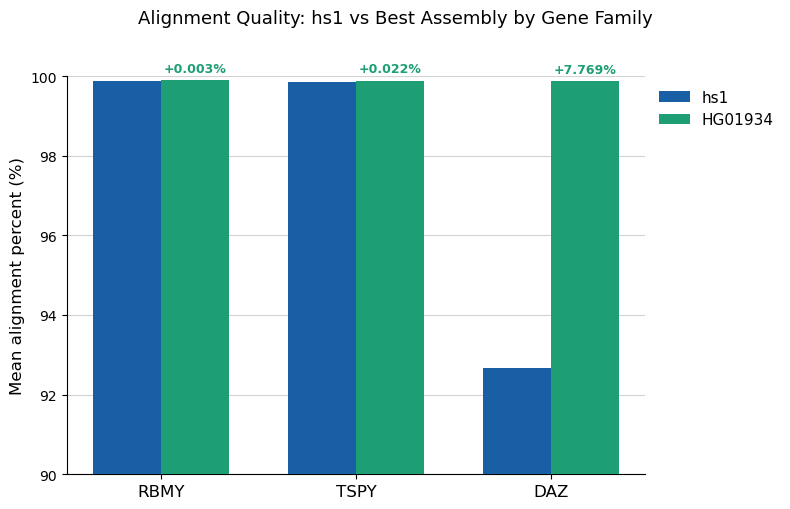

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

families = ["RBMY", "TSPY", "DAZ"]

# --- Find the single best overall sample (excluding T2T) ---
sample_scores = defaultdict(list)

for fam in families:
    fam_data = famSampAlignQuality_dict[fam]
    for sample, val in fam_data.items():
        if sample != "T2T":
            sample_scores[sample].append(val)

REQUIRE_ALL_FAMILIES = True
if REQUIRE_ALL_FAMILIES:
    sample_scores = {s: v for s, v in sample_scores.items() if len(v) == len(families)}

best_overall = max(sample_scores, key=lambda s: np.mean(sample_scores[s]))
print(f"Best overall sample: {best_overall}  "
      f"(mean quality across families: {np.mean(sample_scores[best_overall]) * 100:.4f}%)")

# --- Collect values for the chosen sample and T2T (converted to percent) ---
t2t_list = [famSampAlignQuality_dict[fam]["T2T"] * 100        for fam in families]
pg_list  = [famSampAlignQuality_dict[fam][best_overall] * 100 for fam in families]
improvements = [(pg - t2t) / t2t * 100 for t2t, pg in zip(t2t_list, pg_list)]

# --- Plot ---
x     = np.arange(len(families))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

bars1 = ax1.bar(x - width/2, t2t_list, width, label="hs1",                         color="#185FA5", zorder=3)
bars2 = ax1.bar(x + width/2, pg_list,  width, label=f"{best_overall}", color="#1D9E75", zorder=3)

ax1.set_ylabel("Mean alignment percent (%)", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(families, fontsize=12)
ax1.set_ylim(90, 100)  # now in percent
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0f}"))
ax1.yaxis.grid(True, color="lightgrey", zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

# Improvement % annotations above each best-sample bar
for i, (pct, pg) in enumerate(zip(improvements, pg_list)):
    sign = "+" if pct >= 0 else ""
    ax1.annotate(
        f"{sign}{pct:.3f}%",
        xy=(x[i] + width/2, pg),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center", fontsize=9, color="#1D9E75", fontweight="bold"
    )

ax1.legend(frameon=False, fontsize=11, bbox_to_anchor=(1, 1), loc="upper left")
fig.suptitle("Alignment Quality: hs1 vs Best Assembly by Gene Family", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("T2TvsBestAssembly_AlignComparison_GeneFamilies.png", dpi=300, bbox_inches="tight")
plt.savefig("T2TvsBestAssembly_AlignComparison_GeneFamilies.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [45]:
sample_scores

{'200080': [0.9989480216695854, 0.9987936815847084, 0.9846966857031635],
 '200084': [0.9989498600038381, 0.9987925870031727, 0.984583752798027],
 '200085': [0.9989167579263601, 0.998793960227361, 0.9840670189120488],
 'HG00096': [0.998886274224809, 0.998718038267904, 0.9969536644658591],
 'HG00126': [0.9989253246356851, 0.9987980641350257, 0.9776652640437562],
 'HG00140': [0.9987328742251155, 0.9985995510563368, 0.9418084289918209],
 'HG00280': [0.9987569794062222, 0.9984663590501759, 0.9649448711074333],
 'HG00290': [0.9988531504813218, 0.9984697621770423, 0.9754122283752846],
 'HG002': [0.9988646930449759, 0.9985918395883628, 0.9265625074726963],
 'HG00321': [0.998680719932381, 0.9985980177114383, 0.9412886198347444],
 'HG00329': [0.9989017440280338, 0.9984710262312406, 0.9738078733510275],
 'HG00358': [0.9988986083510093, 0.9984672183012373, 0.9734943350823165],
 'HG003': [0.9987605461759513, 0.9985907593445809, 0.9278476211969328],
 'HG00512': [0.9988422377383851, 0.998503149056630

In [46]:
samps, means = [], []
for samp in sample_scores:
    cumsum = 0
    for i in sample_scores[samp]:
        cumsum += i
    samps.append(samp)
    means.append(cumsum / 3)
sampMeanDF = pd.DataFrame()
sampMeanDF["Sample"] = samps
sampMeanDF["MeanQ"] = means
sampMeanDF.sort_values("MeanQ", ascending=False).head(10)

,Sample,MeanQ
42,HG01934,0.998834
34,HG01358,0.998828
105,NA12877,0.998819
132,NA20509,0.998778
106,NA12882,0.998770
107,NA12886,0.998770
3,HG00096,0.998186
21,HG00731,0.996239
22,HG00738,0.996173
33,HG01261,0.996157


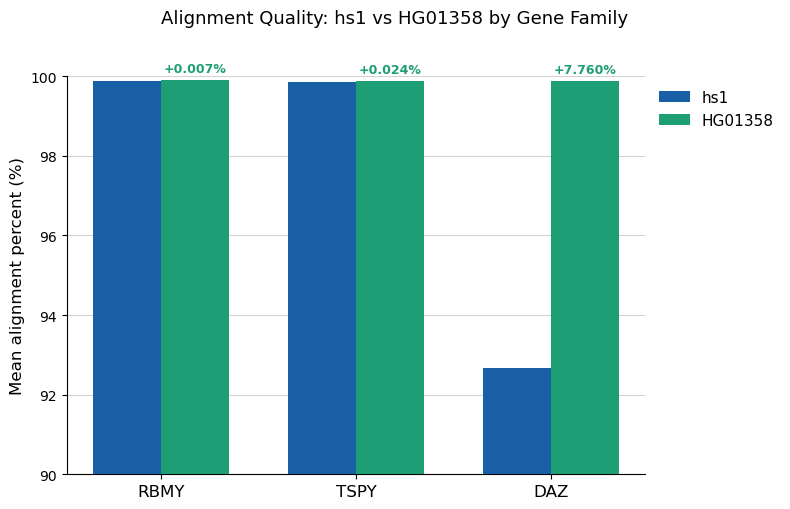

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

families = ["RBMY", "TSPY", "DAZ"]

# --- Use HG01358 directly ---
chosen_sample = "HG01358"

# --- Collect values for HG01358 and T2T (converted to percent) ---
t2t_list = [famSampAlignQuality_dict[fam]["T2T"]          * 100 for fam in families]
pg_list  = [famSampAlignQuality_dict[fam][chosen_sample]  * 100 for fam in families]

improvements = [(pg - t2t) / t2t * 100 for t2t, pg in zip(t2t_list, pg_list)]

# --- Plot ---
x     = np.arange(len(families))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8, 5))

bars1 = ax1.bar(x - width/2, t2t_list, width, label="hs1",            color="#185FA5", zorder=3)
bars2 = ax1.bar(x + width/2, pg_list,  width, label=chosen_sample,    color="#1D9E75", zorder=3)

ax1.set_ylabel("Mean alignment percent (%)", fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(families, fontsize=12)
ax1.set_ylim(90, 100)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0f}"))
ax1.yaxis.grid(True, color="lightgrey", zorder=0)
ax1.set_axisbelow(True)
ax1.spines[["top", "right"]].set_visible(False)

# Improvement % annotations above each HG01358 bar
for i, (pct, pg) in enumerate(zip(improvements, pg_list)):
    sign = "+" if pct >= 0 else ""
    ax1.annotate(
        f"{sign}{pct:.3f}%",
        xy=(x[i] + width/2, pg),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center", fontsize=9, color="#1D9E75", fontweight="bold"
    )

ax1.legend(frameon=False, fontsize=11, bbox_to_anchor=(1, 1), loc="upper left")
fig.suptitle("Alignment Quality: hs1 vs HG01358 by Gene Family", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("T2TvsHG01358_AlignComparison_GeneFamilies.png", dpi=300, bbox_inches="tight")
plt.savefig("T2TvsHG01358_AlignComparison_GeneFamilies.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(RBMYreads)]["alignPortion"].mean()

0.9989828202413076

In [49]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(RBMYreads)]["alignPortion"].mean()

0.9988646930449759

In [50]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]["alignPortion"].mean()

0.9988439164552756

In [51]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]["alignPortion"].mean()

0.998591839588363

In [52]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]["alignPortion"].mean()

0.9986377421048883

In [53]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]["alignPortion"].mean()

0.9600034399762123

#### Alignment Quality Comparisons - Median

In [54]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(strictRBMYreads)]["alignPortion"].median()

0.9994256174612292

In [55]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(strictRBMYreads)]["alignPortion"].median()

0.9993730407523511

In [56]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]["alignPortion"].median()

0.999083409715857

In [57]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(TSPYreads)]["alignPortion"].median()

0.9989361593769064

In [58]:
assemblyOnly_readAlignmentDF_bestHit_goodHitReads[assemblyOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]["alignPortion"].median()

0.9993911592994162

In [59]:
T2TOnly_readAlignmentDF_bestHit_goodHitReads[T2TOnly_readAlignmentDF_bestHit_goodHitReads["read_name"].isin(DAZreads)]["alignPortion"].median()

0.9972458928297252

#### Confusion Matrix: T2T vs Best Assembly

In [60]:
Assembly_T2T_bestHit_goodHitReadsDF = pd.concat([assemblyOnly_readAlignmentDF_bestHit_goodHitReads, T2TOnly_readAlignmentDF_bestHit_goodHitReads])
Assembly_T2T_bestHit_goodHitReadsDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
9498672,HG02602,SRR31360662.5793524,HG02602_chrY,0,22=4572N99=3973N372=1D1477=,0,25515922,25526438,1970,1970,0,0,1,8545,0,1.000000,DAZ3|DAZ1
9498495,HG02602,SRR31360662.18432498,HG02602_chrY,0,30=2305N72=9715N72=745N35=4572N99=3973N1850=,0,25502970,25526438,2158,2158,0,0,0,21310,0,1.000000,DAZ3|DAZ1
9498493,HG02602,SRR31360662.31807995,HG02602_chrY,0,26=2308N72=2305N72=9715N72=745N35=4572N99=3973...,8,25500594,25526438,2226,2226,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498491,HG02602,SRR31360662.19717780,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
9498490,HG02602,SRR31360662.7209056,HG02602_chrY,0,27=2308N72=2305N72=9715N72=745N35=4572N99=3973...,9,25500593,25526445,2234,2234,0,0,0,23618,0,1.000000,DAZ3|DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19997627,T2T,SRR31360662.44777067,NC_060948.1,16,266=3973N99=4572N35=745N72=9715N72=2305N143I72...,60,23966593,24005238,1359,1064,8,287,0,37573,0,0.782929,DAZ1
19997653,T2T,SRR31360662.9409624,NC_060948.1,16,48=1I40=1I42=1D13=1I17=559N35=745N4=147I12=1X1...,60,23974783,24005238,1163,855,12,296,1,29587,0,0.735168,DAZ1
19997625,T2T,SRR31360662.5012143,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1095,6,432,0,32883,0,0.714286,DAZ1
19997626,T2T,SRR31360662.13617834,NC_060948.1,16,392=3973N99=4572N35=745N4=288I5=1X6=1X1=1X25=1...,1,23966467,24000451,1533,1094,7,432,0,32883,0,0.713633,DAZ1


In [61]:
genes = []
for i in Assembly_T2T_bestHit_goodHitReadsDF["Gene"]:
    if "|" in i:
        genes.append(i.split("|")[-1])
    else:
        genes.append(i)
Assembly_T2T_bestHit_goodHitReadsDF["cleanGene"] = genes

In [62]:
RBMY_bestHitCompareDF = Assembly_T2T_bestHit_goodHitReadsDF[Assembly_T2T_bestHit_goodHitReadsDF["read_name"].isin(strictRBMYreads)]
TSPY_bestHitCompareDF = Assembly_T2T_bestHit_goodHitReadsDF[Assembly_T2T_bestHit_goodHitReadsDF["read_name"].isin(TSPYreads)]
DAZ_bestHitCompareDF = Assembly_T2T_bestHit_goodHitReadsDF[Assembly_T2T_bestHit_goodHitReadsDF["read_name"].isin(firstExonPresent_DAZreads)]

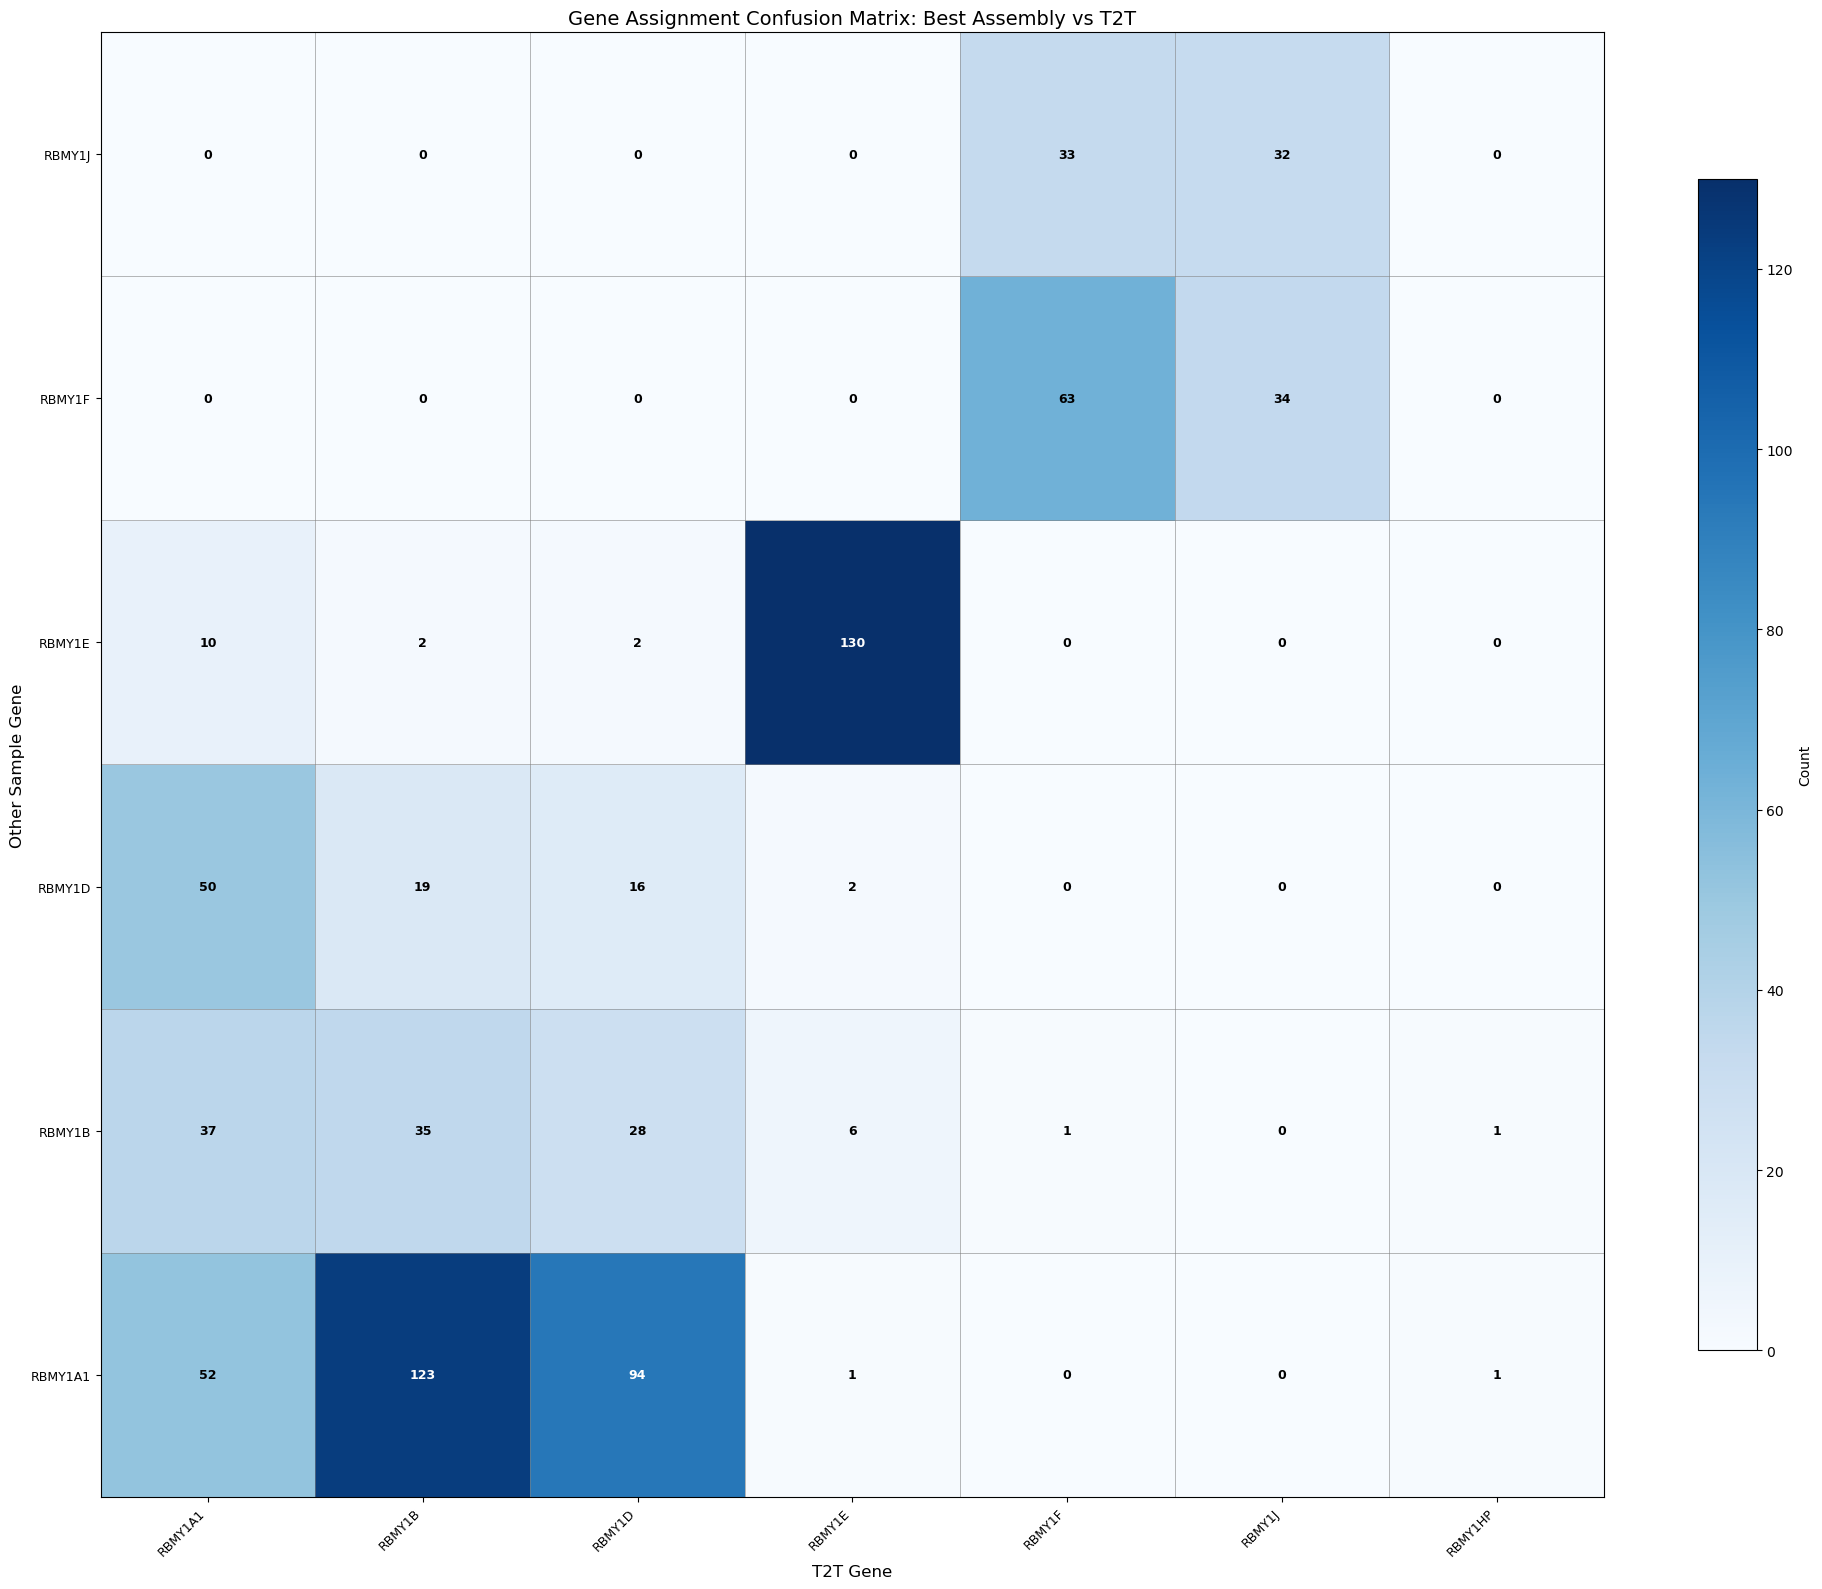

In [63]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = RBMY_bestHitCompareDF[RBMY_bestHitCompareDF["Gene"]!="NoHit"].copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes  = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell
thresh = data.max() / 2.0  # threshold for switching text color
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Draw grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Axis ticks and labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, fontsize=9)

ax.set_xlabel("T2T Gene", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Best Assembly vs T2T", fontsize=14)
ax.invert_yaxis()  # <-- add this

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()

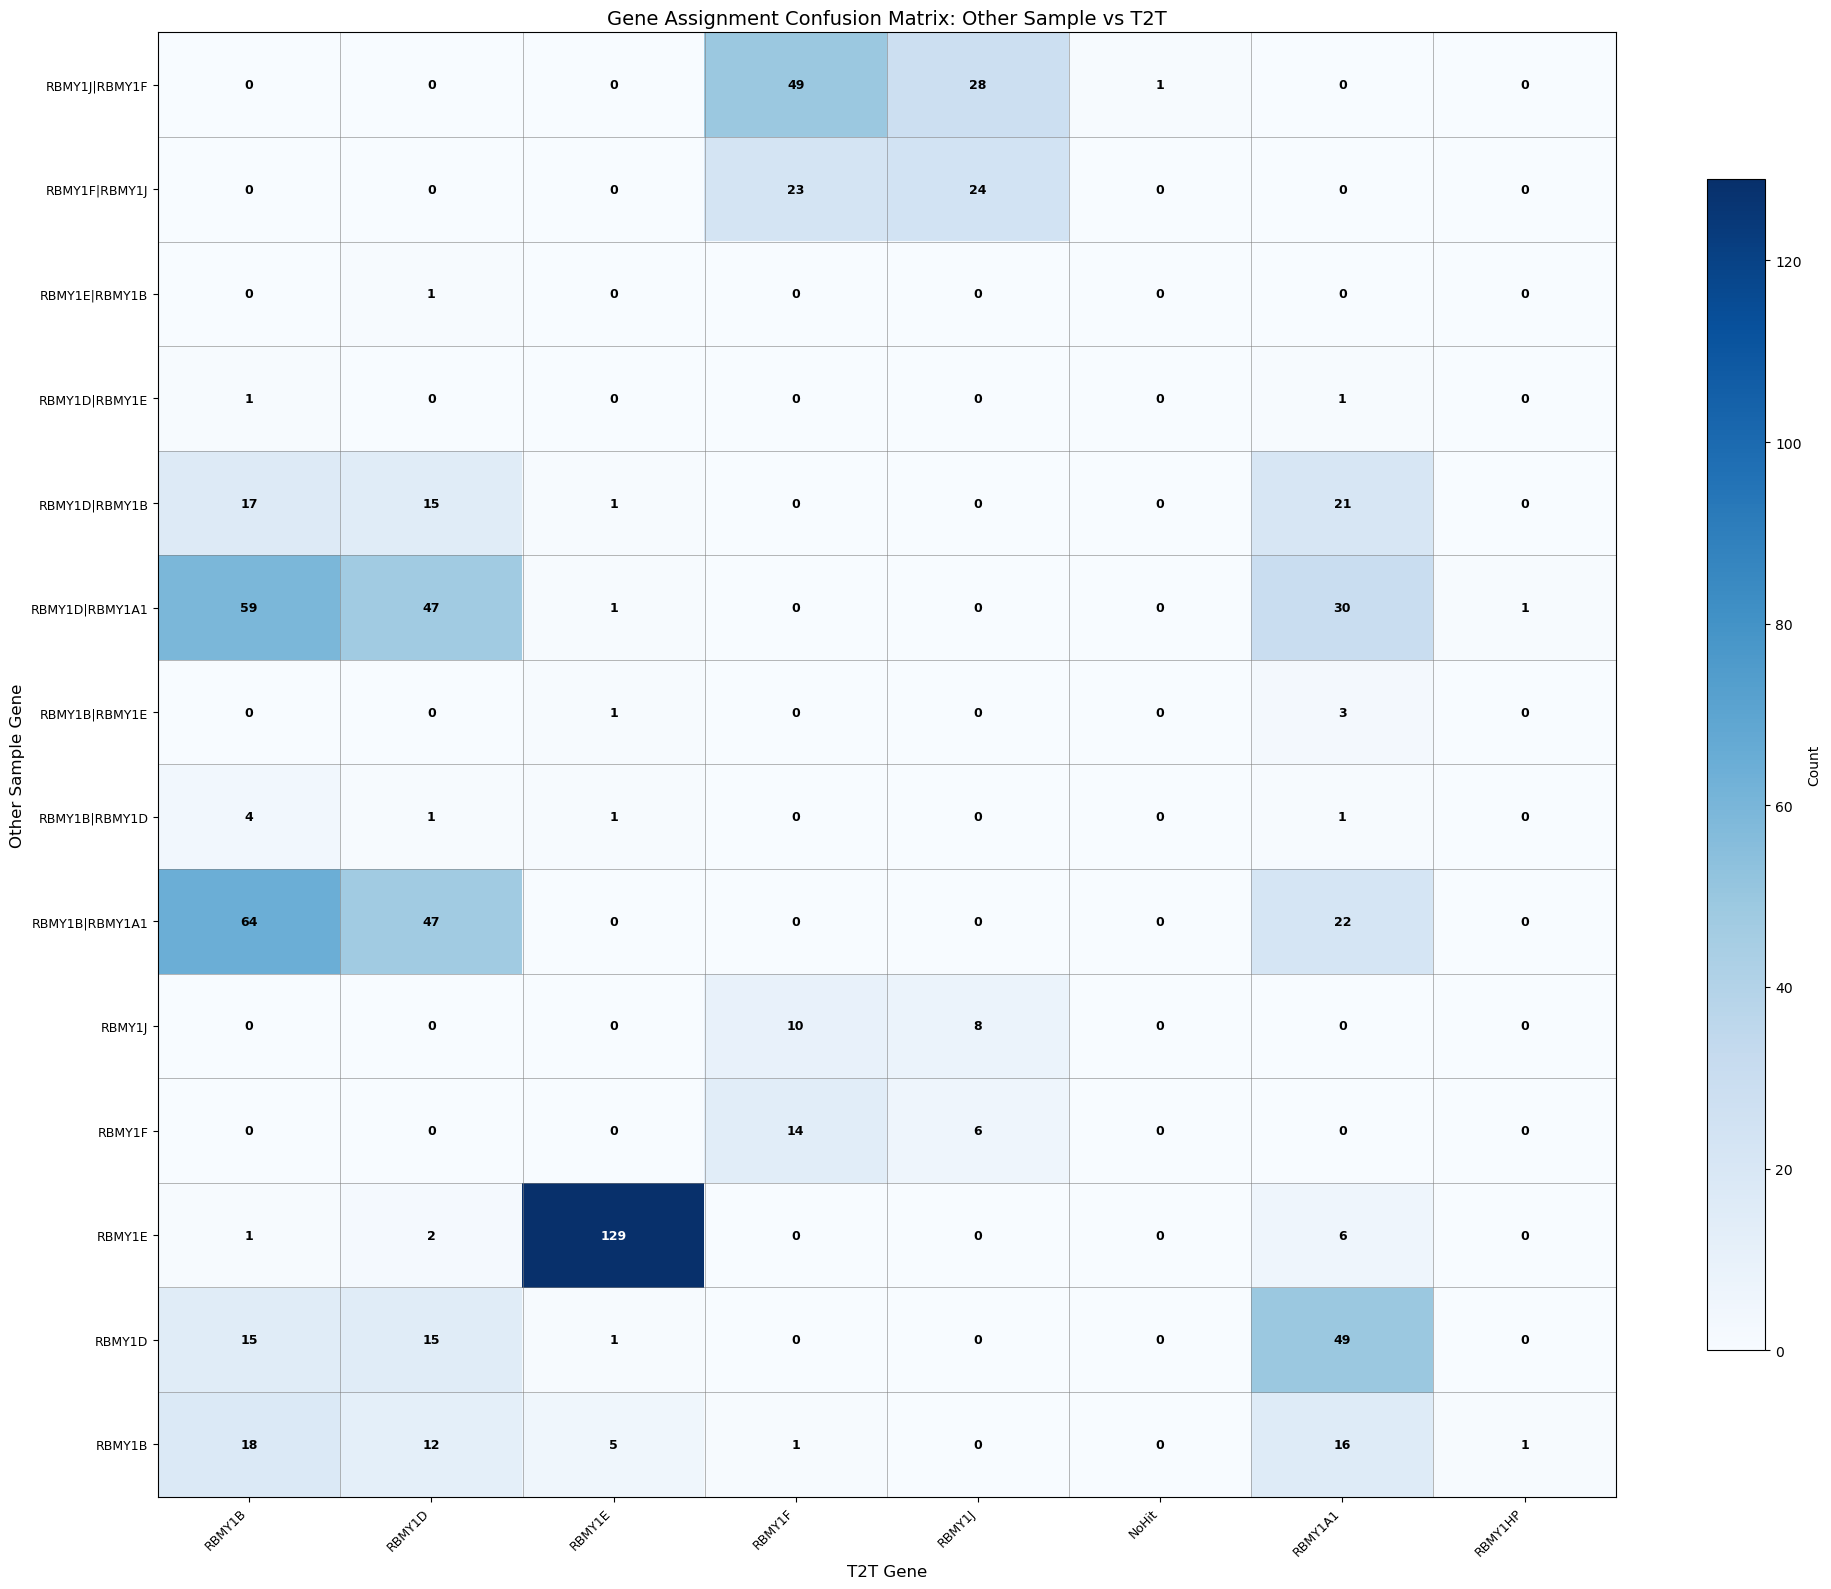

In [64]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = RBMY_bestHitCompareDF.copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "Gene"]].rename(columns={"Gene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "Gene", "sample"]].rename(columns={"Gene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Axis ticks and labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("T2T Gene", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Other Sample vs T2T", fontsize=14)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()

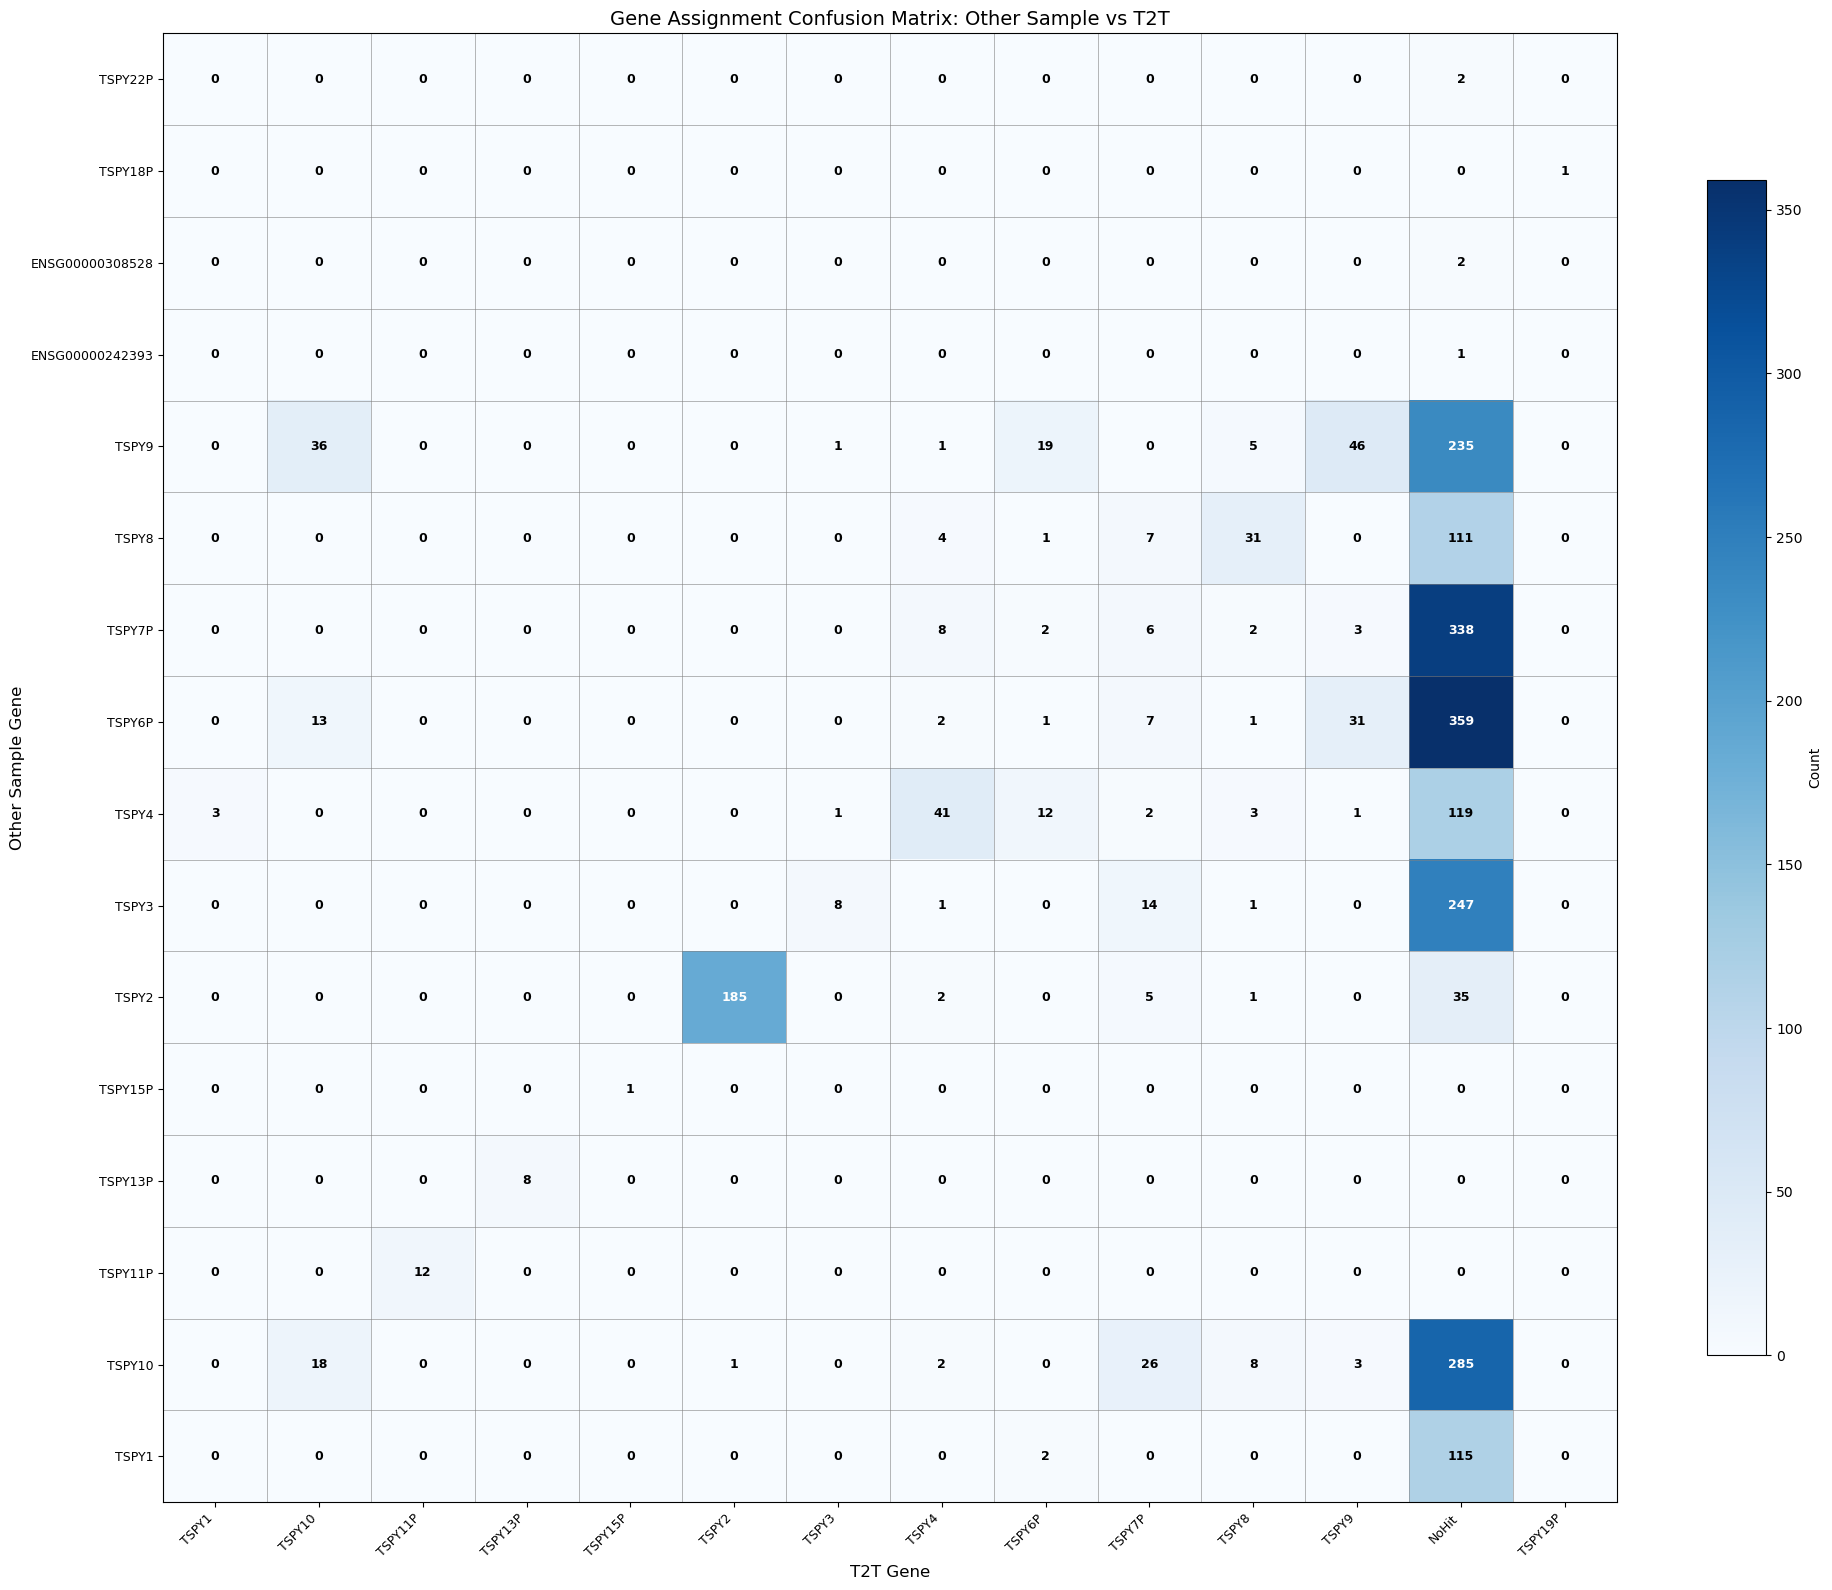

In [65]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = TSPY_bestHitCompareDF.copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Axis ticks and labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("T2T Gene", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Other Sample vs T2T", fontsize=14)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()

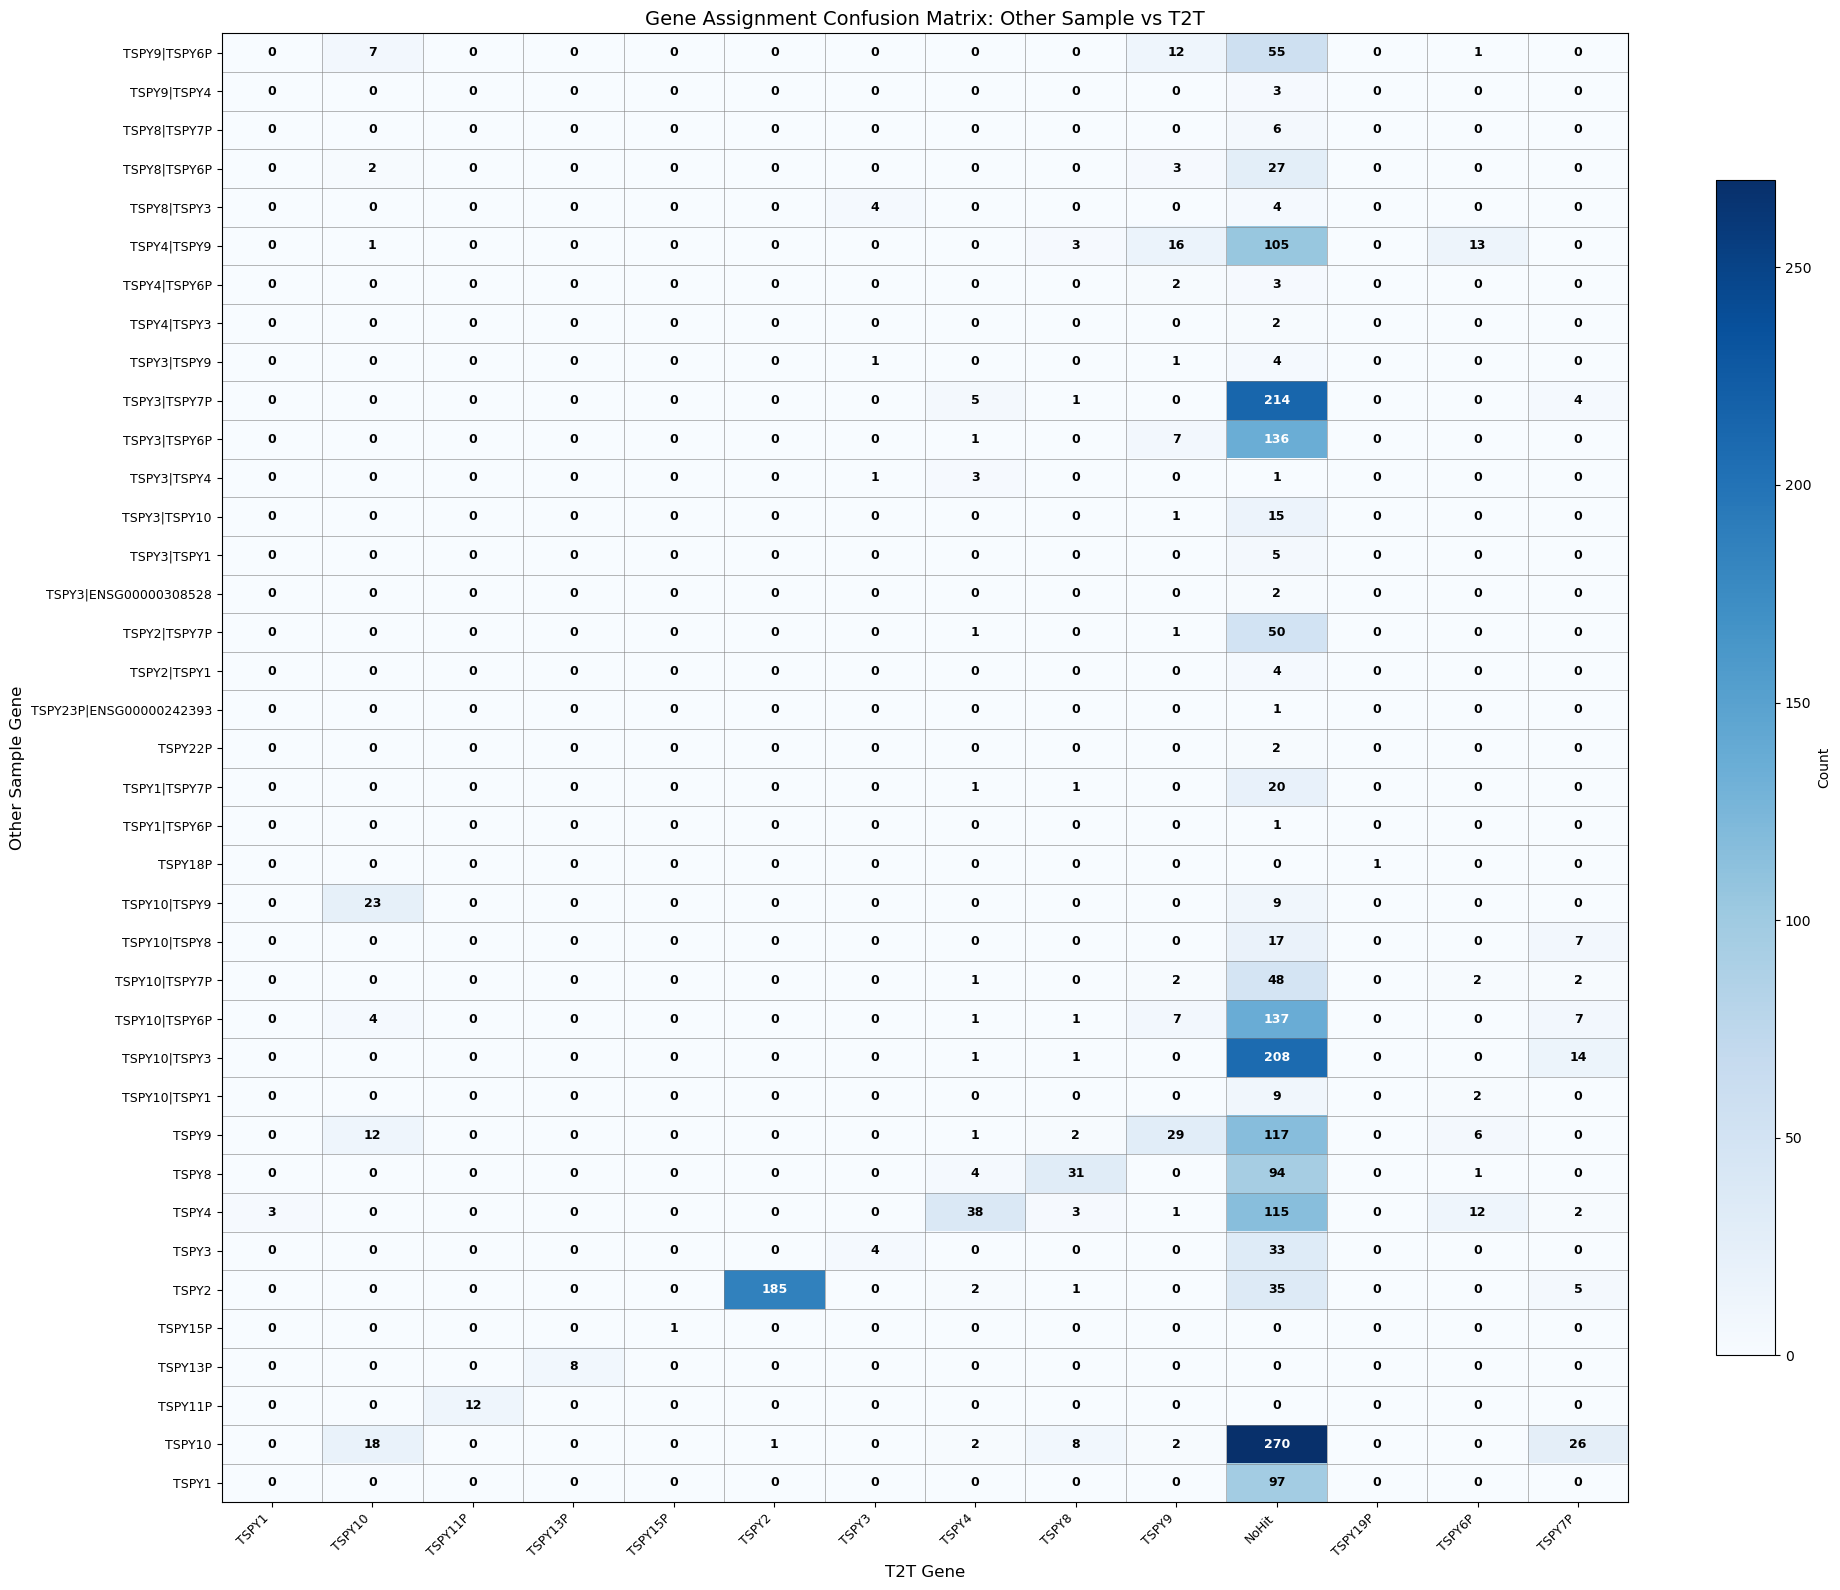

In [66]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = TSPY_bestHitCompareDF.copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "Gene"]].rename(columns={"Gene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "Gene", "sample"]].rename(columns={"Gene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Axis ticks and labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("T2T Gene", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Other Sample vs T2T", fontsize=14)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()

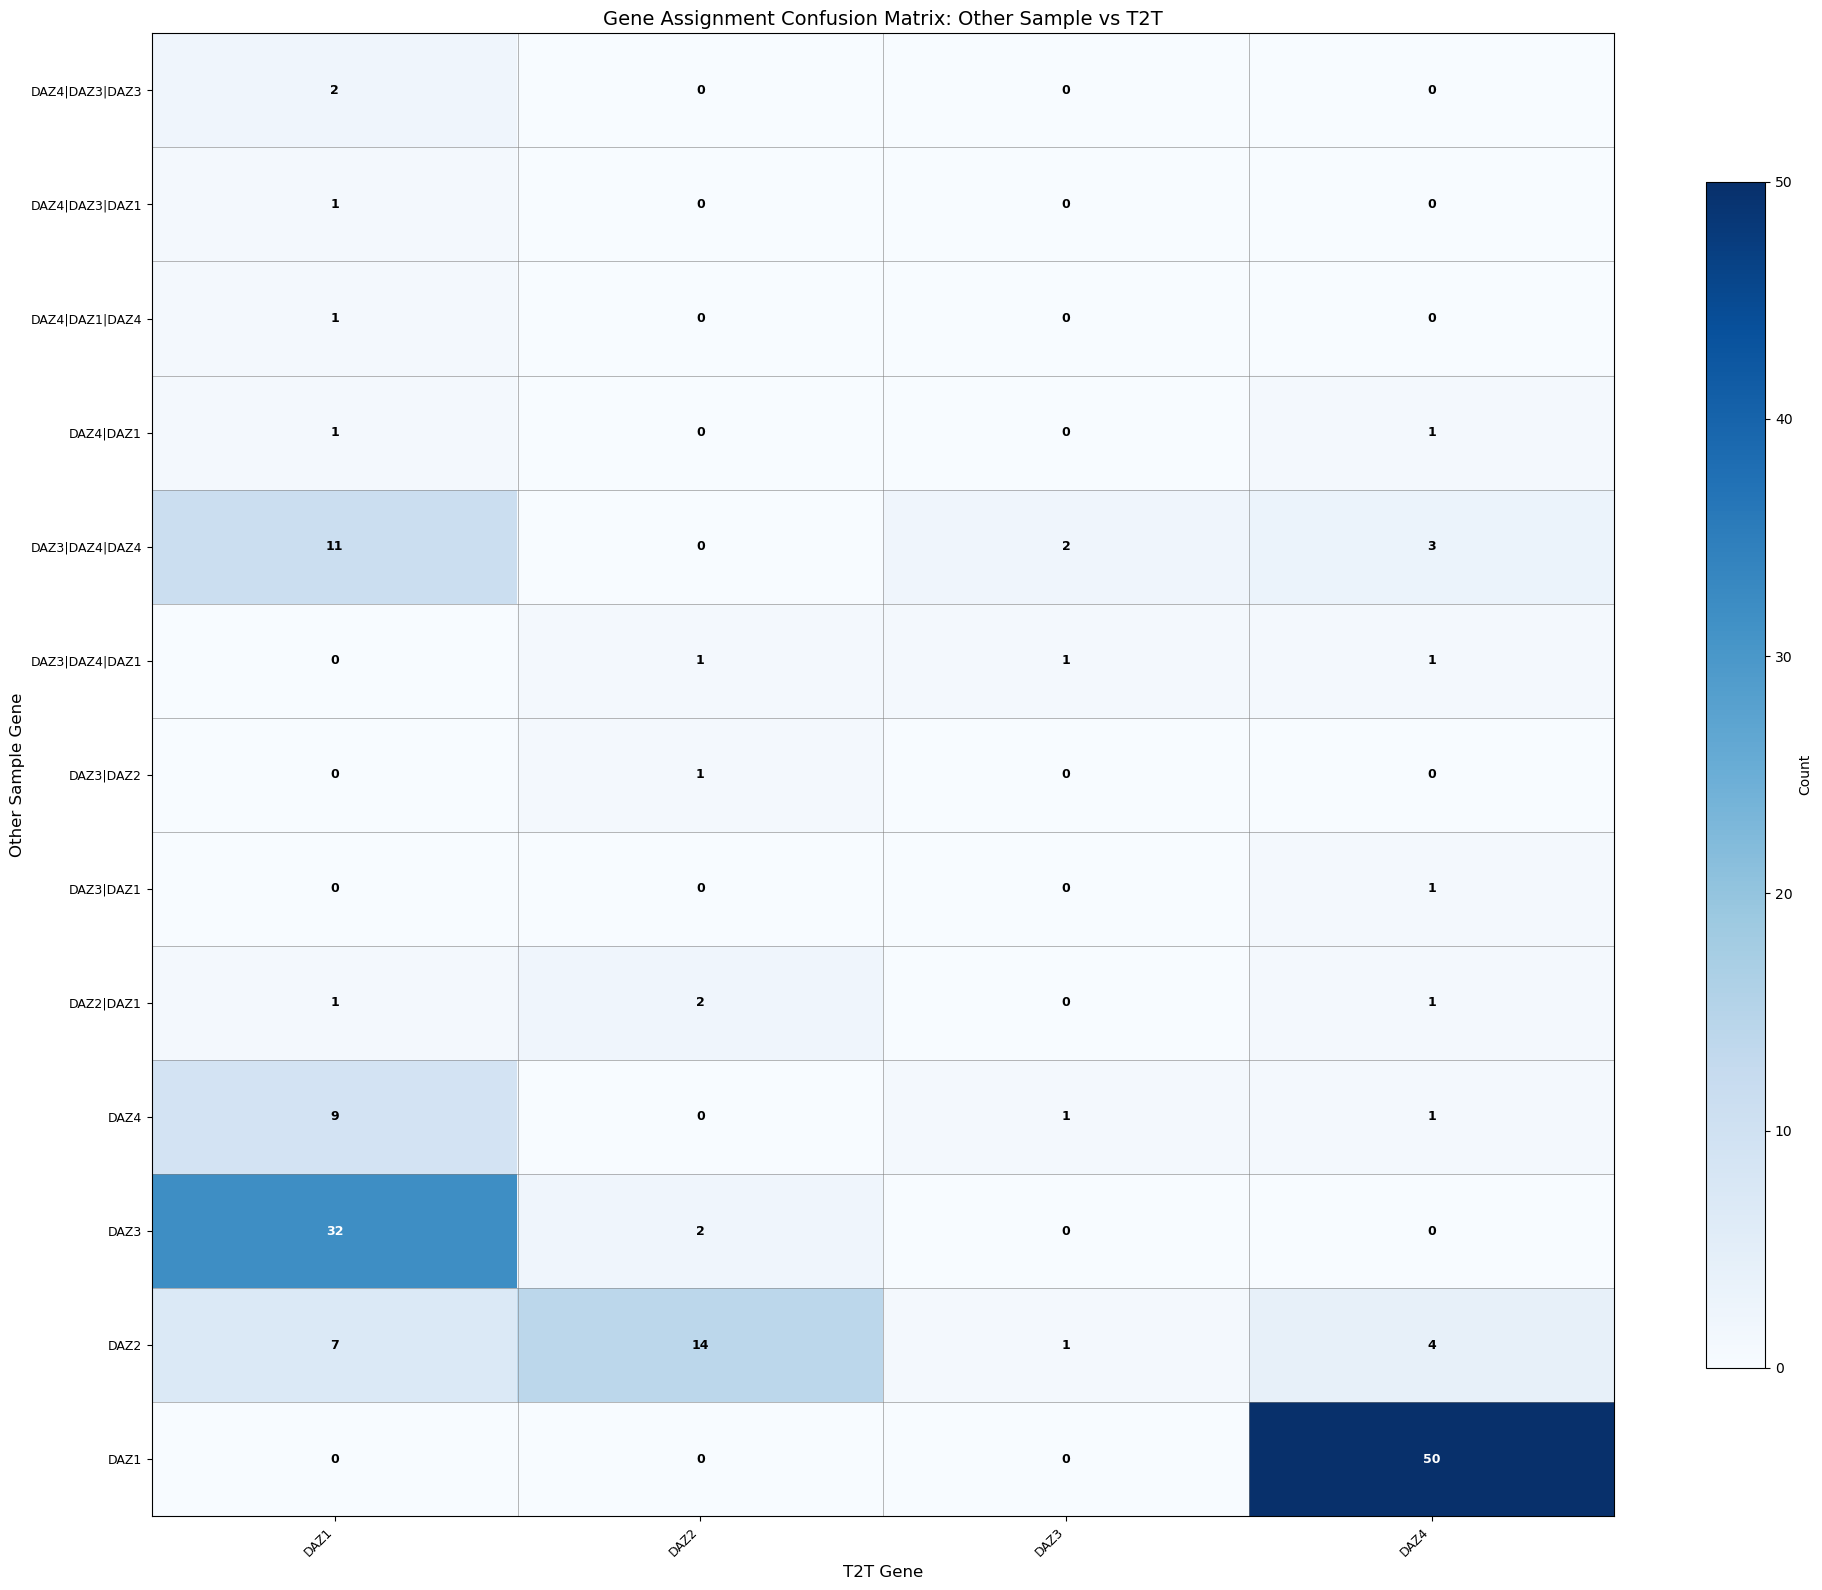

In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = DAZ_bestHitCompareDF.copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "Gene"]].rename(columns={"Gene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "Gene", "sample"]].rename(columns={"Gene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Axis ticks and labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("T2T Gene", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Other Sample vs T2T", fontsize=14)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()

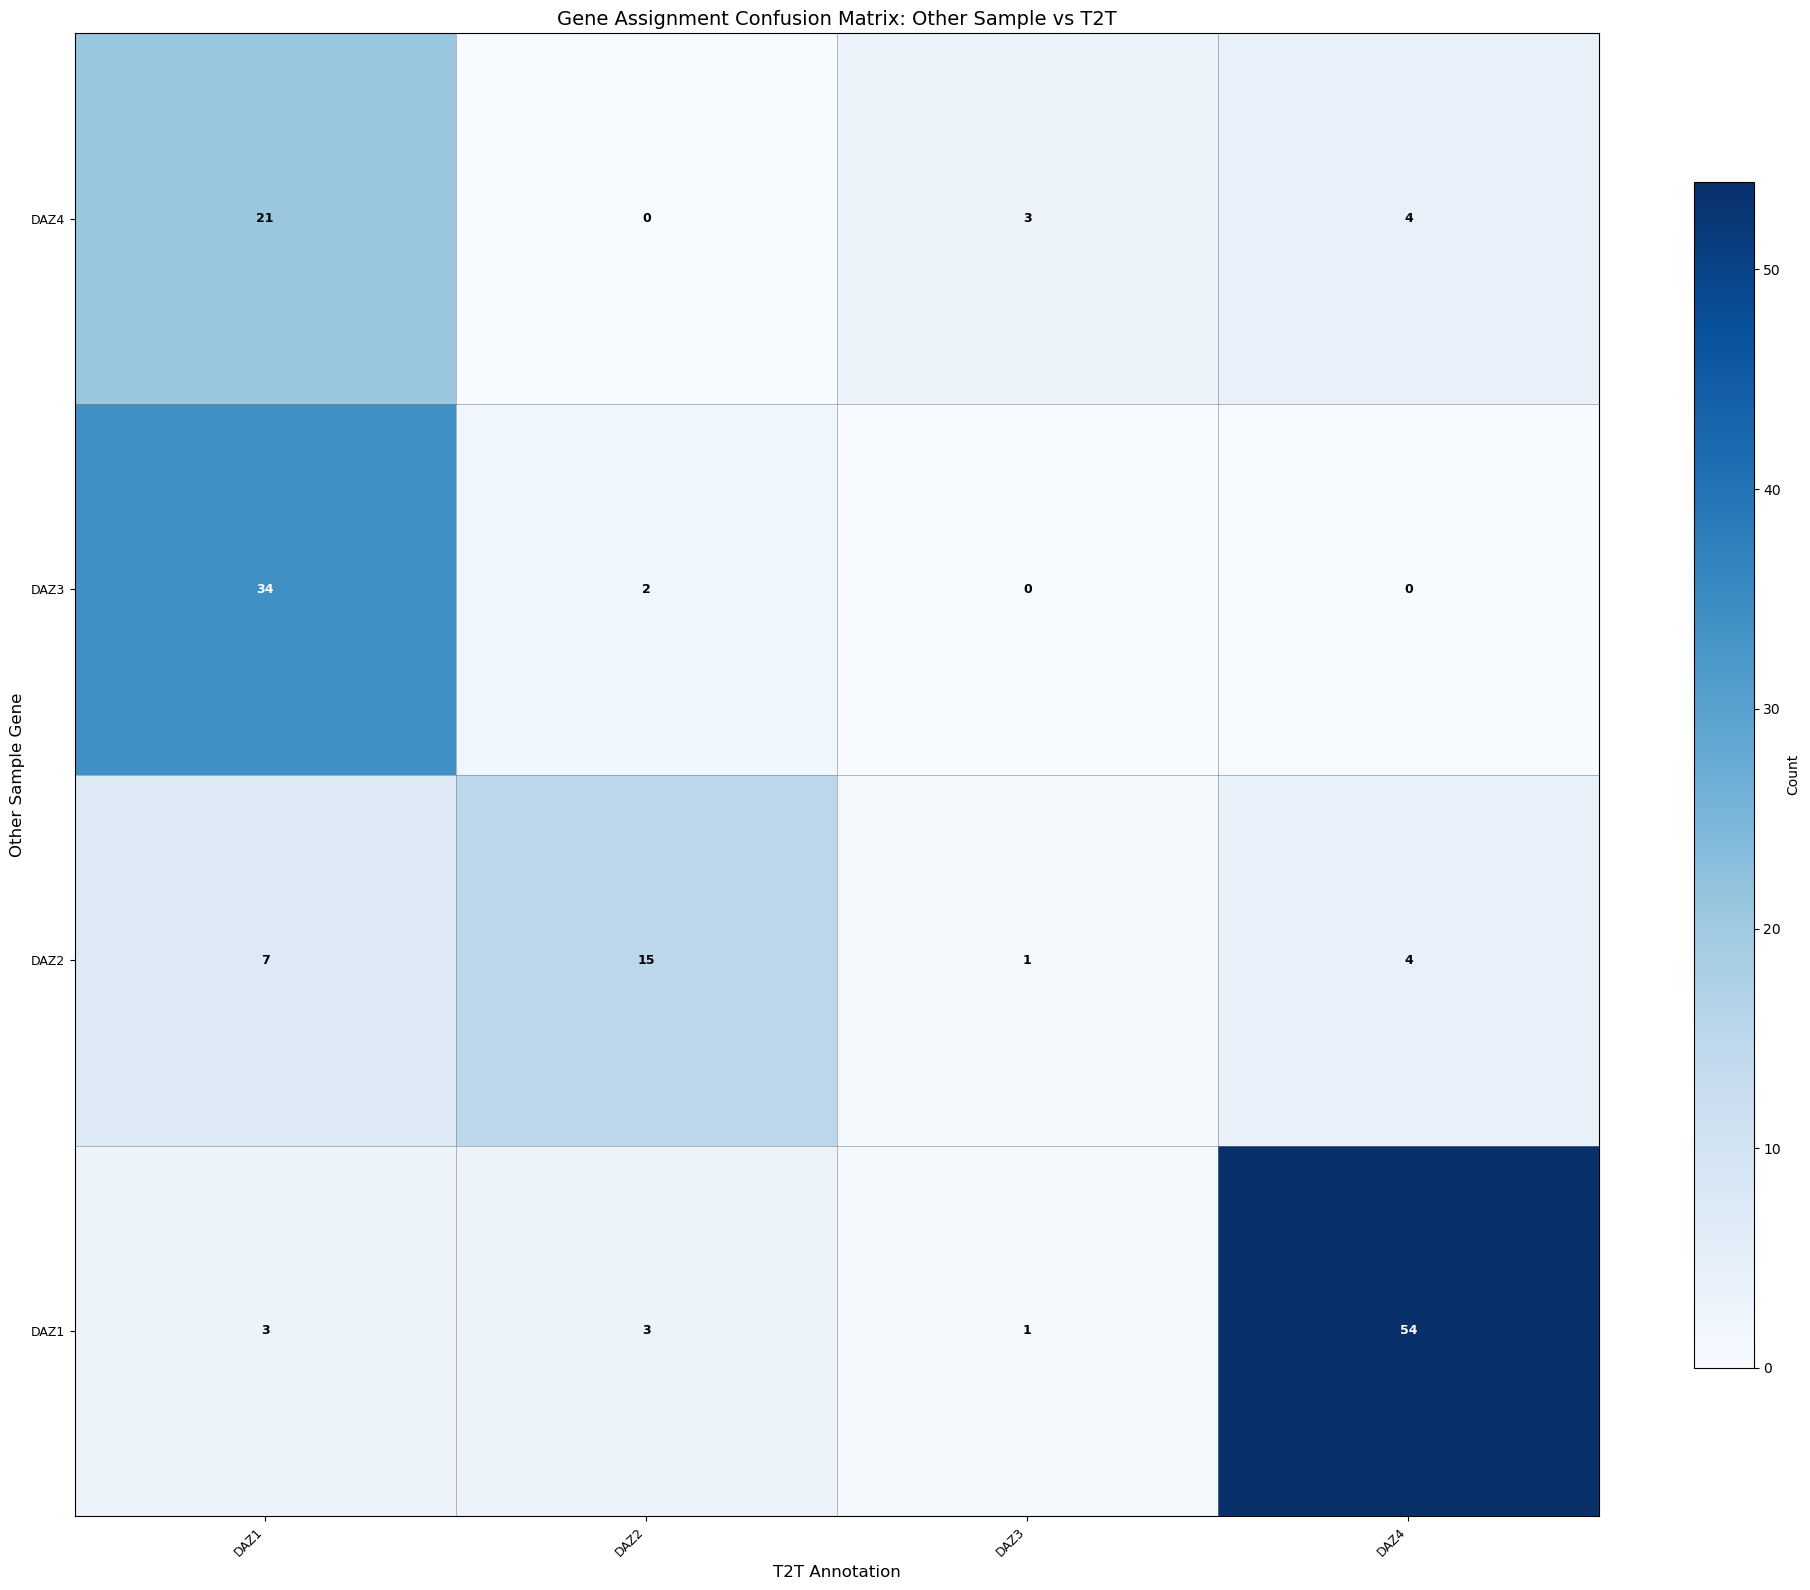

<Figure size 640x480 with 0 Axes>

In [68]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = DAZ_bestHitCompareDF.copy()

# Split into T2T and "other" rows, then merge on read_name
t2t_rows   = df[df["sample"] == "T2T"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_T2T"})
other_rows = df[df["sample"] != "T2T"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_other"})
merged = other_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_T2T"].unique())
other_genes = set(merged["Gene_other"].unique())
shared     = sorted(t2t_genes & other_genes)
t2t_only   = sorted(t2t_genes - other_genes)
other_only = sorted(other_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + other_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_other"],
    merged["Gene_T2T"],
    rownames=["Other Sample Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())

ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=9, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Force all tick labels to show
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, rotation=0, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel("T2T Annotation", fontsize=12)
ax.set_ylabel("Other Sample Gene", fontsize=12)
ax.set_title("Gene Assignment Confusion Matrix: Other Sample vs T2T", fontsize=14)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

plt.tight_layout()
plt.show()
matplotlib.rcParams['pdf.fonttype'] = 42
plt.savefig("ConfusionMatrix_otherSamplevsT2T.pdf", dpi=300, bbox_inches="tight")

In [69]:
famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

In [70]:
compareDF = pd.DataFrame()
for sample in ["T2T", "HG01358"]:
    sampDF = readAlignmentDF[readAlignmentDF["sample"]==sample]
    bestHitDF = sampDF[sampDF['alignPortion'] == sampDF.groupby('read_name')['alignPortion'].transform('max')]
    compareDF = pd.concat([compareDF, bestHitDF])
DAZ_compareDF = compareDF[compareDF["read_name"].isin(DAZreads_firstExon)]
DAZ_compareDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19997441,T2T,SRR31360662.9678238,NC_060948.1,16,956=1I719=3D179=3973N99=4572N35=745N4=288I5=1X...,23,23965002,24008117,3487,3048,6,433,3,40058,0,0.874104,DAZ1
19997447,T2T,SRR31360662.17932593,NC_060948.1,16,1479=1I378=3973N99=4572N35=745N72=9715N72=2305...,60,23965002,24006943,3168,2871,8,289,0,39062,0,0.906250,DAZ1
19997448,T2T,SRR31360662.17942616,NC_060948.1,16,1857=3973N99=4572N35=745N72=9715N9=1X34=1X7=1X...,1,23965002,24000456,2881,2563,8,288,0,32883,22,0.889622,DAZ1
19997449,T2T,SRR31360662.19162352,NC_060948.1,16,780=1X1076=3973N99=4572N35=745N72=9715N9=1X34=...,1,23965002,24002812,2896,2598,10,288,0,35202,0,0.897099,DAZ1
19997453,T2T,SRR31360662.22122359,NC_060948.1,16,1611=1I246=3973N99=4572N35=745N4=288I5=1X6=1X1...,27,23965002,24026243,4924,4484,6,433,1,56750,1,0.910642,DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4954836,HG01358,SRR31360662.44777067,HG01358_chrY,0,24=2371N72=2318N72=2324N72=2305N72=2308N72=231...,60,25420161,25468319,1359,1359,0,0,1,46798,0,1.000000,DAZ3
4954875,HG01358,SRR31360662.29967801,HG01358_chrY,0,3S3=1X76=2318N72=2324N72=2305N72=2308N72=2312N...,60,25422548,25469903,2930,2926,1,0,1,44427,3,0.998635,DAZ3
4954876,HG01358,SRR31360662.30117617,HG01358_chrY,0,5S3=1X76=2318N72=2324N72=2305N72=2308N72=2312N...,60,25422548,25468950,1980,1974,1,0,0,44427,5,0.996970,DAZ3
4954877,HG01358,SRR31360662.37193187,HG01358_chrY,0,5S3=1X76=2318N72=2324N72=2305N72=2308N72=2312N...,60,25422548,25468950,1980,1974,1,0,0,44427,5,0.996970,DAZ3


In [71]:
genes = []
for i in DAZ_compareDF["Gene"]:
    if "|" in i:
        genes.append(i.split("|")[-1])
    else:
        genes.append(i)
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/765921303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


In [72]:
genes = []
for i in DAZ_compareDF["cleanGene"]:
    if i == "DAZ3/DAZ4":
        genes.append("DAZ3")
    else:
        genes.append(i) 
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/2178502930.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


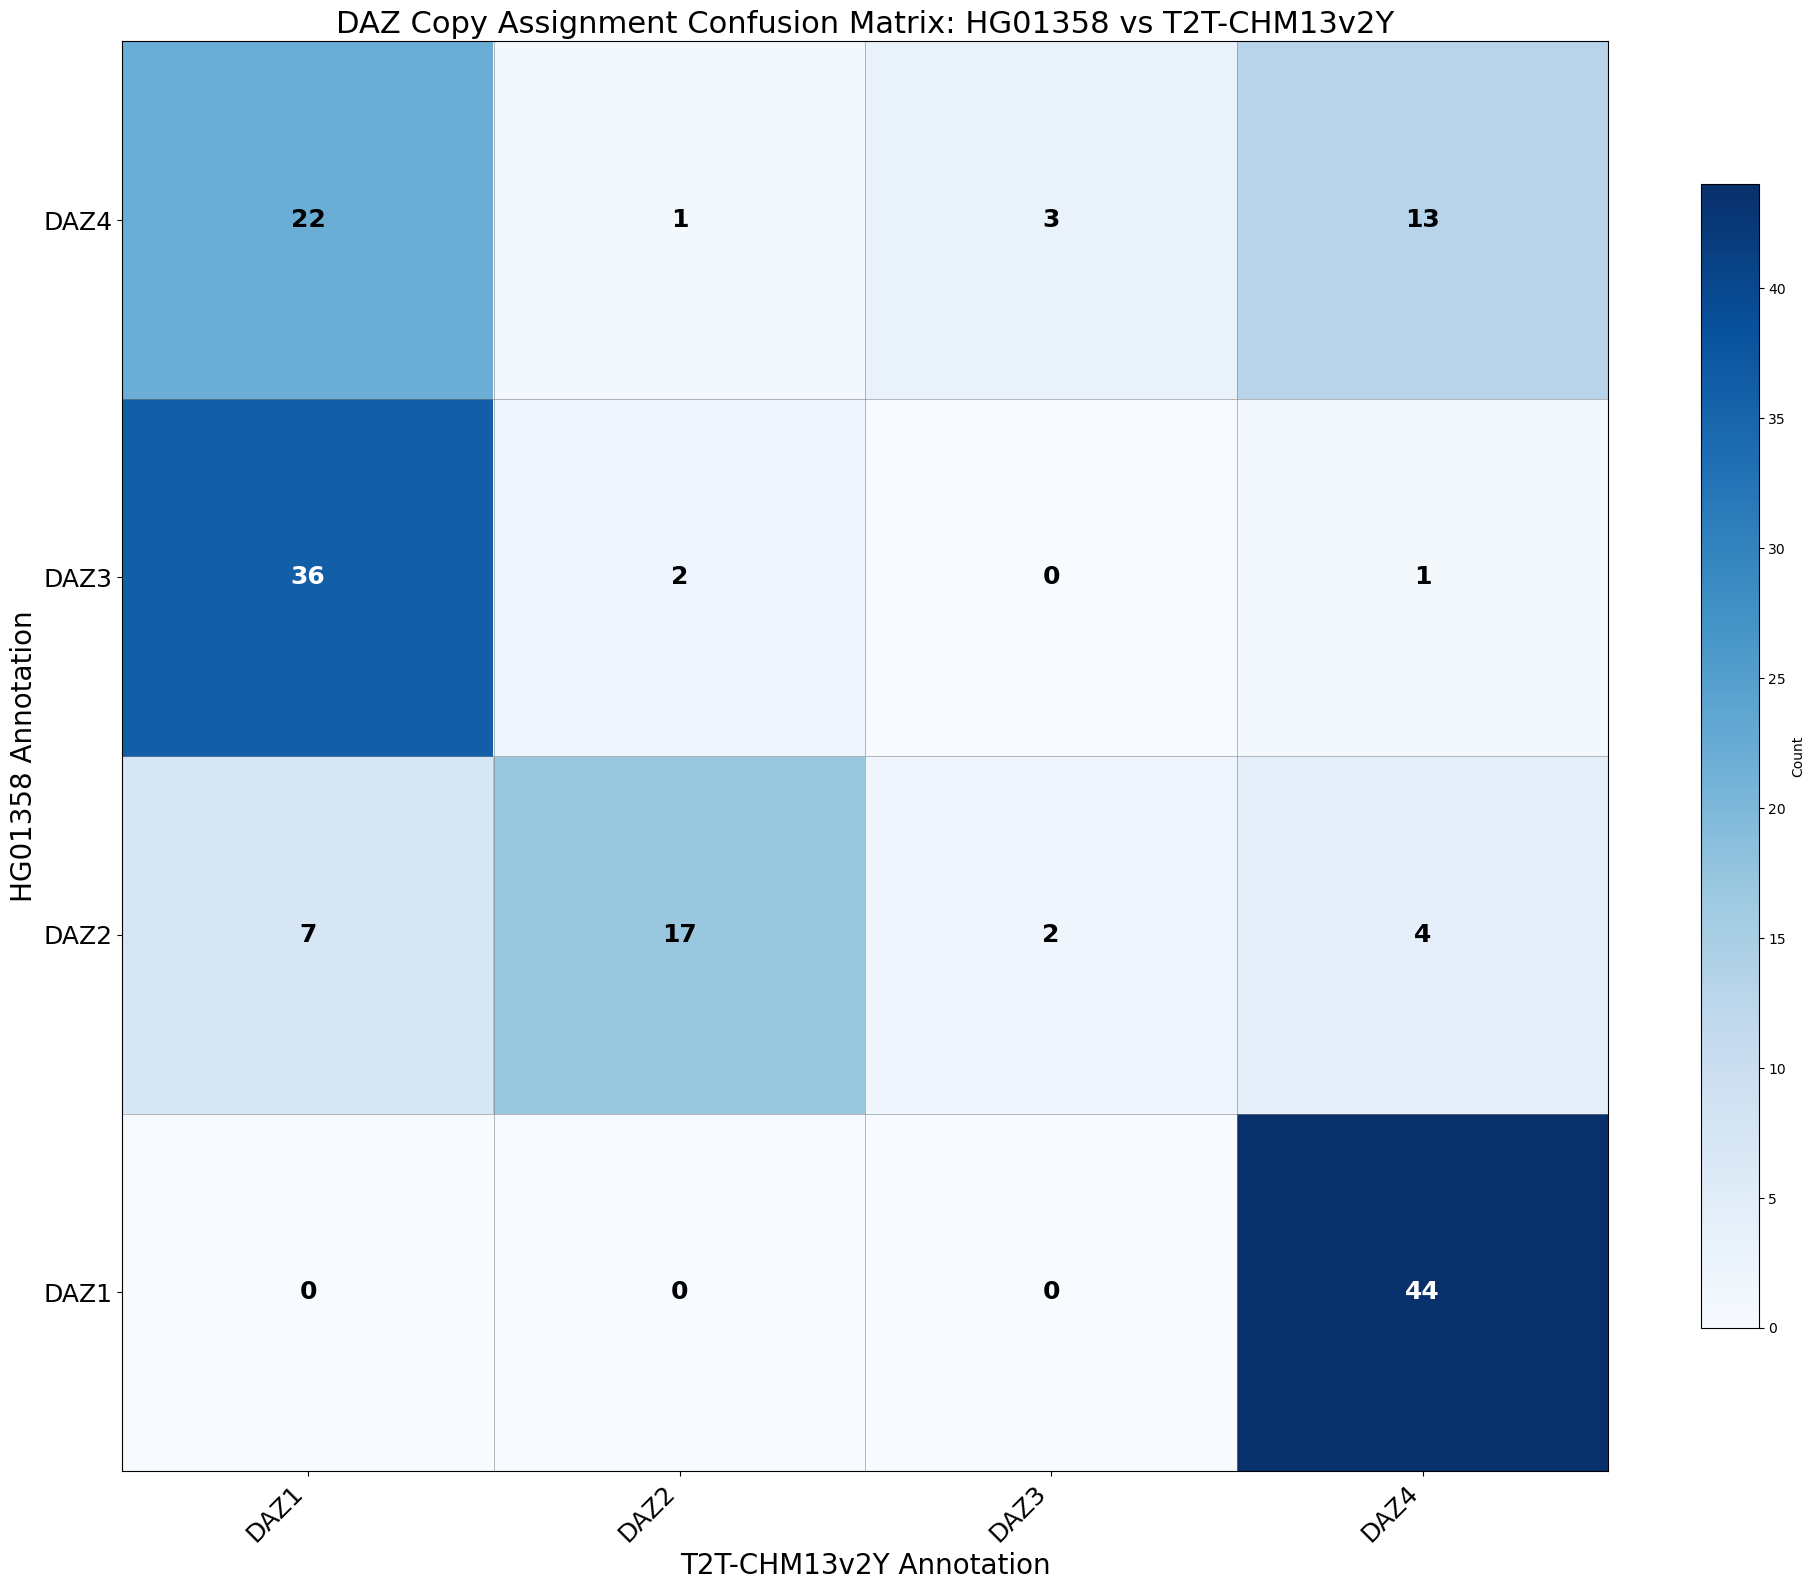

In [73]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = DAZ_compareDF.copy()

# Split into T2T and HG002 rows only
t2t_rows  = df[df["sample"] == "T2T"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_T2T"})
hg002_rows = df[df["sample"] == "HG01358"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_HG01358"})

# Merge on read_name (inner join: only reads present in both)
merged = hg002_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes  = set(merged["Gene_T2T"].unique())
hg002_genes = set(merged["Gene_HG01358"].unique())
shared     = sorted(t2t_genes & hg002_genes)
t2t_only   = sorted(t2t_genes - hg002_genes)
hg002_only  = sorted(hg002_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + hg002_only

# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_HG01358"],
    merged["Gene_T2T"],
    rownames=["HG01358 Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))
cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())
ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=18, color=color, fontweight="bold")  # was 9

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Force all tick labels to show
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=18)  # was 9
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, rotation=0, fontsize=18)  # was 9

ax.invert_yaxis()
ax.set_xlabel("T2T-CHM13v2Y Annotation", fontsize=20)   # was 12
ax.set_ylabel("HG01358 Annotation", fontsize=20)  # was 12
ax.set_title("DAZ Copy Assignment Confusion Matrix: HG01358 vs T2T-CHM13v2Y", fontsize=22)  # was 14

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")

matplotlib.rcParams['pdf.fonttype'] = 42
plt.tight_layout()
plt.savefig("ConfusionMatrix_HG01358vsT2T.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [74]:
famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

In [75]:
compareDF = pd.DataFrame()
for sample in ["T2T", "HG002"]:
    sampDF = readAlignmentDF[readAlignmentDF["sample"]==sample]
    bestHitDF = sampDF[sampDF['alignPortion'] == sampDF.groupby('read_name')['alignPortion'].transform('max')]
    compareDF = pd.concat([compareDF, bestHitDF])
DAZ_compareDF = compareDF[compareDF["read_name"].isin(DAZreads_firstExon)]
DAZ_compareDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
19997441,T2T,SRR31360662.9678238,NC_060948.1,16,956=1I719=3D179=3973N99=4572N35=745N4=288I5=1X...,23,23965002,24008117,3487,3048,6,433,3,40058,0,0.874104,DAZ1
19997447,T2T,SRR31360662.17932593,NC_060948.1,16,1479=1I378=3973N99=4572N35=745N72=9715N72=2305...,60,23965002,24006943,3168,2871,8,289,0,39062,0,0.906250,DAZ1
19997448,T2T,SRR31360662.17942616,NC_060948.1,16,1857=3973N99=4572N35=745N72=9715N9=1X34=1X7=1X...,1,23965002,24000456,2881,2563,8,288,0,32883,22,0.889622,DAZ1
19997449,T2T,SRR31360662.19162352,NC_060948.1,16,780=1X1076=3973N99=4572N35=745N72=9715N9=1X34=...,1,23965002,24002812,2896,2598,10,288,0,35202,0,0.897099,DAZ1
19997453,T2T,SRR31360662.22122359,NC_060948.1,16,1611=1I246=3973N99=4572N35=745N4=288I5=1X6=1X1...,27,23965002,24026243,4924,4484,6,433,1,56750,1,0.910642,DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263682,HG002,SRR31360662.44468361,HG002_chrY,0,250S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25718174,2234,1938,22,24,0,42094,250,0.867502,DAZ2
1263683,HG002,SRR31360662.48310520,HG002_chrY,0,3S3=1X76=2319N72=2324N360I72=2311N72=2324N72=2...,11,25674120,25719125,3296,2895,14,384,2,42094,3,0.878337,DAZ2
1263684,HG002,SRR31360662.49507025,HG002_chrY,0,139S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25718329,2278,2093,22,24,0,42094,139,0.918788,DAZ2
1263685,HG002,SRR31360662.54639327,HG002_chrY,0,253S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25717880,1942,1641,23,25,2,42094,253,0.845005,DAZ2


In [76]:
genes = []
for i in DAZ_compareDF["Gene"]:
    if "|" in i:
        genes.append(i.split("|")[-1])
    else:
        genes.append(i)
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/765921303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


In [77]:
genes = []
for i in DAZ_compareDF["cleanGene"]:
    if i == "DAZ3/DAZ4":
        genes.append("DAZ3")
    else:
        genes.append(i) 
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/2178502930.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


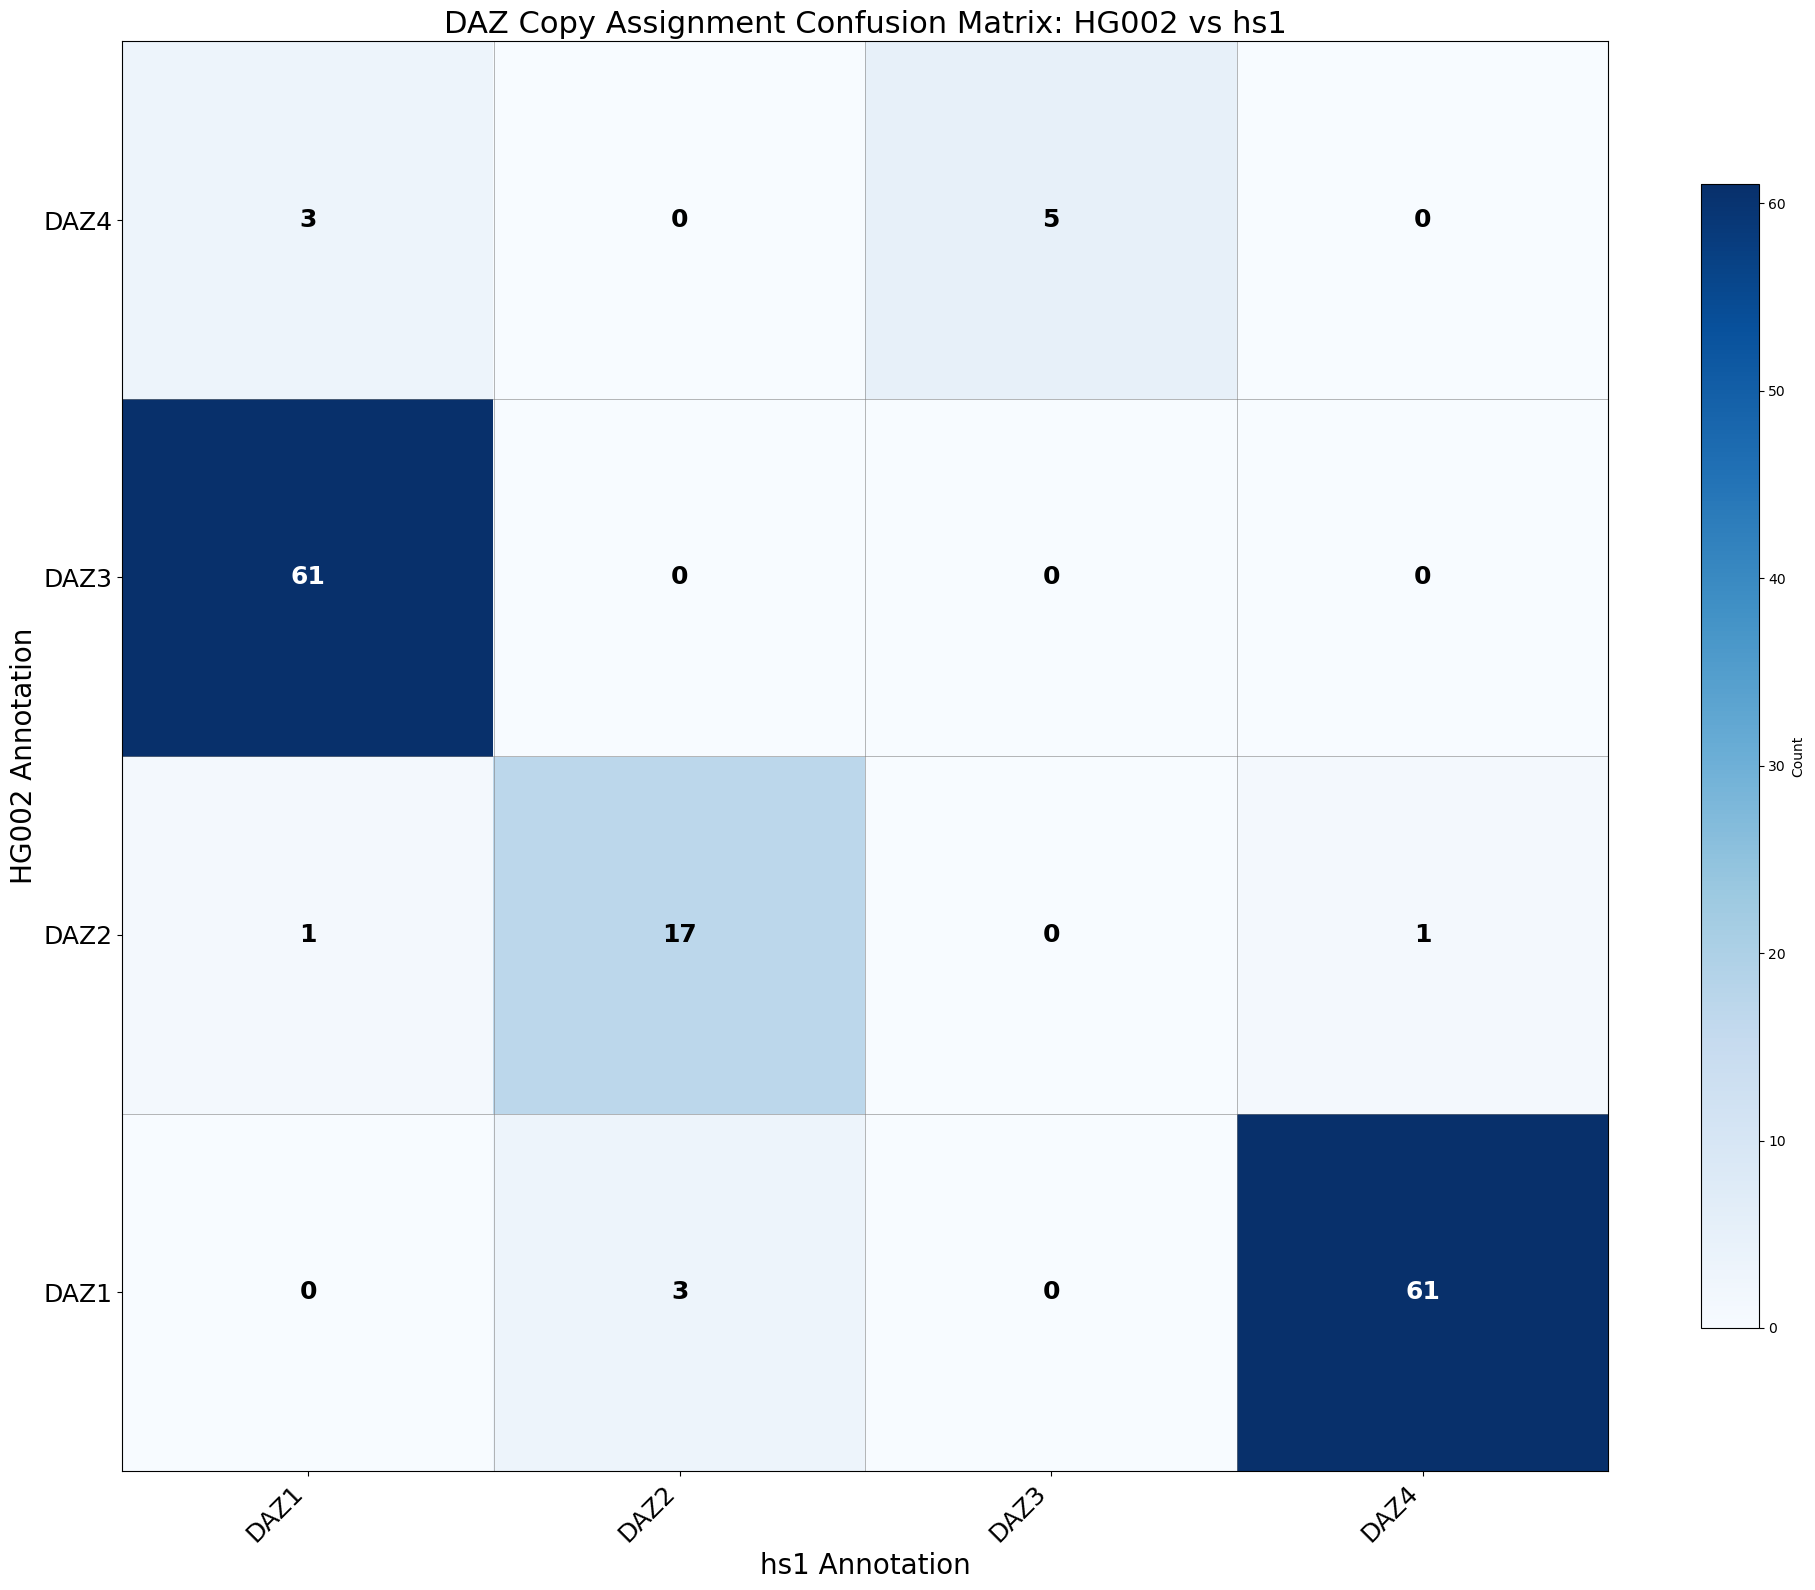

In [78]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
df = DAZ_compareDF.copy()
# Split into T2T and HG002 rows only
t2t_rows  = df[df["sample"] == "T2T"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_T2T"})
hg002_rows = df[df["sample"] == "HG002"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_HG002"})
# Merge on read_name (inner join: only reads present in both)
merged = hg002_rows.merge(t2t_rows, on="read_name")
# Build ordered label list
t2t_genes  = set(merged["Gene_T2T"].unique())
hg002_genes = set(merged["Gene_HG002"].unique())
shared     = sorted(t2t_genes & hg002_genes)
t2t_only   = sorted(t2t_genes - hg002_genes)
hg002_only  = sorted(hg002_genes - t2t_genes)
col_order = shared + t2t_only
row_order = shared + hg002_only
# Build confusion matrix
confusion = pd.crosstab(
    merged["Gene_HG002"],
    merged["Gene_T2T"],
    rownames=["HG002 Gene"],
    colnames=["T2T Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)
data = confusion.values
nrows, ncols = data.shape
# Plot
fig, ax = plt.subplots(figsize=(20, 16))
cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())
ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")
# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=18, color=color, fontweight="bold")  # was 9
# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)
# Force all tick labels to show
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=18)  # was 9
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, rotation=0, fontsize=18)  # was 9
ax.invert_yaxis()
ax.set_xlabel("hs1 Annotation", fontsize=20)   # was 12
ax.set_ylabel("HG002 Annotation", fontsize=20)  # was 12
ax.set_title("DAZ Copy Assignment Confusion Matrix: HG002 vs hs1", fontsize=22)  # was 14
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")
matplotlib.rcParams['pdf.fonttype'] = 42
plt.tight_layout()
plt.savefig("ConfusionMatrix_HG002vsT2T.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

In [80]:
compareDF = pd.DataFrame()
for sample in ["HG01358", "HG002"]:
    sampDF = readAlignmentDF[readAlignmentDF["sample"]==sample]
    bestHitDF = sampDF[sampDF['alignPortion'] == sampDF.groupby('read_name')['alignPortion'].transform('max')]
    compareDF = pd.concat([compareDF, bestHitDF])
DAZ_compareDF = compareDF[compareDF["read_name"].isin(DAZreads_firstExon)]
DAZ_compareDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
4946153,HG01358,SRR31360662.8156476,HG01358_chrY,16,534=1D1029=1I97=1I196=3963N99=4573N35=744N72=2...,0,23679777,23730202,3325,3323,0,2,1,47101,0,0.999398,DAZ1
4946157,HG01358,SRR31360662.11636271,HG01358_chrY,16,1857=3963N99=4573N35=744N1=1X70=2313N72=9714N7...,60,23679777,23749498,4399,4397,1,0,0,65323,1,0.999545,DAZ1
4946158,HG01358,SRR31360662.14576794,HG01358_chrY,16,292=1D342=1X18=1I362=1D42=1I54=1D290=1D452=396...,60,23679777,23749457,4368,4364,1,2,5,65310,1,0.999084,DAZ1
4946176,HG01358,SRR31360662.52558156,HG01358_chrY,16,365=1D248=1D1242=3963N99=4573N35=744N72=2313N7...,0,23679777,23730304,3511,3510,0,1,5,47012,0,0.999715,DAZ1
4946178,HG01358,SRR31360662.56692402,HG01358_chrY,16,11=1D1024=1D321=1I121=1D377=3963N99=4573N35=74...,13,23679777,23740811,3667,3665,1,1,3,57365,0,0.999455,DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263682,HG002,SRR31360662.44468361,HG002_chrY,0,250S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25718174,2234,1938,22,24,0,42094,250,0.867502,DAZ2
1263683,HG002,SRR31360662.48310520,HG002_chrY,0,3S3=1X76=2319N72=2324N360I72=2311N72=2324N72=2...,11,25674120,25719125,3296,2895,14,384,2,42094,3,0.878337,DAZ2
1263684,HG002,SRR31360662.49507025,HG002_chrY,0,139S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25718329,2278,2093,22,24,0,42094,139,0.918788,DAZ2
1263685,HG002,SRR31360662.54639327,HG002_chrY,0,253S3=1X5=1X2=1X4=1X7=2X5=1X2=1X34=1X9=2319N72...,60,25674120,25717880,1942,1641,23,25,2,42094,253,0.845005,DAZ2


In [81]:
genes = []
for i in DAZ_compareDF["Gene"]:
    if "|" in i:
        genes.append(i.split("|")[-1])
    else:
        genes.append(i)
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/765921303.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


In [82]:
genes = []
for i in DAZ_compareDF["cleanGene"]:
    if i == "DAZ3/DAZ4":
        genes.append("DAZ3")
    else:
        genes.append(i) 
DAZ_compareDF["cleanGene"] = genes

/tmp/ipykernel_3375735/2178502930.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DAZ_compareDF["cleanGene"] = genes


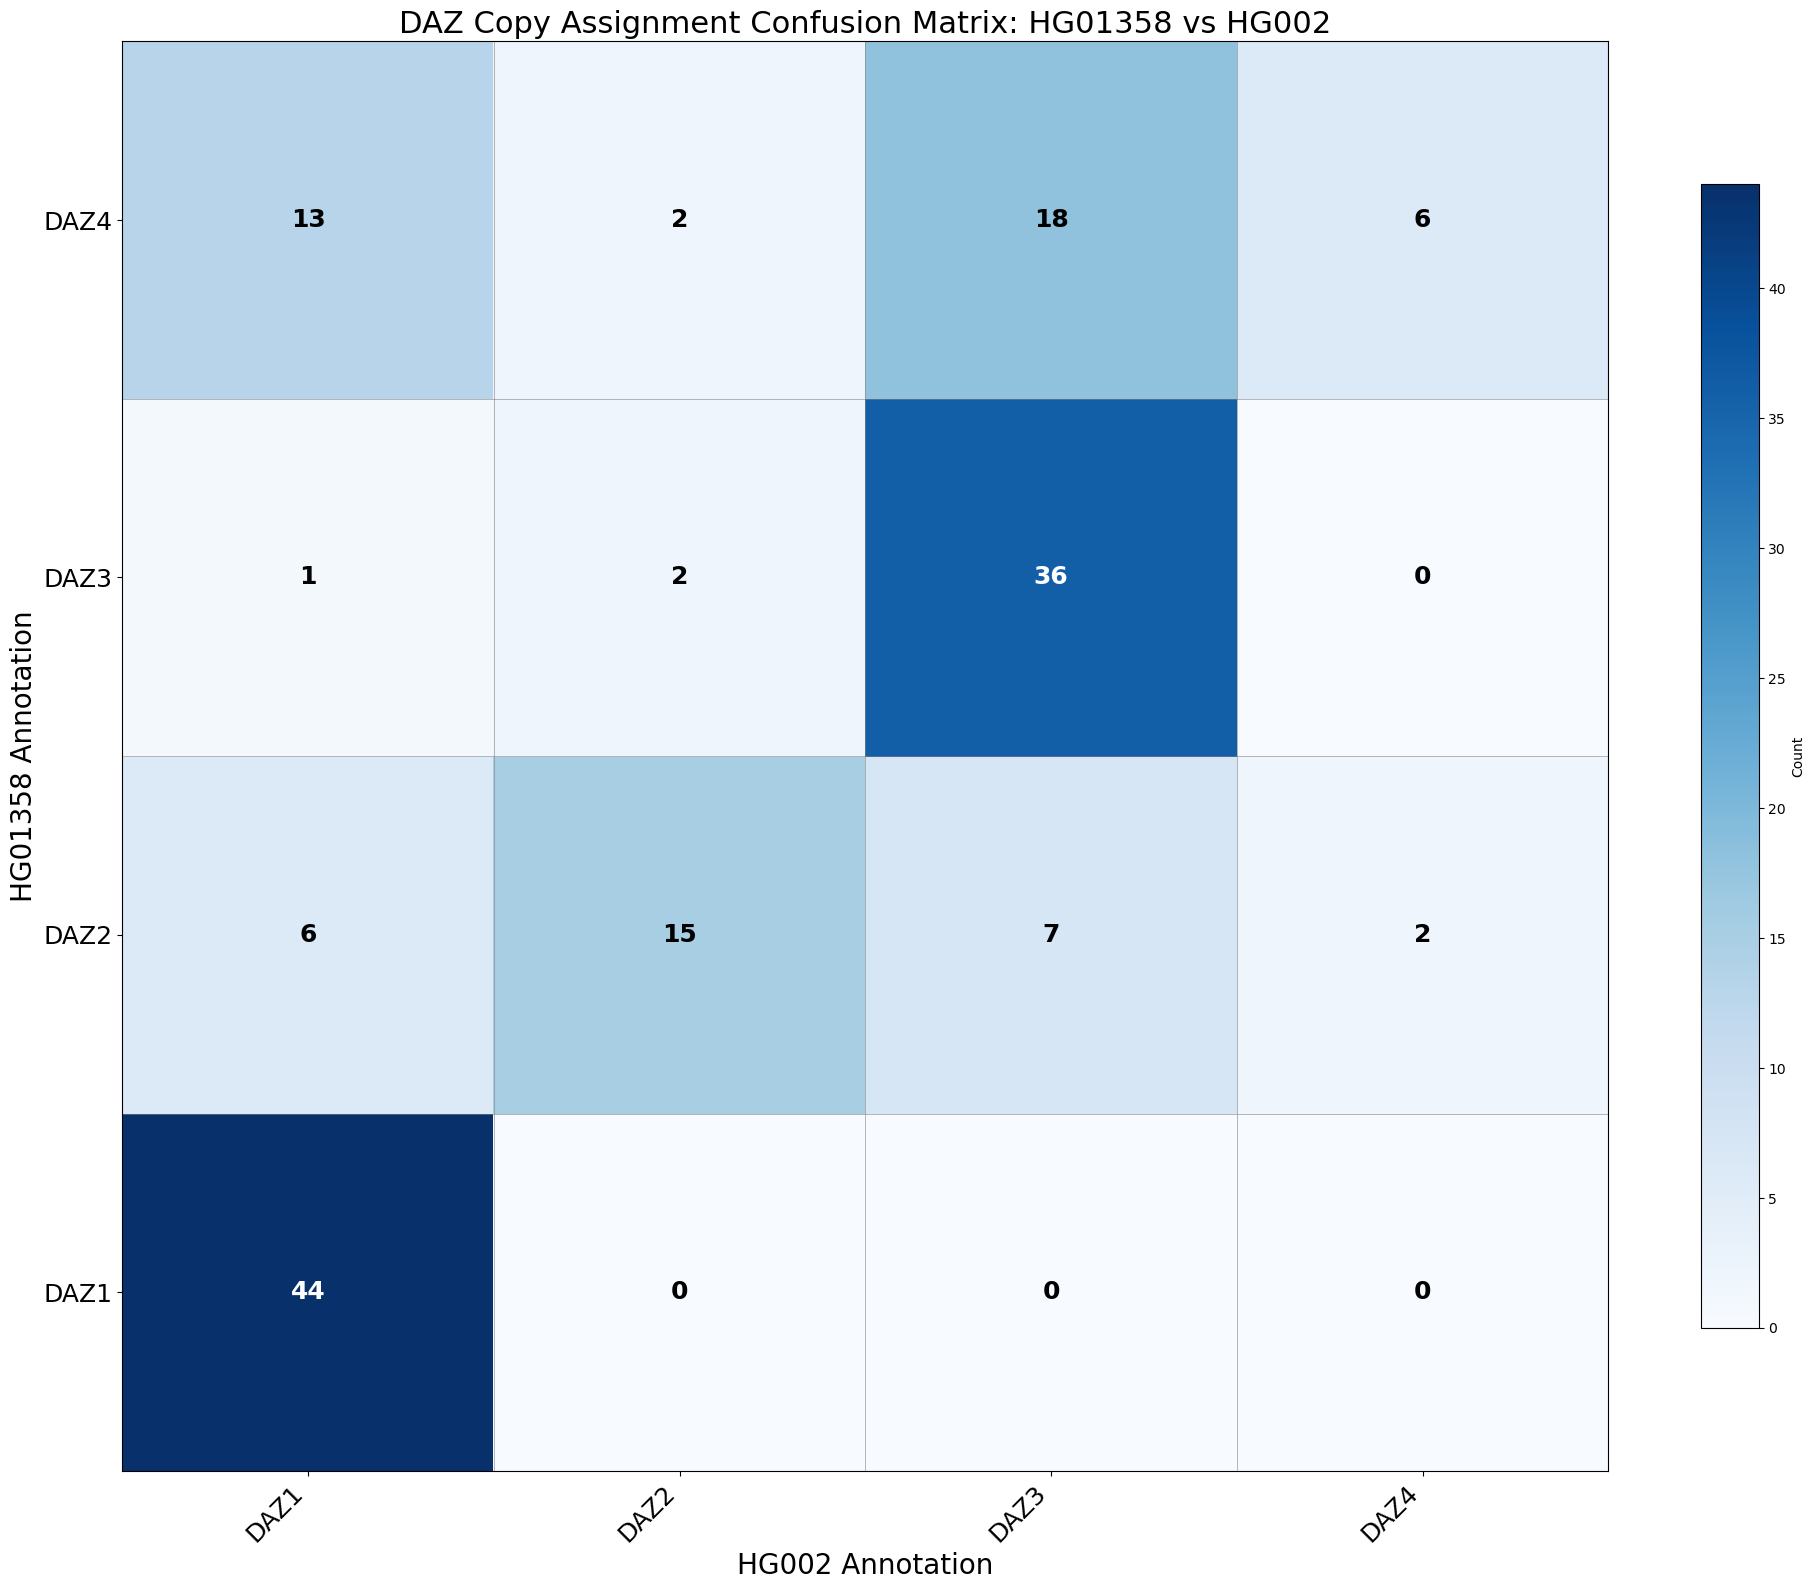

In [83]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = DAZ_compareDF.copy()

# Split into T2T and HG002 rows only
t2t_rows   = df[df["sample"] == "HG01358"][["read_name", "cleanGene"]].rename(columns={"cleanGene": "Gene_HG01358"})
hg002_rows = df[df["sample"] == "HG002"][["read_name", "cleanGene", "sample"]].rename(columns={"cleanGene": "Gene_HG002"})

# Merge on read_name (inner join: only reads present in both)
merged = hg002_rows.merge(t2t_rows, on="read_name")

# Build ordered label list
t2t_genes   = set(merged["Gene_HG01358"].unique())
hg002_genes = set(merged["Gene_HG002"].unique())
shared      = sorted(t2t_genes & hg002_genes)
t2t_only    = sorted(t2t_genes - hg002_genes)
hg002_only  = sorted(hg002_genes - t2t_genes)

col_order = shared + hg002_only   # HG002 on x-axis
row_order = shared + t2t_only     # HG01358 on y-axis

# Build confusion matrix — HG01358 as rows, HG002 as columns
confusion = pd.crosstab(
    merged["Gene_HG01358"],        # rows → y-axis
    merged["Gene_HG002"],          # cols → x-axis
    rownames=["HG01358 Gene"],
    colnames=["HG002 Gene"]
).reindex(index=row_order, columns=col_order, fill_value=0)

data = confusion.values
nrows, ncols = data.shape

# Plot
fig, ax = plt.subplots(figsize=(20, 16))
cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=data.max())
ax.imshow(data, aspect="auto", cmap=cmap, norm=norm, origin="upper")

# Annotate every cell with adaptive text color
thresh = data.max() / 2.0
for i in range(nrows):
    for j in range(ncols):
        val = data[i, j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=18, color=color, fontweight="bold")

# Grid lines
for x in np.arange(-0.5, ncols, 1):
    ax.axvline(x, color="gray", linewidth=0.4)
for y in np.arange(-0.5, nrows, 1):
    ax.axhline(y, color="gray", linewidth=0.4)

# Tick labels
ax.set_xticks(range(ncols))
ax.set_xticklabels(col_order, rotation=45, ha="right", fontsize=18)
ax.set_yticks(range(nrows))
ax.set_yticklabels(row_order, rotation=0, fontsize=18)
ax.invert_yaxis()

ax.set_xlabel("HG002 Annotation", fontsize=20)
ax.set_ylabel("HG01358 Annotation", fontsize=20)
ax.set_title("DAZ Copy Assignment Confusion Matrix: HG01358 vs HG002", fontsize=22)

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.8, label="Count")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
plt.tight_layout()
plt.savefig("ConfusionMatrix_HG01358vsHG002.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Distribution of Genome Alignment Accuracy 

In [84]:
famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":RBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads_firstExon}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

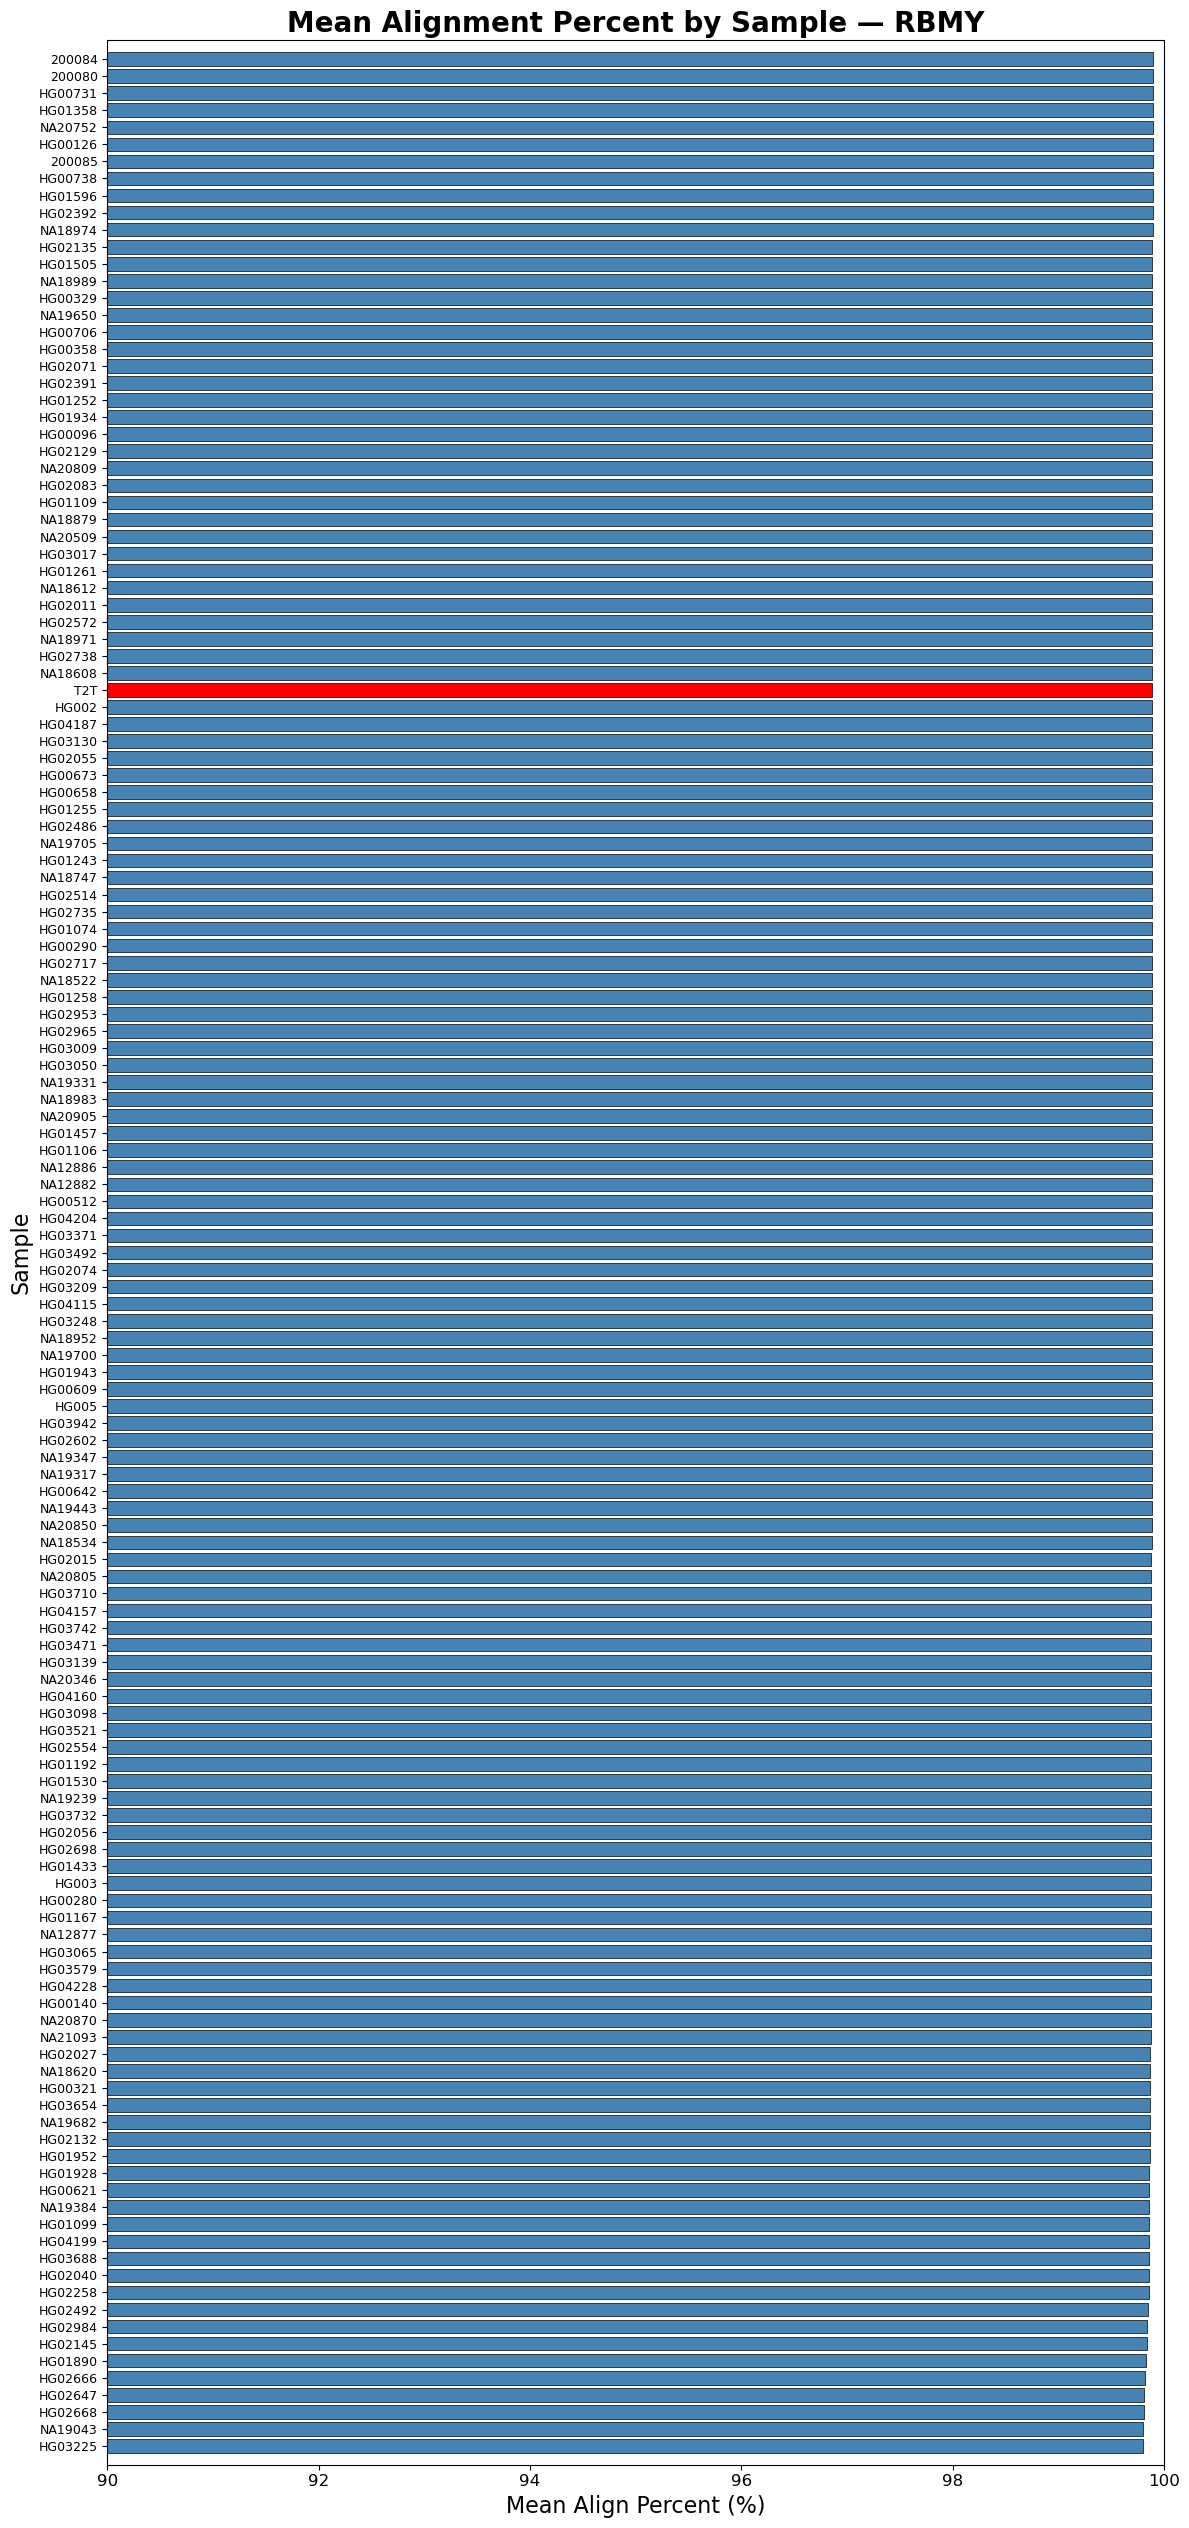

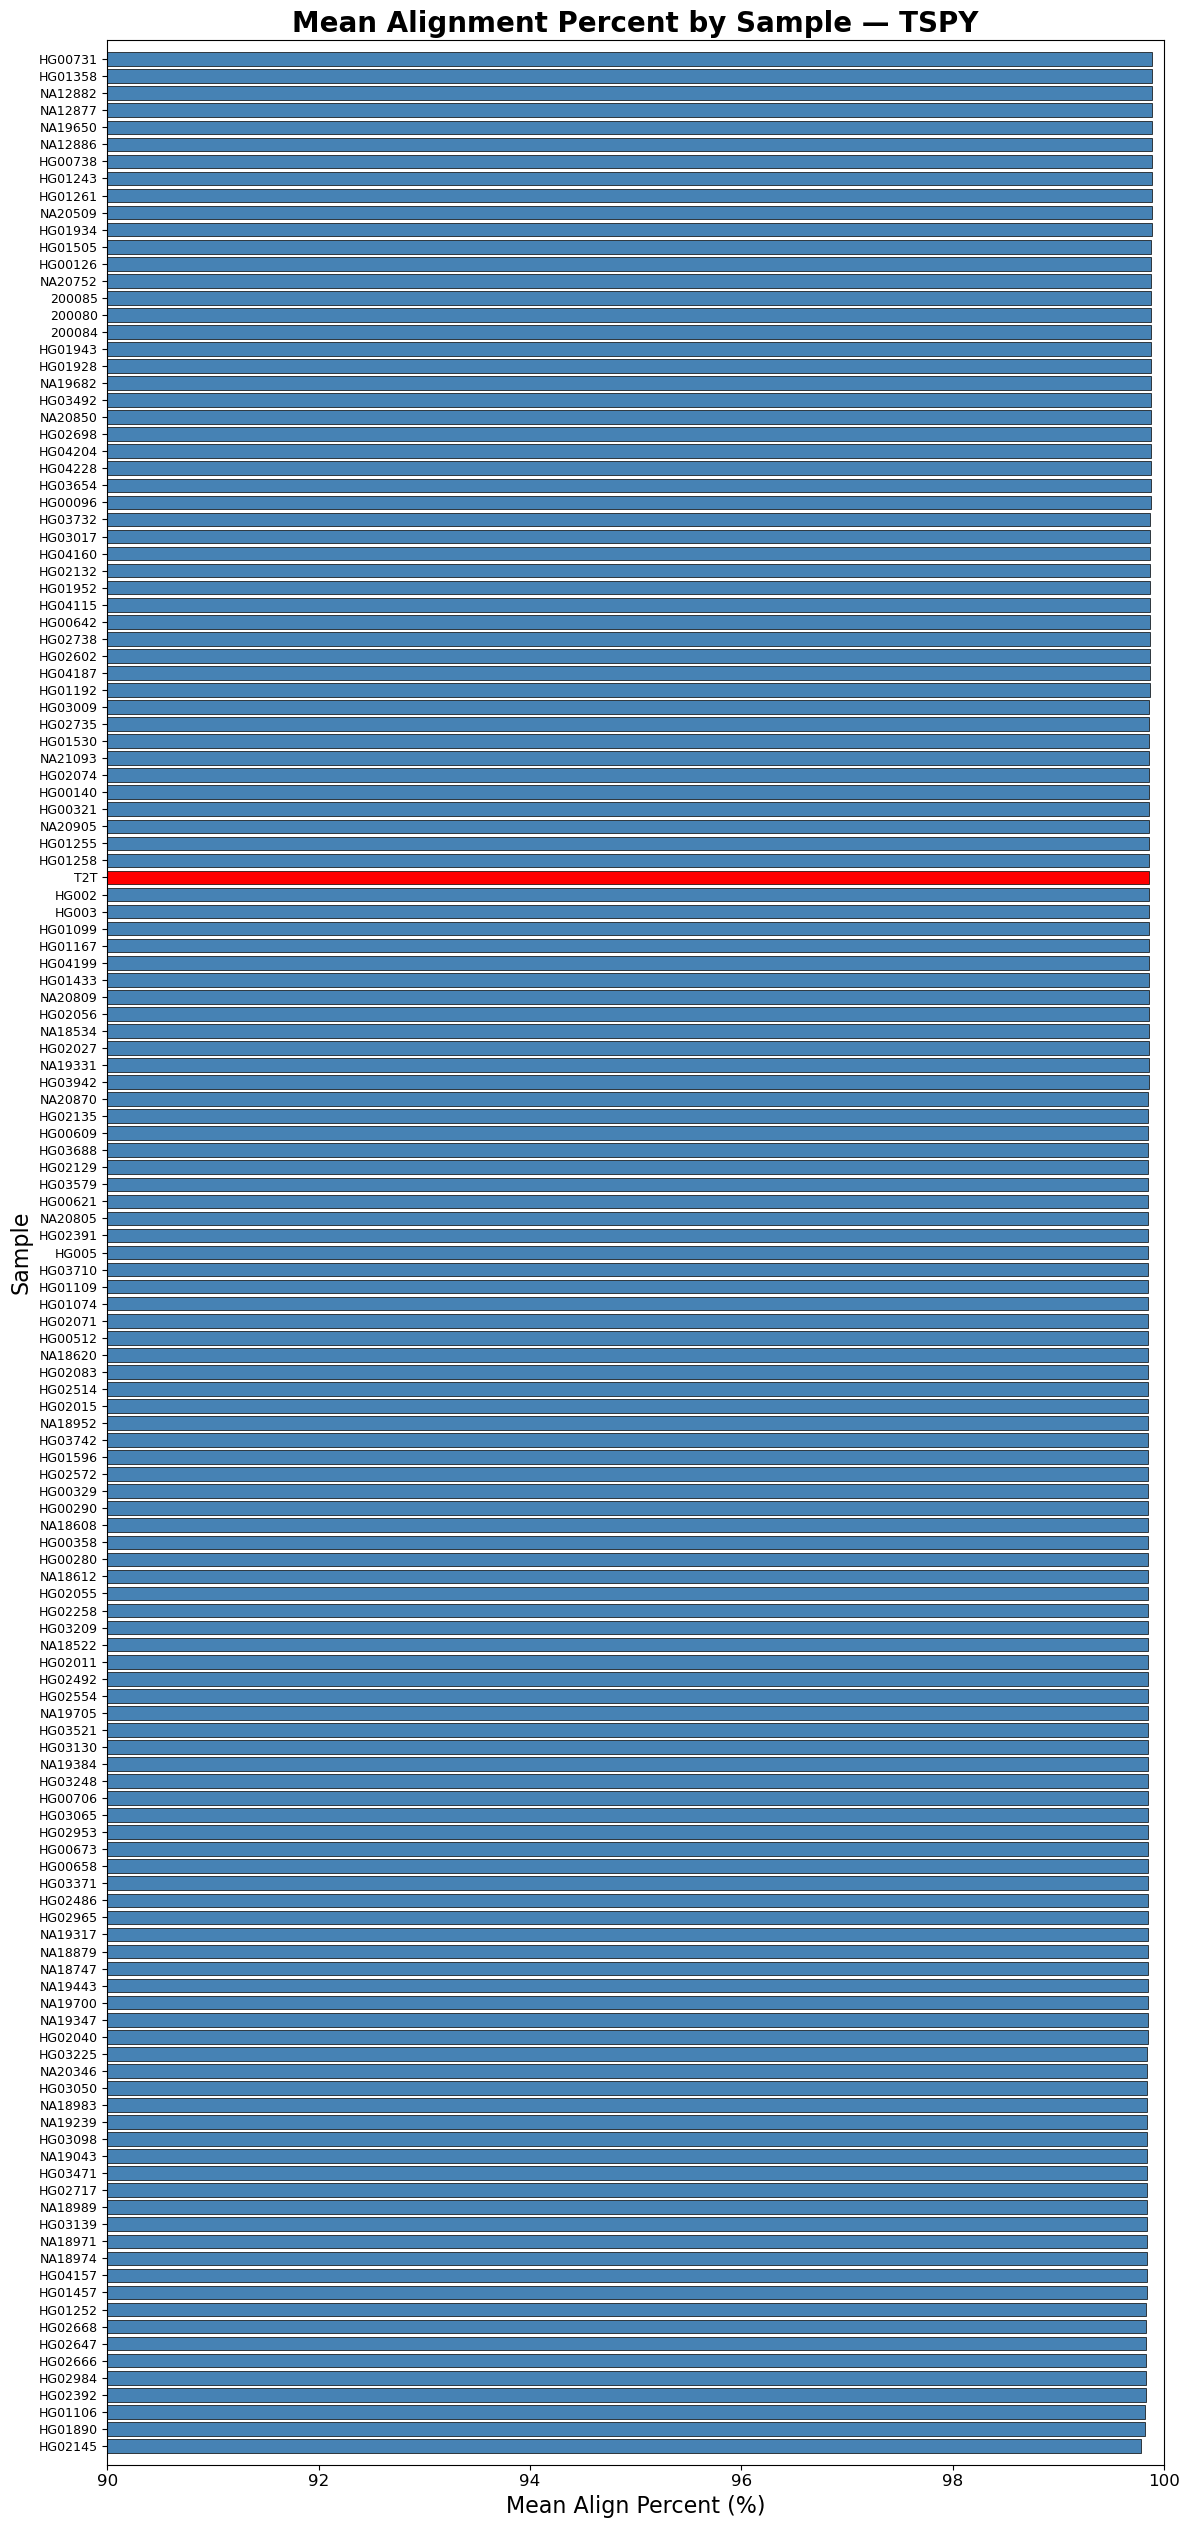

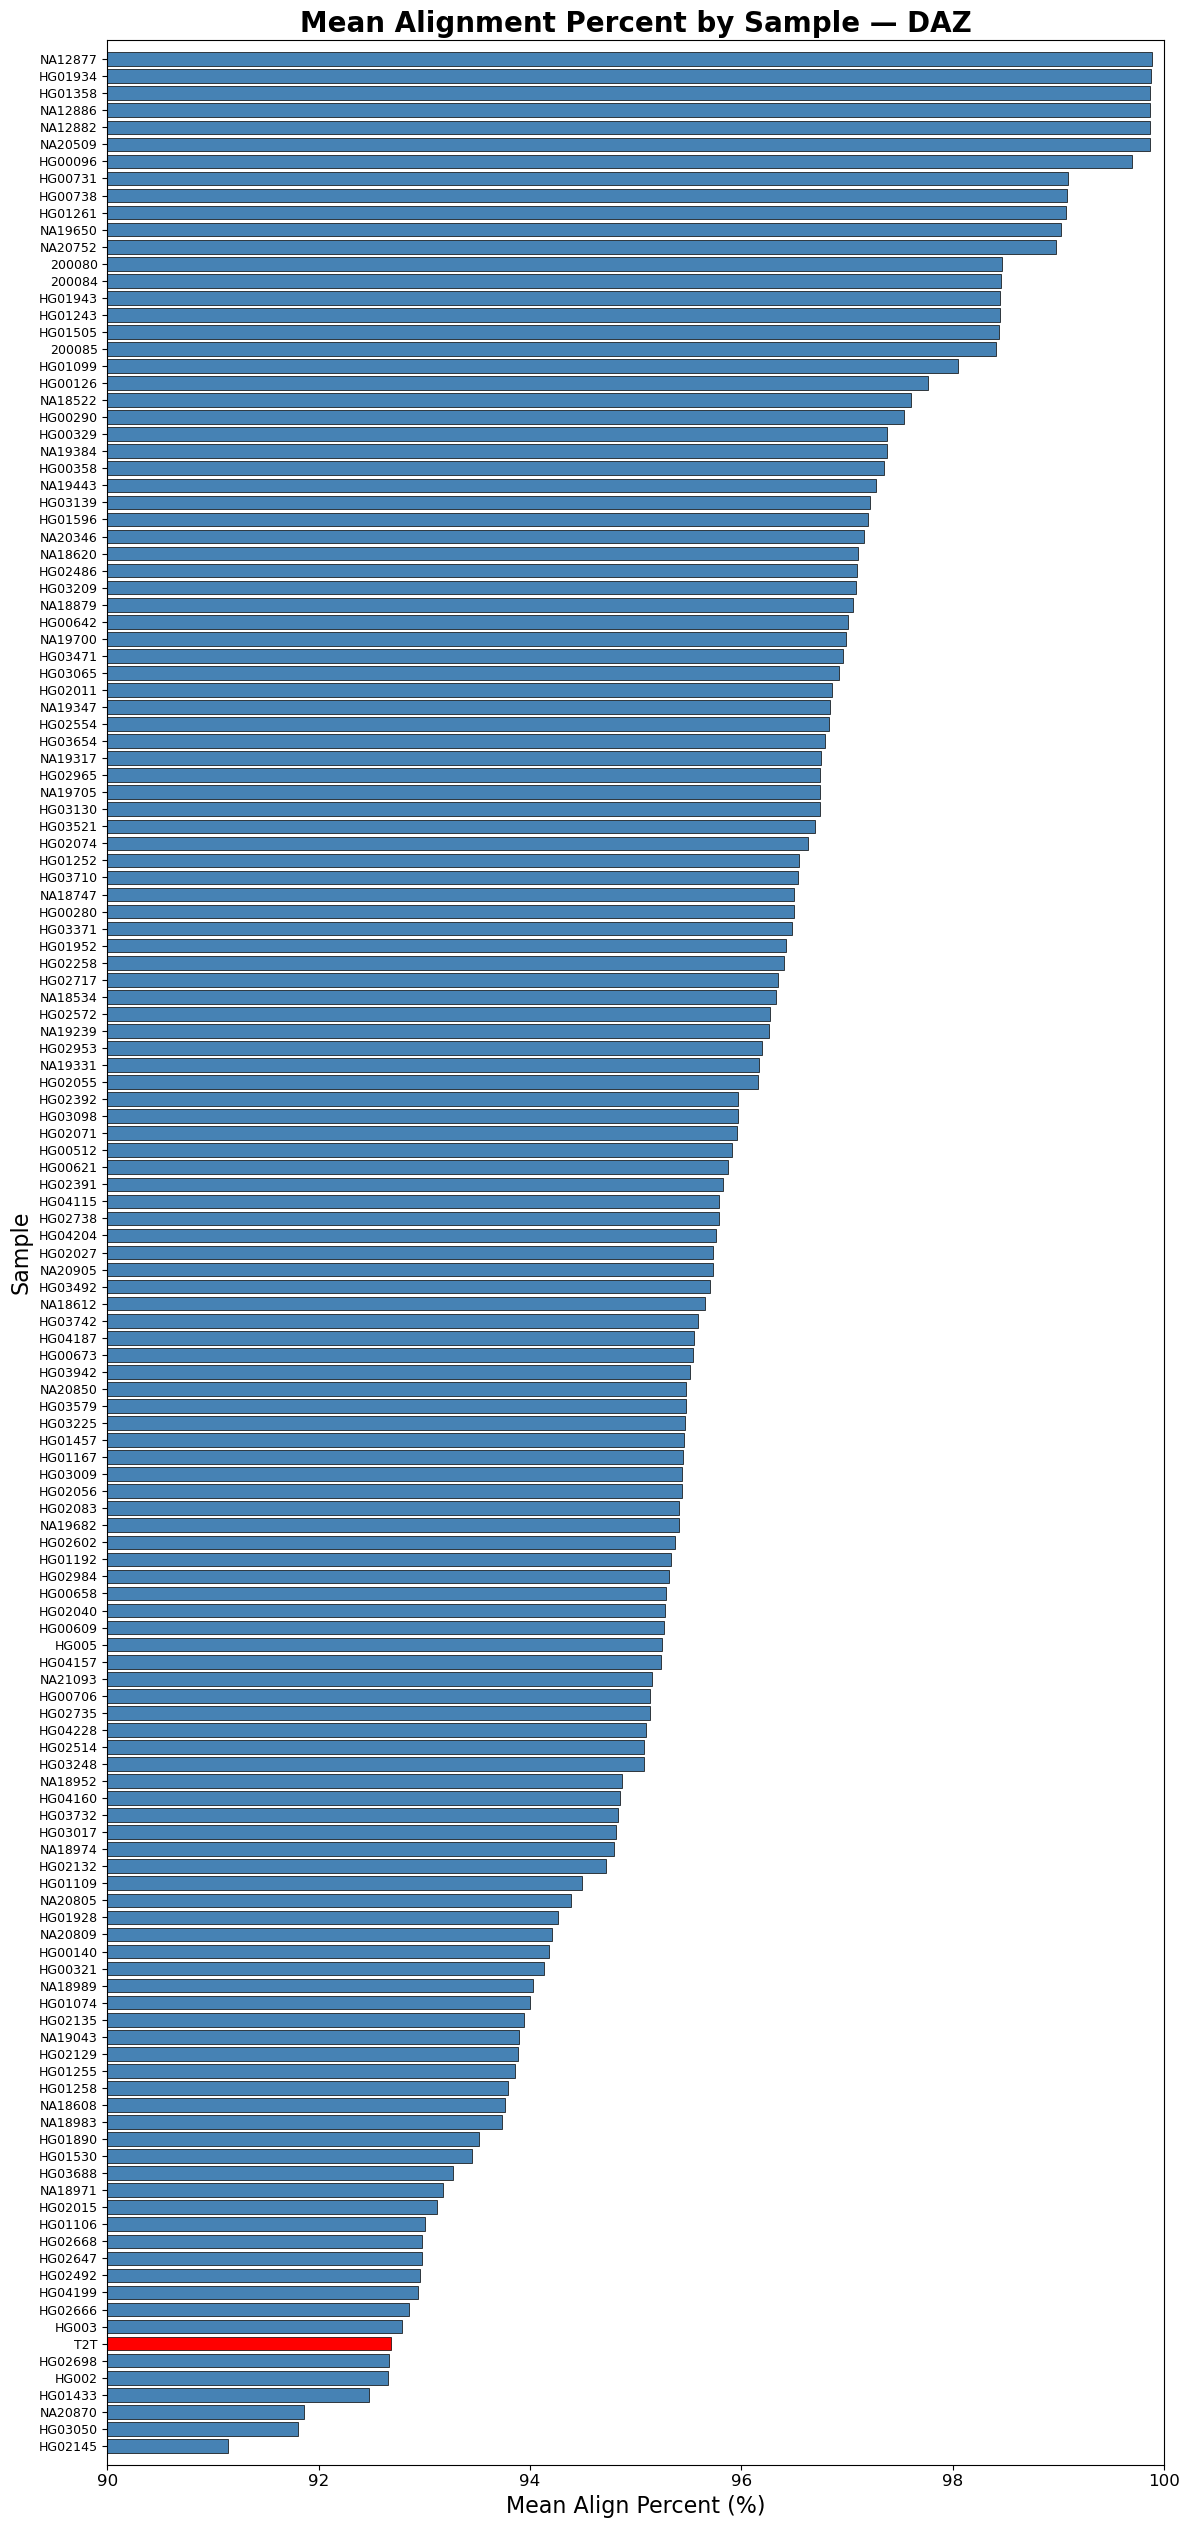

In [85]:
import matplotlib.pyplot as plt
import numpy as np

fams = ["RBMY", "TSPY", "DAZ"]

for fam in fams:
    sample_means = famSampAlignQuality_dict[fam]

    sorted_items = sorted(sample_means.items(), key=lambda x: x[1])
    samples_list = [k for k, v in sorted_items]
    means = [v * 100 for k, v in sorted_items]  # convert to percent

    colors = ['red' if s == 'T2T' else 'steelblue' for s in samples_list]

    # height scales with number of samples so rows never crowd
    height = max(8, len(samples_list) * 0.18)
    fig, ax = plt.subplots(figsize=(12, height))

    ax.barh(range(len(samples_list)), means, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(samples_list)))
    ax.set_yticklabels(samples_list, fontsize=9)
    ax.set_title(f"Mean Alignment Percent by Sample — {fam}", fontsize=20, fontweight='bold')
    ax.set_xlabel("Mean Align Percent (%)", fontsize=16)
    ax.set_ylabel("Sample", fontsize=16)
    ax.set_xlim(90, 100)
    ax.tick_params(axis='x', labelsize=12)
    ax.margins(y=0.005)  # trim dead space above/below the bars

    plt.tight_layout()
    plt.savefig(f"genomeAlignPercentDistribution_{fam}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"genomeAlignPercentDistribution_{fam}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

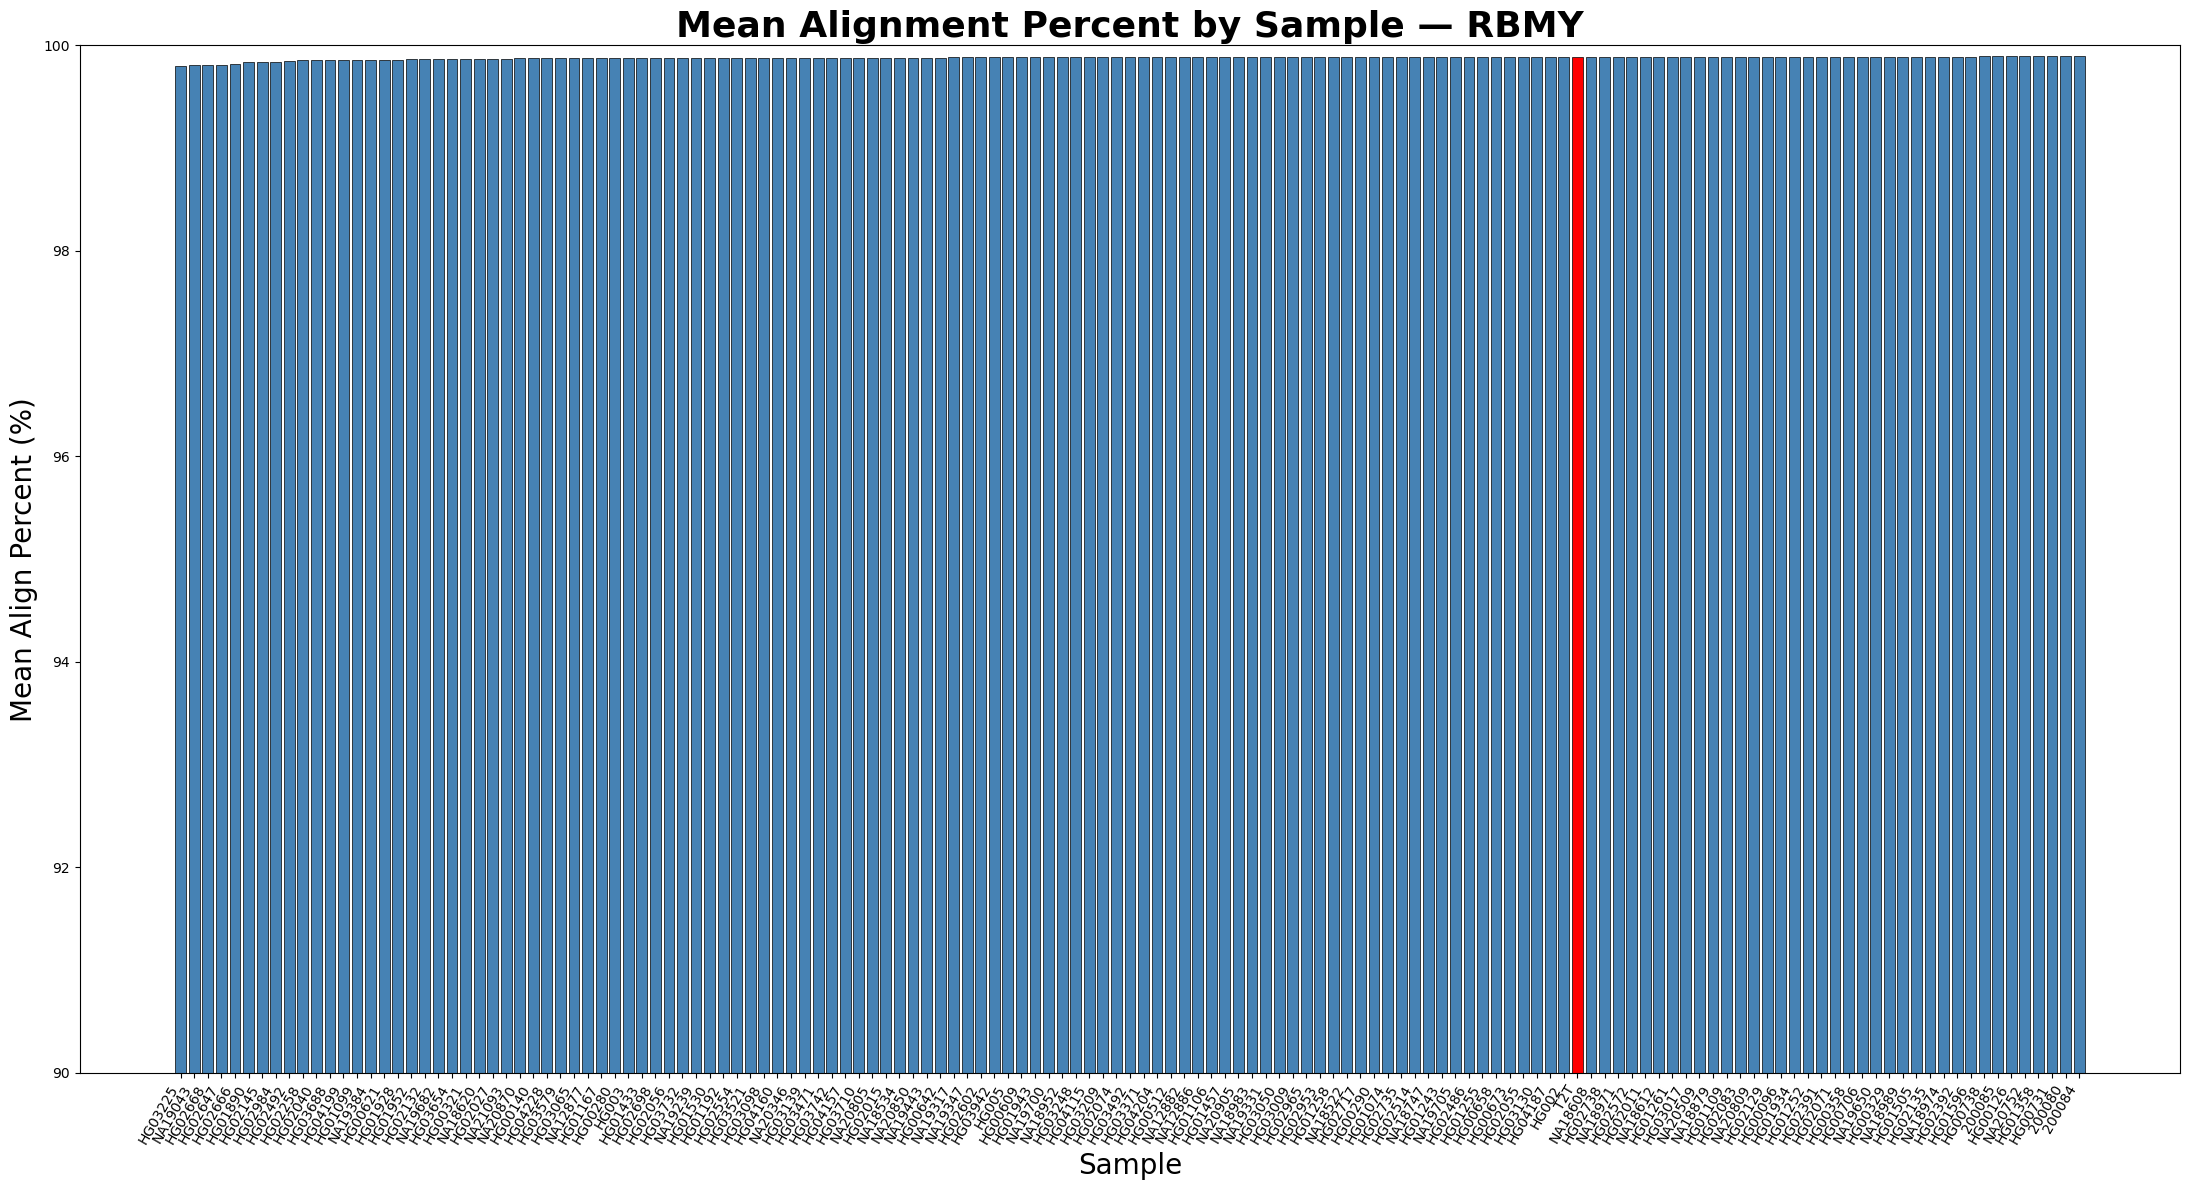

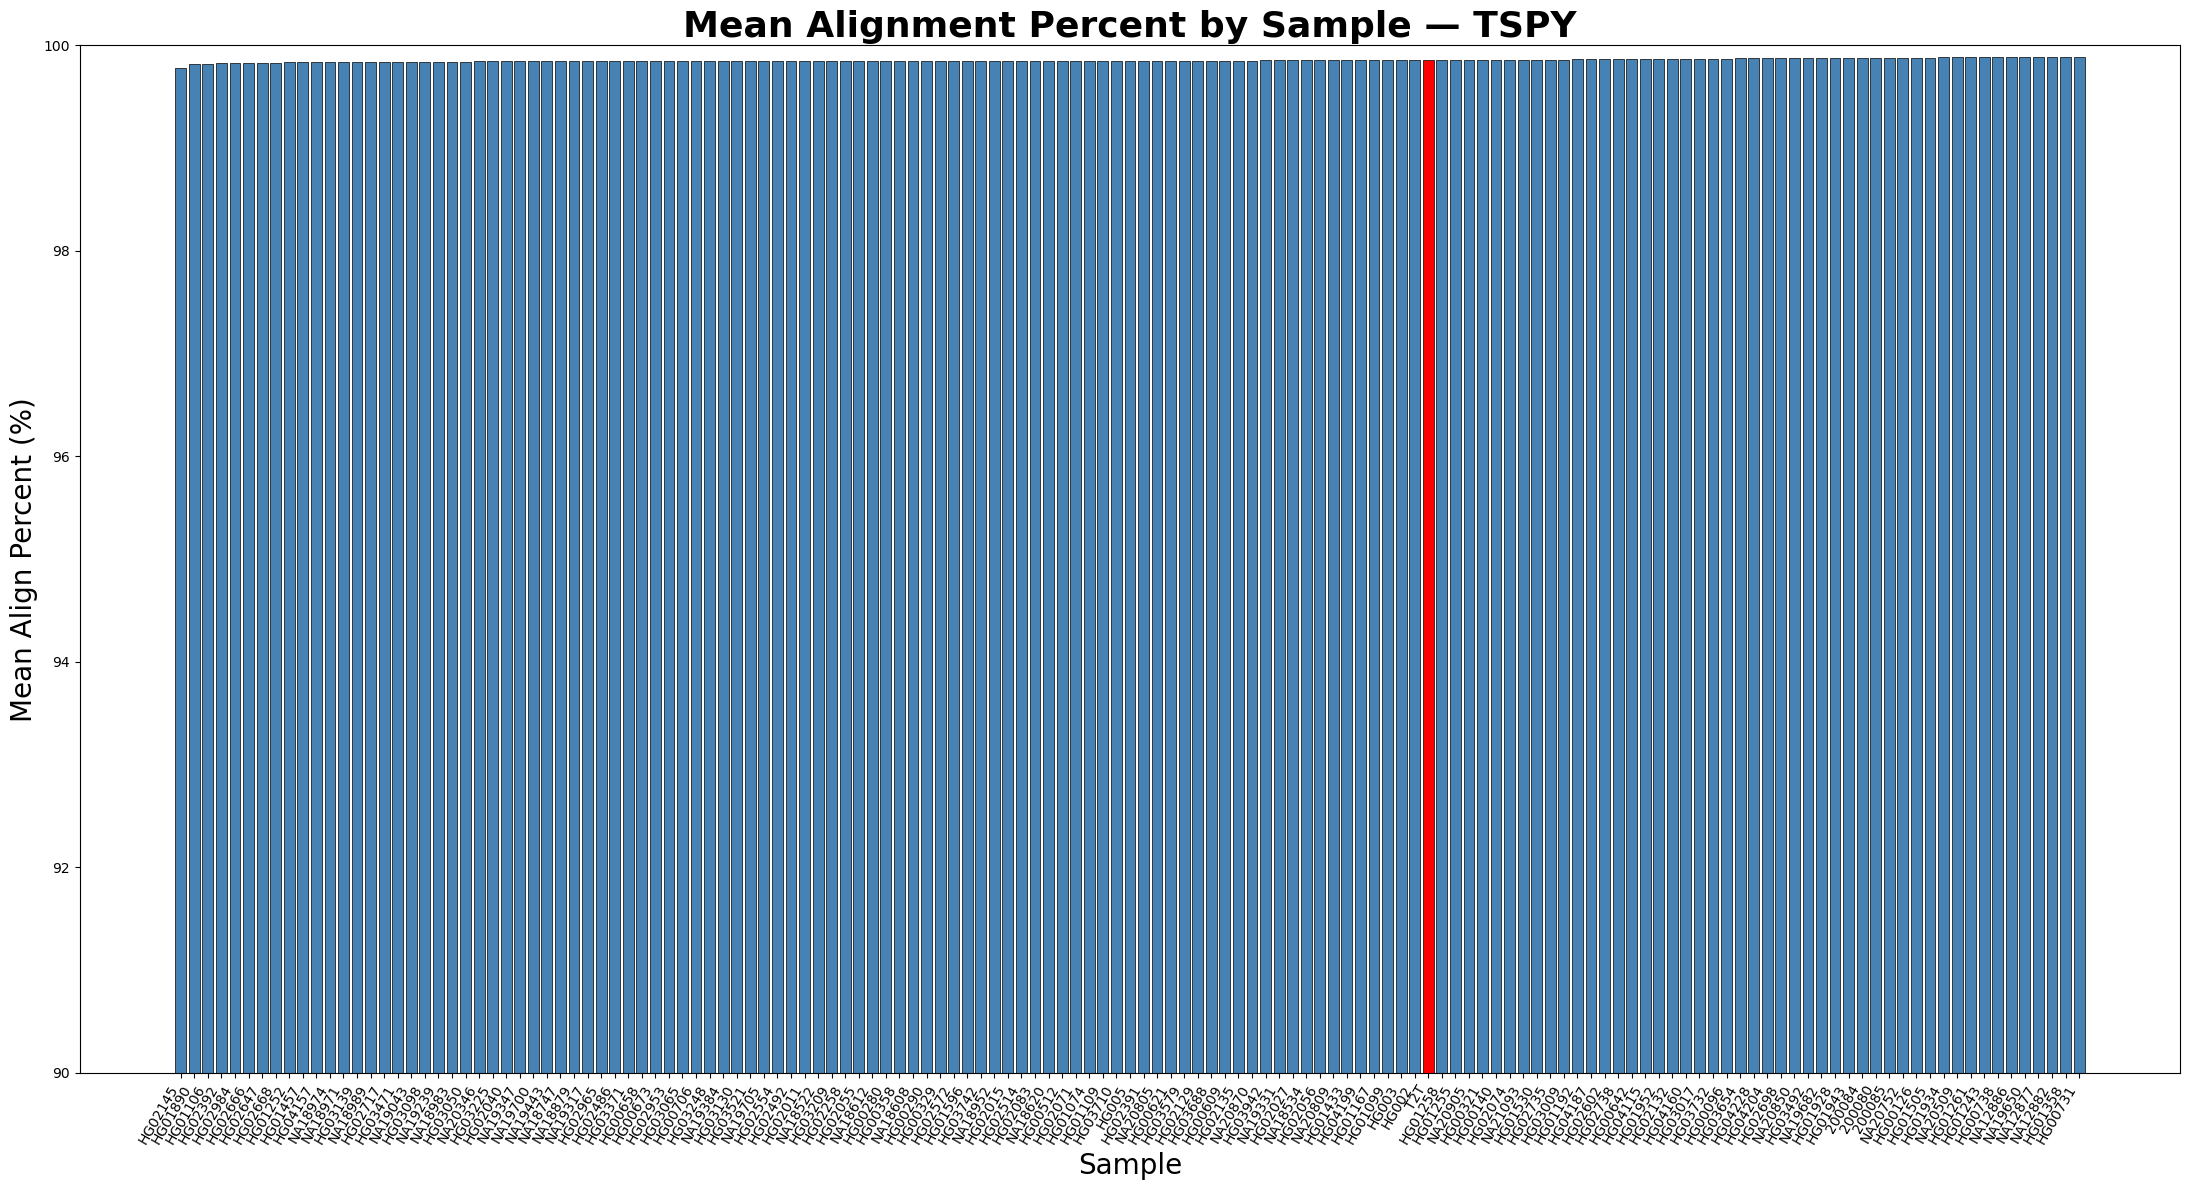

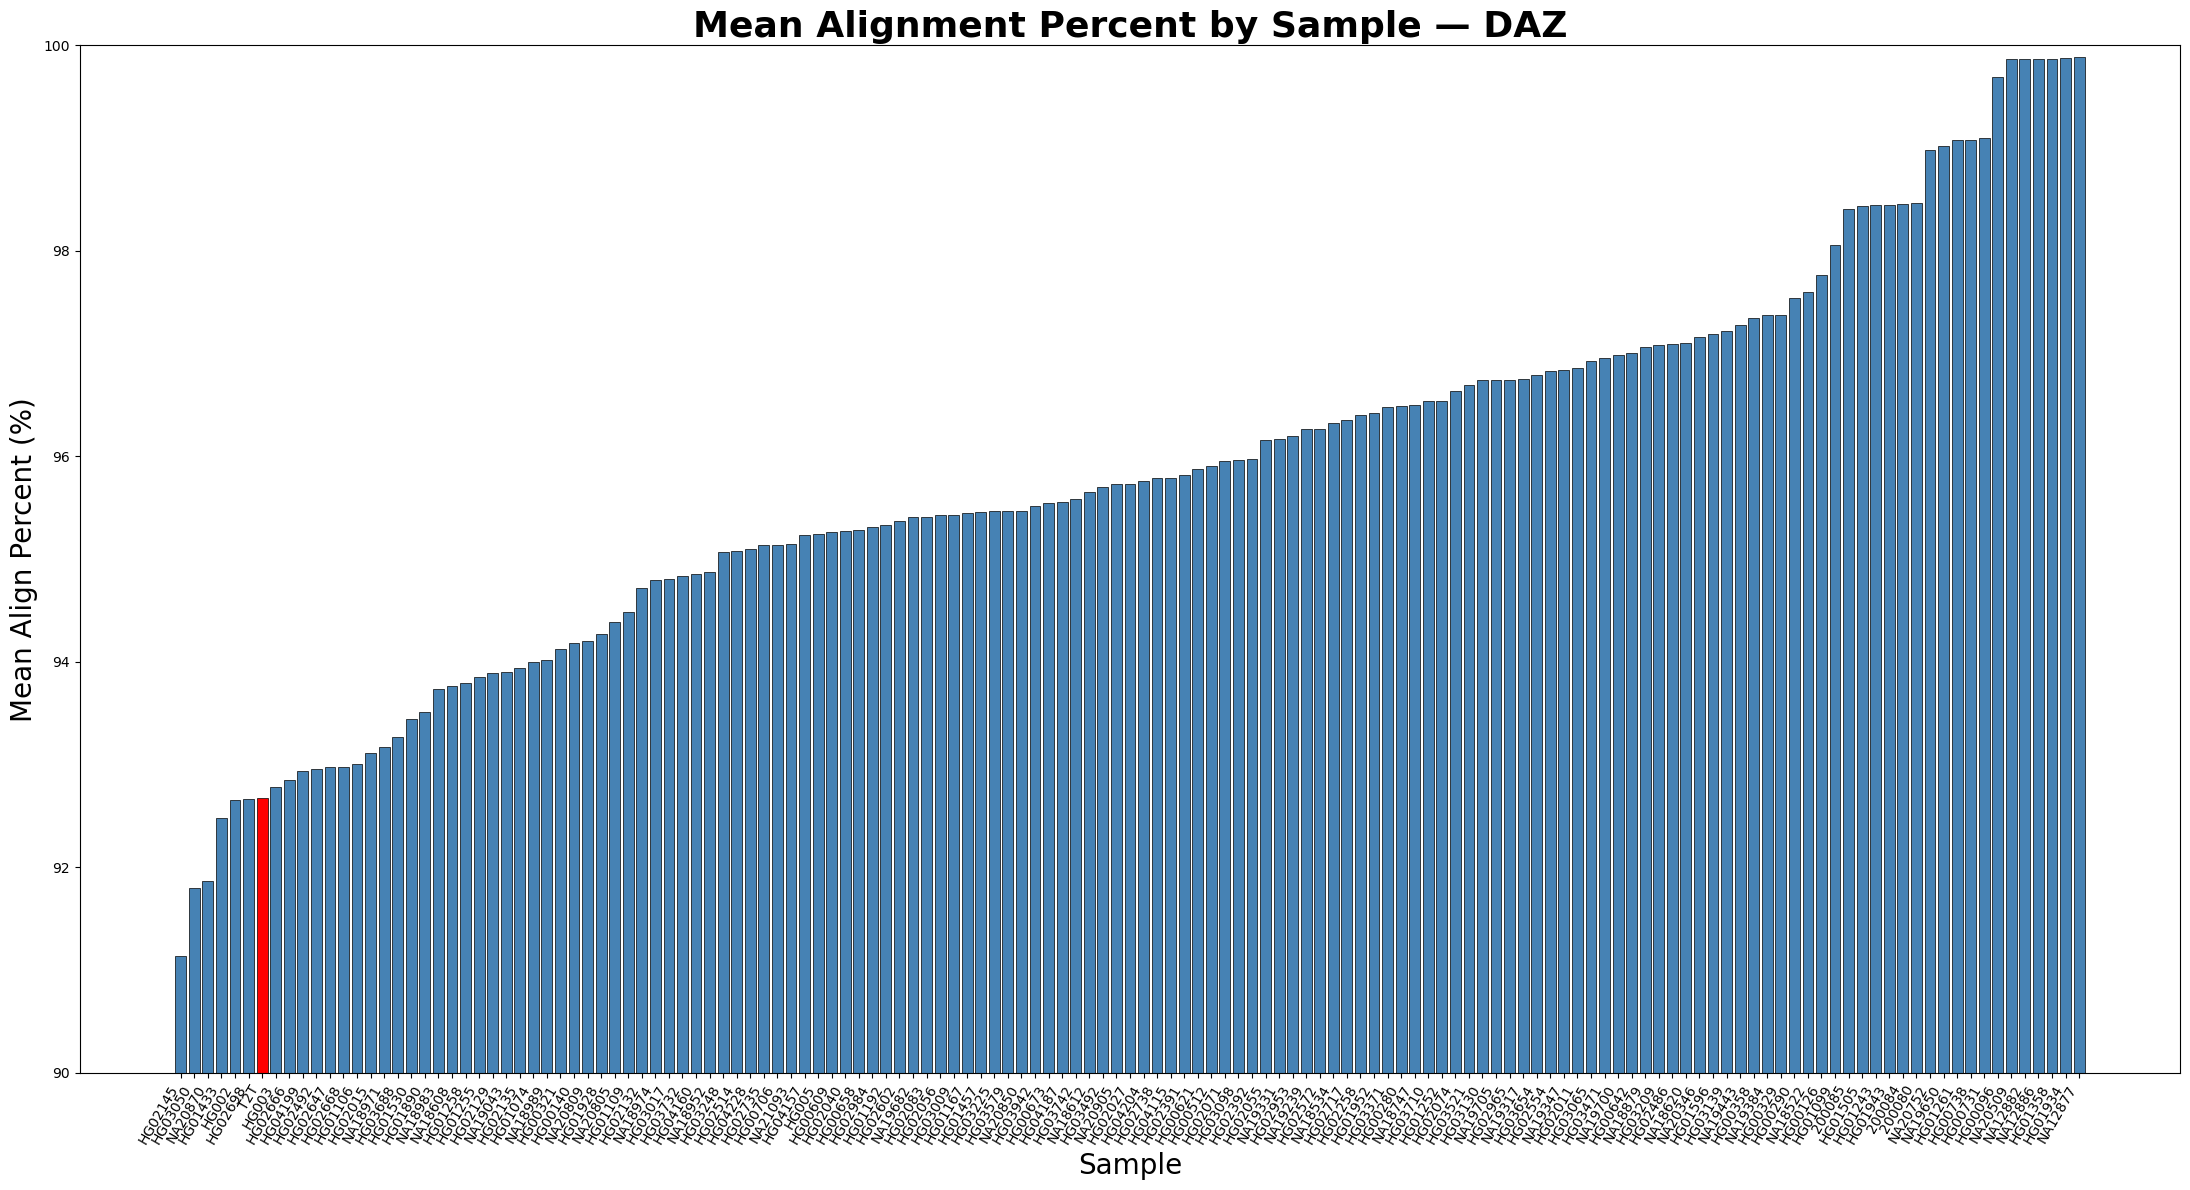

In [86]:
import matplotlib.pyplot as plt
import numpy as np

fams = ["RBMY", "TSPY", "DAZ"]

for fam in fams:
    sample_means = famSampAlignQuality_dict[fam]

    sorted_items = sorted(sample_means.items(), key=lambda x: x[1])
    samples_list = [k for k, v in sorted_items]
    means = [v * 100 for k, v in sorted_items]  # convert to percent

    colors = ['red' if s == 'T2T' else 'steelblue' for s in samples_list]

    fig, ax = plt.subplots(figsize=(22, 12))
    ax.bar(range(len(samples_list)), means, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(samples_list)))
    ax.set_xticklabels(samples_list, rotation=60, ha='right', fontsize=10)
    ax.set_title(f"Mean Alignment Percent by Sample — {fam}", fontsize=26, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=20)
    ax.set_ylabel("Mean Align Percent (%)", fontsize=20)
    ax.set_ylim(90, 100)
    ax.tick_params(axis='y', labelsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0f}"))

    plt.tight_layout()
    plt.savefig(f"genomeAlignPercentDistribution_{fam}.png", dpi=300, bbox_inches='tight')
    plt.savefig(f"genomeAlignPercentDistribution_{fam}.pdf", dpi=300, bbox_inches='tight')
    plt.show()

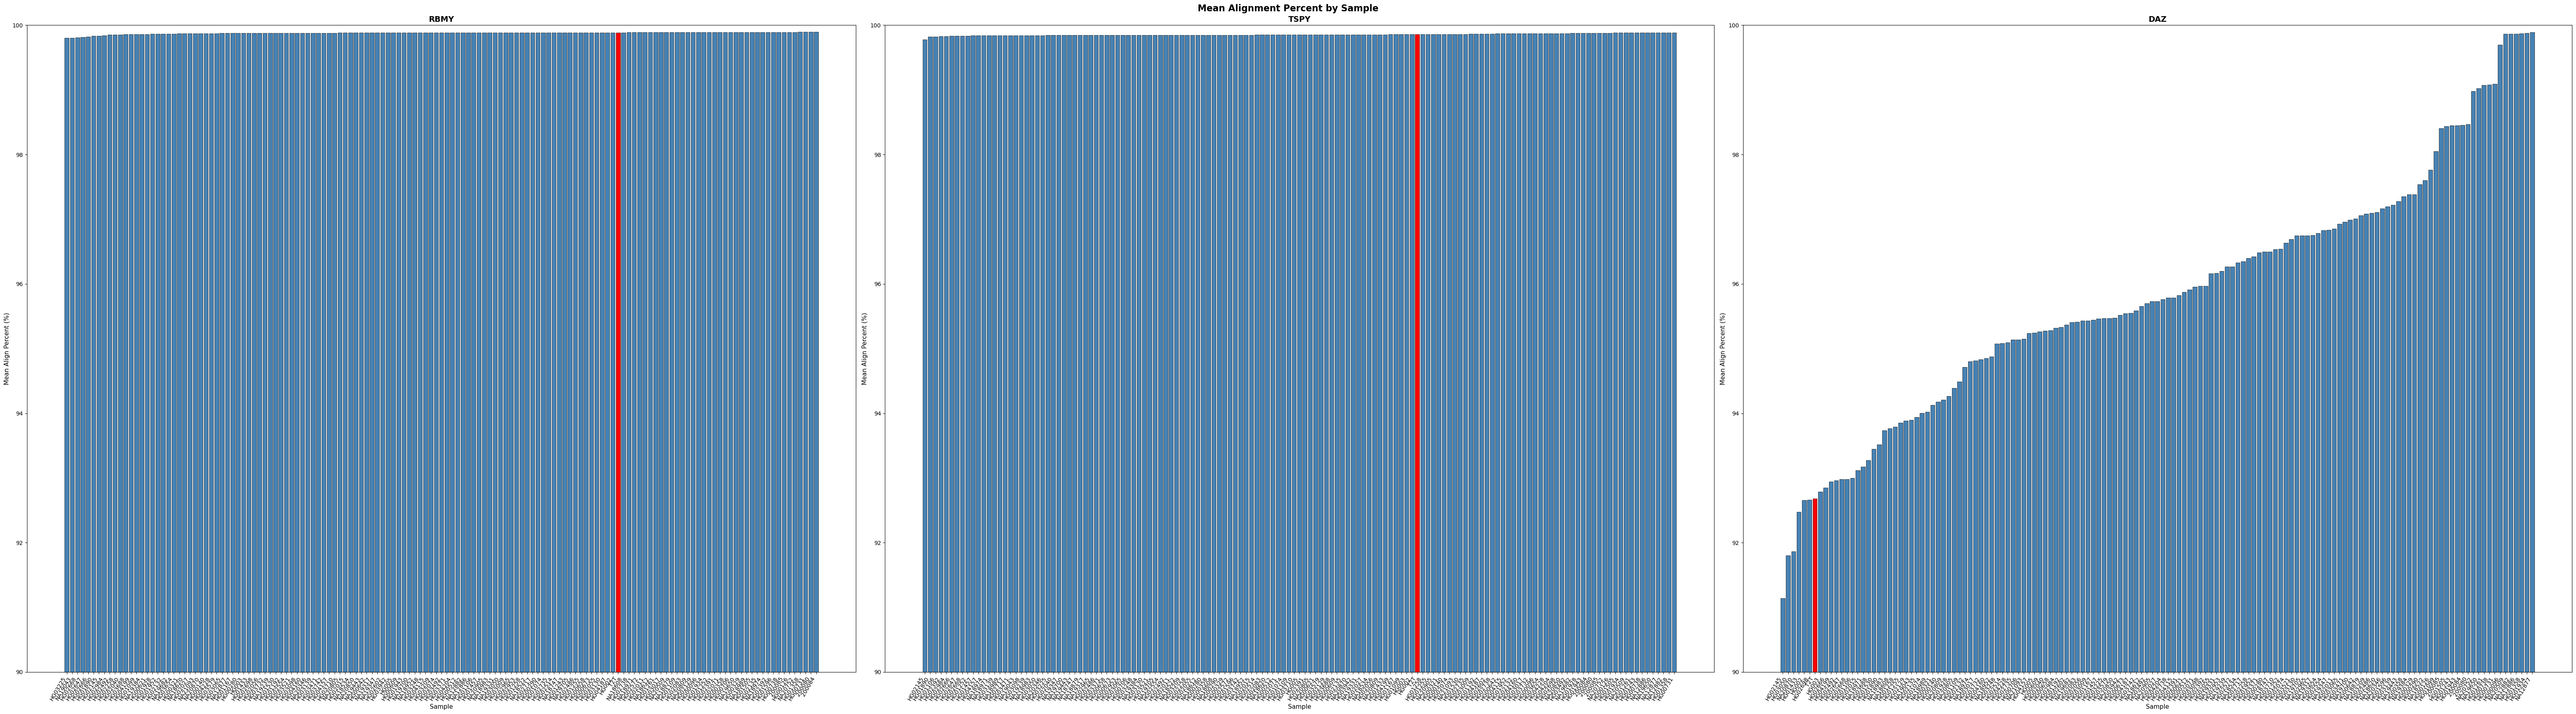

In [87]:
import matplotlib.pyplot as plt
import numpy as np

fams = ["RBMY", "TSPY", "DAZ"]
fig, axes = plt.subplots(1, 3, figsize=(64, 24))

for ax, fam in zip(axes, fams):
    sample_means = famSampAlignQuality_dict[fam]
    
    sorted_items = sorted(sample_means.items(), key=lambda x: x[1])
    samples_list = [k for k, v in sorted_items]
    means = [v * 100 for k, v in sorted_items]  # convert to percent
    
    colors = ['red' if s == 'T2T' else 'steelblue' for s in samples_list]
    ax.bar(range(len(samples_list)), means, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(samples_list)))
    ax.set_xticklabels(samples_list, rotation=60, ha='right', fontsize=10)
    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Mean Align Percent (%)", fontsize=11)
    ax.set_ylim(90, 100)  # now in percent
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0f}"))

plt.suptitle("Mean Alignment Percent by Sample", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("genomeAlignPercentDistribution.png", dpi=300, bbox_inches='tight')
plt.savefig("genomeAlignPercentDistribution.pdf", dpi=300, bbox_inches='tight')
plt.show()

Best overall sample: HG01358


/tmp/ipykernel_3375735/561045526.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/561045526.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/561045526.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],


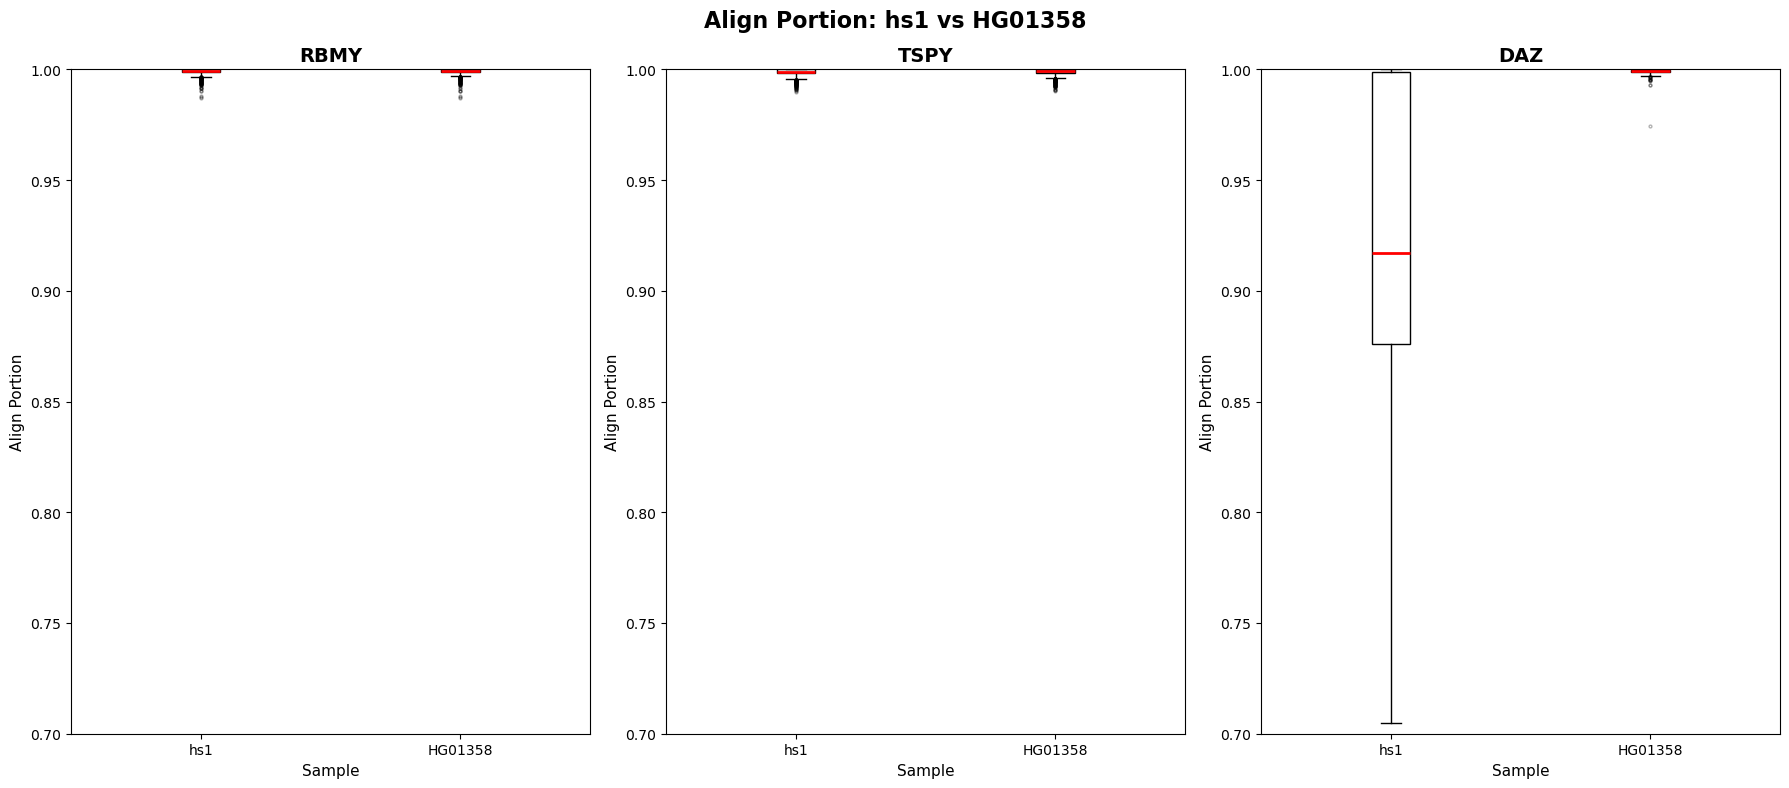

In [88]:
import matplotlib.pyplot as plt

fams = ["RBMY", "TSPY", "DAZ"]

# --- Find best overall sample across all families ---
all_non_t2t = readAlignmentDF[
    readAlignmentDF["sample"] != "T2T"
].copy()

# Filter to reads belonging to any of the 3 families
family_reads = set().union(*[convert[fam] for fam in fams])
all_non_t2t = all_non_t2t[all_non_t2t["read_name"].isin(family_reads)]

# Only consider samples present in all 3 families
def get_sample_families(sample):
    sample_reads = set(all_non_t2t[all_non_t2t["sample"] == sample]["read_name"])
    return sum(1 for fam in fams if sample_reads & set(convert[fam]))

valid_samples = [s for s in all_non_t2t["sample"].unique() if get_sample_families(s) == len(fams)]
best_overall = (
    all_non_t2t[all_non_t2t["sample"].isin(valid_samples)]
    .groupby("sample")["alignPortion"]
    .mean()
    .idxmax()
)
print(f"Best overall sample: {best_overall}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, fam in zip(axes, fams):
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]

    t2t_data  = famDF[famDF["sample"] == best_overall]["alignPortion"].dropna()
    best_data = famDF[famDF["sample"] == best_overall]["alignPortion"].dropna()
    t2t_data  = famDF[famDF["sample"] == "T2T"]["alignPortion"].dropna()

    ax.boxplot([t2t_data, best_data],
               labels=["hs1", best_overall],
               patch_artist=True,
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))

    boxes = ax.patches
    boxes[0].set_facecolor('white')
    boxes[1].set_facecolor('steelblue')

    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Align Portion", fontsize=11)
    ax.set_ylim(.7, 1)

plt.suptitle(f"Align Portion: hs1 vs {best_overall}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("alignPortion_boxplots.png", dpi=300, bbox_inches='tight')
plt.savefig("alignPortion_boxplots.pdf", dpi=300, bbox_inches='tight')

plt.show()

Best overall sample: HG01358


/tmp/ipykernel_3375735/3796394592.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/3796394592.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/3796394592.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],


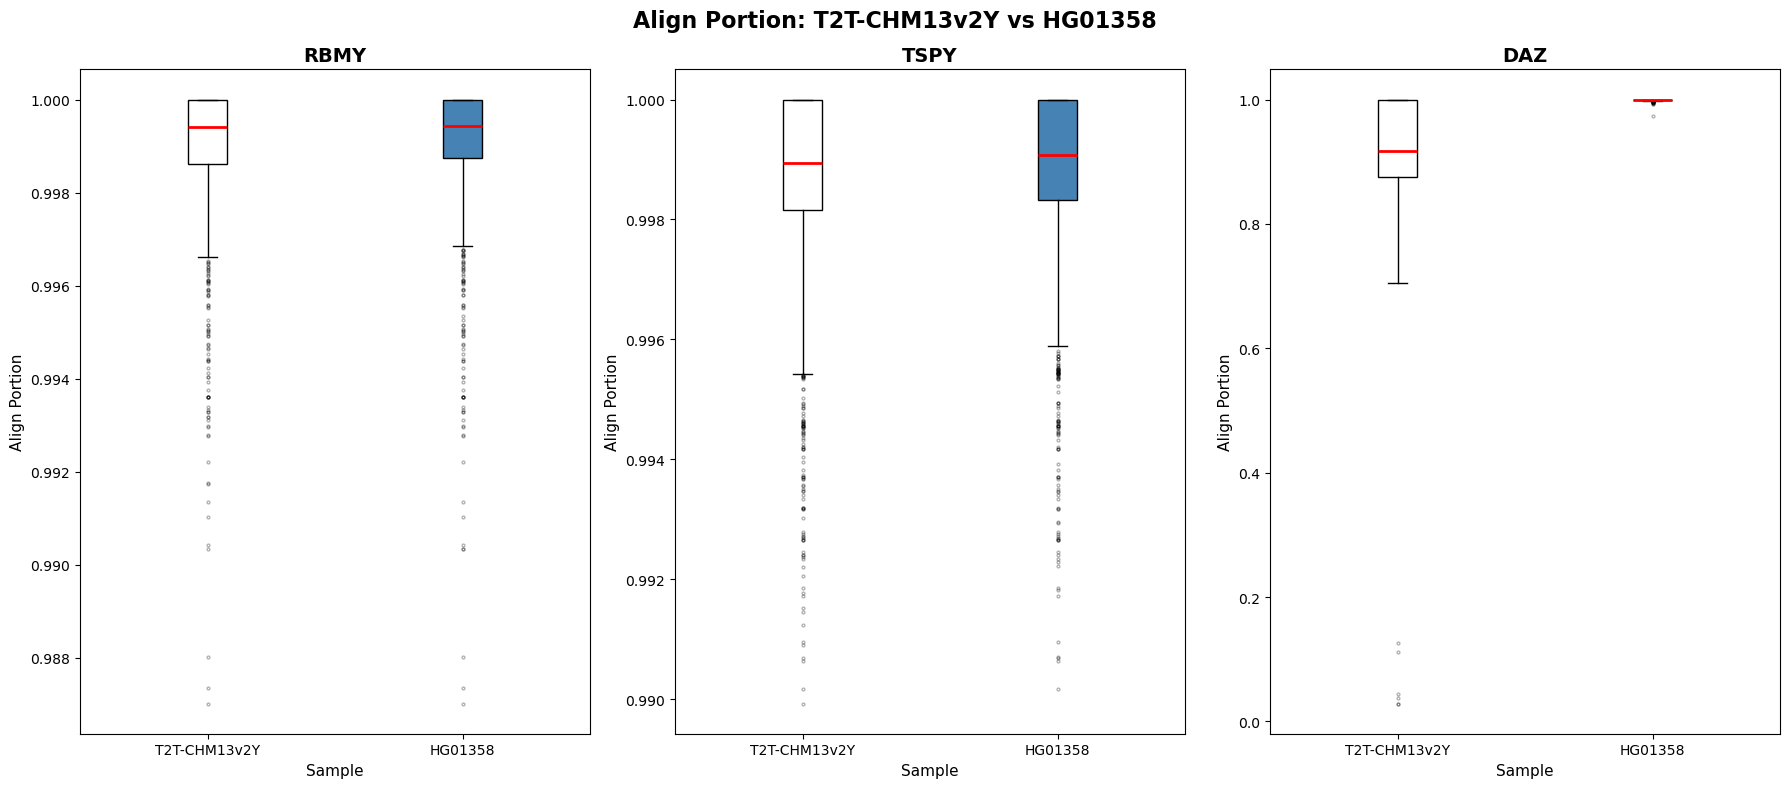

In [89]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype']  = 42  
fams = ["RBMY", "TSPY", "DAZ"]

# --- Find best overall sample across all families ---
all_non_t2t = readAlignmentDF[readAlignmentDF["sample"] != "T2T"].copy()
family_reads = set().union(*[convert[fam] for fam in fams])
all_non_t2t = all_non_t2t[all_non_t2t["read_name"].isin(family_reads)]

def get_sample_families(sample):
    sample_reads = set(all_non_t2t[all_non_t2t["sample"] == sample]["read_name"])
    return sum(1 for fam in fams if sample_reads & set(convert[fam]))

valid_samples = [s for s in all_non_t2t["sample"].unique() if get_sample_families(s) == len(fams)]
best_overall = (
    all_non_t2t[all_non_t2t["sample"].isin(valid_samples)]
    .groupby("sample")["alignPortion"]
    .mean()
    .idxmax()
)
print(f"Best overall sample: {best_overall}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, fam in zip(axes, fams):
    famDF    = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    t2t_data  = famDF[famDF["sample"] == "T2T"        ]["alignPortion"].dropna()
    best_data = famDF[famDF["sample"] == best_overall  ]["alignPortion"].dropna()

    ax.boxplot([t2t_data, best_data],
               labels=["T2T-CHM13v2Y", best_overall],
               patch_artist=True,
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))

    boxes = ax.patches
    boxes[0].set_facecolor('white')
    boxes[1].set_facecolor('steelblue')

    # Per-subplot y limits: span from just below the lowest whisker/outlier
    # to just above the highest, with a 5% padding on each side
    combined = pd.concat([t2t_data, best_data])
    data_min, data_max = combined.min(), combined.max()
    pad = (data_max - data_min) * 0.05
    ax.set_ylim(data_min - pad, data_max + pad)

    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Align Portion", fontsize=11)

plt.suptitle(f"Align Portion: T2T-CHM13v2Y vs {best_overall}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("alignPortion_boxplots_variableYaxis.png", dpi=300, bbox_inches='tight')
plt.savefig("alignPortion_boxplots_variableYaxis.pdf", dpi=300, bbox_inches='tight')

plt.show()

In [91]:
from scipy import stats
import pandas as pd

fams = ["RBMY", "TSPY", "DAZ"]

# --- Find best overall sample (same logic as before) ---
from collections import defaultdict
import numpy as np

sample_scores = defaultdict(list)
for fam in fams:
    fam_data = famSampAlignQuality_dict[fam]
    for sample, val in fam_data.items():
        if sample != "T2T":
            sample_scores[sample].append(val)

sample_scores = {s: v for s, v in sample_scores.items() if len(v) == len(fams)}
#best_overall = max(sample_scores, key=lambda s: np.mean(sample_scores[s]))
best_overall = "HG01358"
print(f"Best overall sample: {best_overall}\n")

# --- Statistical testing per family ---
results = []

for fam in fams:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    if fam == "DAZ":
        # require DAZ reads contain first exon
        famDF = famDF[famDF["read_name"].isin(DAZreads_firstExon)]
    else:
        pass
    t2t_data  = famDF[famDF["sample"] == "T2T"         ]["alignPortion"].dropna()
    best_data = famDF[famDF["sample"] == best_overall  ]["alignPortion"].dropna()
    
    # Mann-Whitney U: tests whether best_overall tends to have higher values than T2T
    stat, p = stats.mannwhitneyu(best_data, t2t_data, alternative="greater")
    
    # Effect size: rank-biserial correlation (r = 1 - 2U / n1*n2)
    n1, n2 = len(best_data), len(t2t_data)
    r = 1 - (2 * stat) / (n1 * n2)
    
    median_t2t  = t2t_data.median()
    median_best = best_data.median()
    pct_change  = (median_best - median_t2t) * 100
    
    results.append({
        "Family"            : fam,
        "n (hs1)"           : n2,
        f"n ({best_overall})": n1,
        "Median hs1"        : f"{median_t2t * 100:.2f}%",
        f"Median {best_overall}": f"{median_best * 100:.2f}%",
        "Δ Median"          : f"{pct_change:+.3f}%",
        "U statistic"       : f"{stat:.0f}",
        "p-value"           : p,
        "Effect size (r)"   : f"{r:.3f}",
        "Significant"       : "✓" if p < 0.05 else "✗",
    })
    
    print(f"{'─'*50}")
    print(f"  {fam}")
    print(f"  Mann-Whitney U = {stat:.0f},  p = {p:.2e}")
    print(f"  Effect size r  = {r:.3f}  ({'small' if abs(r) < 0.1 else 'medium' if abs(r) < 0.3 else 'large'})")
    print(f"  Median hs1     = {median_t2t*100:.2f}%")
    print(f"  Median {best_overall:8s} = {median_best*100:.2f}%  ({pct_change:+.3f}%)")
    print(f"  Significant?   = {'Yes (p < 0.05)' if p < 0.05 else 'No'}")

# --- Bonferroni correction for multiple comparisons ---
print(f"\n{'─'*50}")
print(f"Bonferroni-corrected α = {0.05 / len(fams):.4f}  (testing {len(fams)} families)")
for r in results:
    corrected = "✓" if float(r["p-value"]) < 0.05 / len(fams) else "✗"
    print(f"  {r['Family']}: p = {float(r['p-value']):.2e}  →  significant after correction: {corrected}")

# --- Summary table ---
print(f"\n{'─'*50}")
print(pd.DataFrame(results).to_string(index=False))

Best overall sample: HG01358

──────────────────────────────────────────────────
  RBMY
  Mann-Whitney U = 462150,  p = 1.74e-01
  Effect size r  = -0.024  (small)
  Median hs1     = 99.94%
  Median HG01358  = 99.94%  (+0.002%)
  Significant?   = No
──────────────────────────────────────────────────
  TSPY
  Mann-Whitney U = 3367040,  p = 1.86e-16
  Effect size r  = -0.133  (medium)
  Median hs1     = 99.89%
  Median HG01358  = 99.91%  (+0.015%)
  Significant?   = Yes (p < 0.05)
──────────────────────────────────────────────────
  DAZ
  Mann-Whitney U = 19554,  p = 5.26e-22
  Effect size r  = -0.628  (large)
  Median hs1     = 91.72%
  Median HG01358  = 99.94%  (+8.222%)
  Significant?   = Yes (p < 0.05)

──────────────────────────────────────────────────
Bonferroni-corrected α = 0.0167  (testing 3 families)
  RBMY: p = 1.74e-01  →  significant after correction: ✗
  TSPY: p = 1.86e-16  →  significant after correction: ✓
  DAZ: p = 5.26e-22  →  significant after correction: ✓

─────────

In [92]:
from scipy import stats
import pandas as pd

fams = ["RBMY", "TSPY", "DAZ"]

# --- Find best overall sample (same logic as before) ---
from collections import defaultdict
import numpy as np

sample_scores = defaultdict(list)
for fam in fams:
    fam_data = famSampAlignQuality_dict[fam]
    for sample, val in fam_data.items():
        if sample != "T2T":
            sample_scores[sample].append(val)

sample_scores = {s: v for s, v in sample_scores.items() if len(v) == len(fams)}
best_overall = max(sample_scores, key=lambda s: np.mean(sample_scores[s]))
print(f"Best overall sample: {best_overall}\n")

# --- Statistical testing per family ---
results = []

for fam in fams:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    
    t2t_data  = famDF[famDF["sample"] == "T2T"         ]["alignPortion"].dropna()
    best_data = famDF[famDF["sample"] == best_overall  ]["alignPortion"].dropna()
    
    # Mann-Whitney U: tests whether best_overall tends to have higher values than T2T
    stat, p = stats.mannwhitneyu(best_data, t2t_data, alternative="greater")
    
    # Effect size: rank-biserial correlation (r = 1 - 2U / n1*n2)
    n1, n2 = len(best_data), len(t2t_data)
    r = 1 - (2 * stat) / (n1 * n2)
    
    median_t2t  = t2t_data.median()
    median_best = best_data.median()
    pct_change  = (median_best - median_t2t) / median_t2t * 100
    
    results.append({
        "Family"            : fam,
        "n (hs1)"           : n2,
        f"n ({best_overall})": n1,
        "Median hs1"        : f"{median_t2t * 100:.2f}%",
        f"Median {best_overall}": f"{median_best * 100:.2f}%",
        "Δ Median"          : f"{pct_change:+.3f}%",
        "U statistic"       : f"{stat:.0f}",
        "p-value"           : p,
        "Effect size (r)"   : f"{r:.3f}",
        "Significant"       : "✓" if p < 0.05 else "✗",
    })
    
    print(f"{'─'*50}")
    print(f"  {fam}")
    print(f"  Mann-Whitney U = {stat:.0f},  p = {p:.2e}")
    print(f"  Effect size r  = {r:.3f}  ({'small' if r < 0.1 else 'medium' if r < 0.3 else 'large'})")
    print(f"  Median hs1     = {median_t2t*100:.2f}%")
    print(f"  Median {best_overall:8s} = {median_best*100:.2f}%  ({pct_change:+.3f}%)")
    print(f"  Significant?   = {'Yes (p < 0.05)' if p < 0.05 else 'No'}")

# --- Bonferroni correction for multiple comparisons ---
print(f"\n{'─'*50}")
print(f"Bonferroni-corrected α = {0.05 / len(fams):.4f}  (testing {len(fams)} families)")
for r in results:
    corrected = "✓" if float(r["p-value"]) < 0.05 / len(fams) else "✗"
    print(f"  {r['Family']}: p = {float(r['p-value']):.2e}  →  significant after correction: {corrected}")

# --- Summary table ---
print(f"\n{'─'*50}")
print(pd.DataFrame(results).to_string(index=False))

Best overall sample: HG01934

──────────────────────────────────────────────────
  RBMY
  Mann-Whitney U = 459080,  p = 2.51e-01
  Effect size r  = -0.017  (small)
  Median hs1     = 99.94%
  Median HG01934  = 99.94%  (+0.002%)
  Significant?   = No
──────────────────────────────────────────────────
  TSPY
  Mann-Whitney U = 3339074,  p = 1.88e-14
  Effect size r  = -0.124  (small)
  Median hs1     = 99.89%
  Median HG01934  = 99.91%  (+0.015%)
  Significant?   = Yes (p < 0.05)
──────────────────────────────────────────────────
  DAZ
  Mann-Whitney U = 19576,  p = 4.01e-22
  Effect size r  = -0.630  (small)
  Median hs1     = 91.72%
  Median HG01934  = 99.94%  (+8.964%)
  Significant?   = Yes (p < 0.05)

──────────────────────────────────────────────────
Bonferroni-corrected α = 0.0167  (testing 3 families)
  RBMY: p = 2.51e-01  →  significant after correction: ✗
  TSPY: p = 1.88e-14  →  significant after correction: ✓
  DAZ: p = 4.01e-22  →  significant after correction: ✓

──────────

/tmp/ipykernel_3375735/1430456280.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/1430456280.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/1430456280.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],


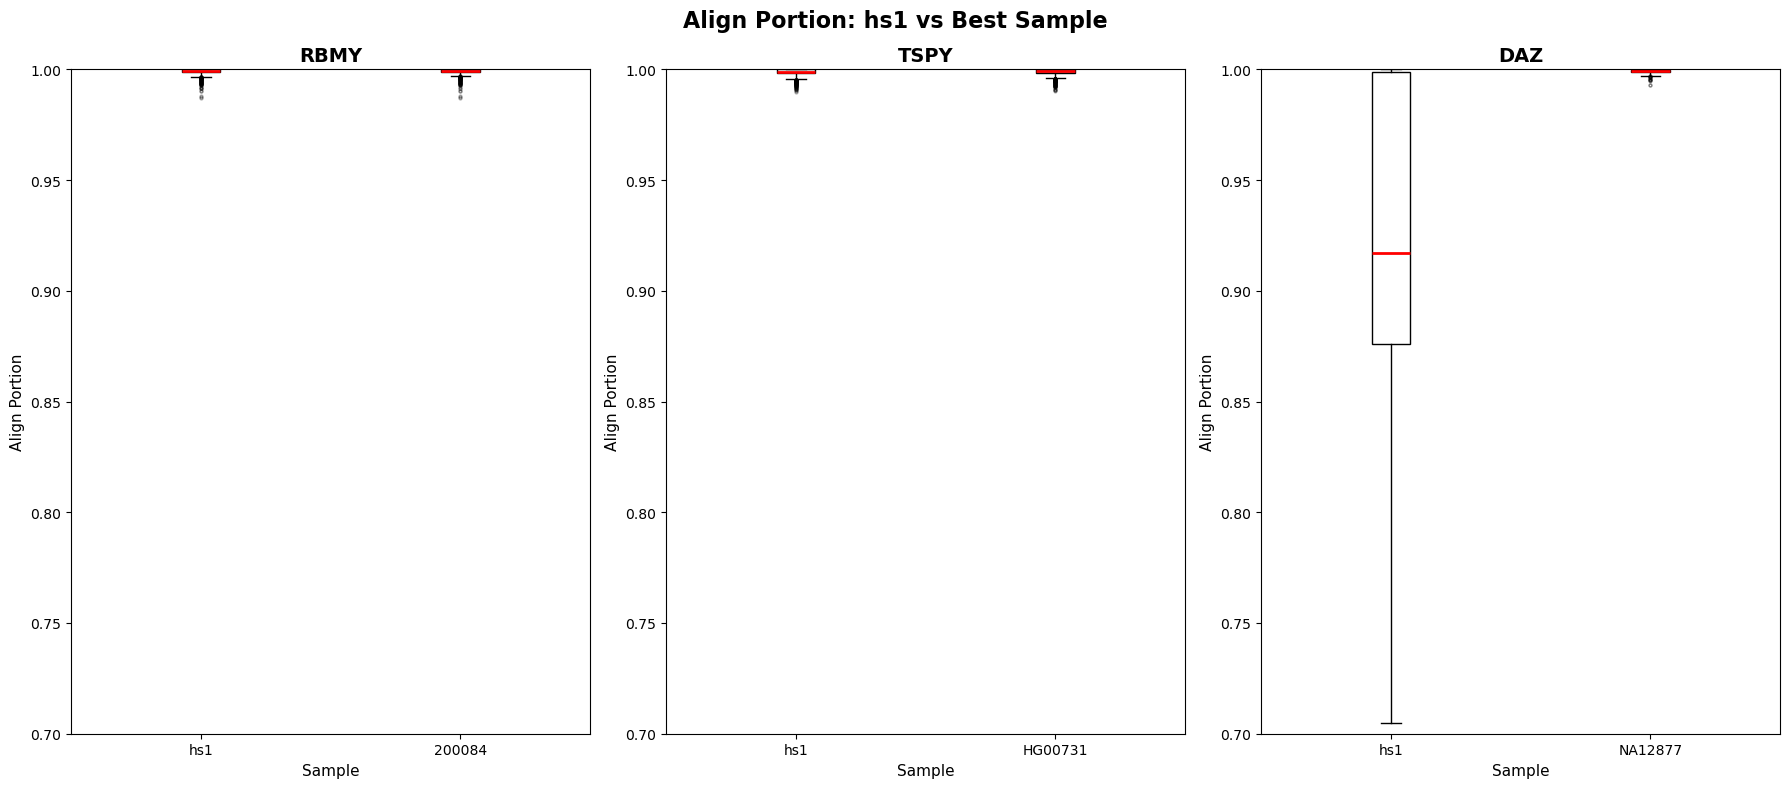

In [93]:
import matplotlib.pyplot as plt

fams = ["RBMY", "TSPY", "DAZ"]
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, fam in zip(axes, fams):
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    
    # T2T data
    t2t_data = famDF[famDF["sample"] == "T2T"]["alignPortion"].dropna()
    
    # Find best non-T2T sample by mean alignPortion
    non_t2t = famDF[famDF["sample"] != "T2T"]
    best_sample = non_t2t.groupby("sample")["alignPortion"].mean().idxmax()
    best_data = non_t2t[non_t2t["sample"] == best_sample]["alignPortion"].dropna()
    
    ax.boxplot([t2t_data, best_data],
               labels=["hs1", best_sample],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    
    # Highlight T2T box in red
    boxes = ax.patches
    boxes[0].set_facecolor('white')
    boxes[1].set_facecolor('steelblue')
    
    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Align Portion", fontsize=11)
    ax.set_ylim(.7, 1)

plt.suptitle("Align Portion: hs1 vs Best Sample", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("alignPortion_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

# TSPY2 deep dive

In [94]:
TSPY_readAlignmentDF = readAlignmentDF[readAlignmentDF["read_name"].isin(TSPYreads)]
TSPY_readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
67,200080,SRR31360662.61053041,200080_chrY,0,9S12=1X33=1X9=559N26=1X121=4410N106=1D30=1778N...,60,120950,136994,1325,1310,6,0,1,14727,9,0.988679,NoHit
731,200080,SRR31360662.50757878,200080_chrY,16,1S437=2162N47=1D105=219N194=1X339=1D5=1X283=1X...,60,142153,146542,2007,1997,9,0,2,2381,1,0.995017,NoHit
1228,200080,SRR31360662.36773184,200080_chrY,16,98=1D122=1I56=4088N107=67N32=1D86=2007N176=327...,60,179467,220406,1566,1563,2,1,4,39370,0,0.998084,NoHit
59648,200080,SRR31360662.19654969,200080_chrY,0,1S86=1D82=1I12=1I40=2I78=1D267=601N78=128N112=...,59,5934383,5937204,1192,1187,0,4,4,1630,1,0.995805,TSPY2
59649,200080,SRR31360662.11646131,200080_chrY,0,1S529=601N78=128N112=101N146=106N82=694N210=,41,5934421,5937208,1158,1157,0,0,0,1630,1,0.999136,TSPY2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19952017,T2T,SRR31360662.52470991,NC_060948.1,16,196=694N82=106N146=101N112=128N78=601N178=,36,10224473,10226895,792,792,0,0,0,1630,0,1.000000,TSPY2
19952018,T2T,SRR31360662.44434790,NC_060948.1,16,98=1X91=694N82=106N146=101N112=128N78=601N222=,0,10224479,10226939,830,829,1,0,0,1630,0,0.998795,TSPY2
19952019,T2T,SRR31360662.46868014,NC_060948.1,16,190=694N82=106N146=101N112=128N49=,24,10224479,10226087,579,579,0,0,0,1029,0,1.000000,TSPY2
19952020,T2T,SRR31360662.33603662,NC_060948.1,16,186=694N82=106N146=101N112=128N78=601N244=,34,10224483,10226961,848,848,0,0,0,1630,0,1.000000,TSPY2


In [95]:
collections.Counter(TSPY_readAlignmentDF["Gene"]).most_common()

[('TSPY10|TSPY3', 39831),
 ('TSPY10', 37684),
 ('TSPY3|TSPY7P', 35234),
 ('TSPY9', 30525),
 ('TSPY10|TSPY6P', 27743),
 ('TSPY4', 26683),
 ('TSPY2', 26218),
 ('TSPY3|TSPY6P', 18959),
 ('TSPY8', 15793),
 ('TSPY9|TSPY6P', 11894),
 ('TSPY1', 11533),
 ('TSPY2|TSPY7P', 11453),
 ('TSPY4|TSPY9', 10262),
 ('TSPY10|TSPY7P', 9023),
 ('TSPY3', 4250),
 ('TSPY3|TSPY10', 3727),
 ('TSPY1|TSPY7P', 2860),
 ('TSPY8|TSPY6P', 2459),
 ('NoHit', 2228),
 ('TSPY10|TSPY8', 2179),
 ('TSPY3|TSPY1', 1873),
 ('TSPY11P', 1692),
 ('TSPY13P', 1128),
 ('TSPY10|TSPY1', 1119),
 ('TSPY4|TSPY6P', 828),
 ('TSPY8|TSPY3', 795),
 ('TSPY2|TSPY1', 761),
 ('TSPY3|TSPY9', 700),
 ('TSPY1|TSPY6P', 543),
 ('TSPY9|TSPY4', 525),
 ('TSPY8|TSPY10', 386),
 ('TSPY8|TSPY7P', 377),
 ('TSPY4|TSPY3', 218),
 ('TSPY2|TSPY6P', 214),
 ('TSPY10|TSPY4', 192),
 ('TSPY3|TSPY4', 192),
 ('TSPY1|TSPY10', 190),
 ('TSPY8|TSPY9', 169),
 ('TSPY15P', 140),
 ('TSPY4|TSPY7P', 132),
 ('TSPY18P', 127),
 ('TSPY10|TSPY9', 124),
 ('TSPY9|TSPY7P', 89),
 ('TSPY3|ENSG0

In [96]:
TSPY2_readAlignmentDF = TSPY_readAlignmentDF[TSPY_readAlignmentDF["Gene"]=="TSPY2"]
TSPY2_readAlignmentDF

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
59648,200080,SRR31360662.19654969,200080_chrY,0,1S86=1D82=1I12=1I40=2I78=1D267=601N78=128N112=...,59,5934383,5937204,1192,1187,0,4,4,1630,1,0.995805,TSPY2
59649,200080,SRR31360662.11646131,200080_chrY,0,1S529=601N78=128N112=101N146=106N82=694N210=,41,5934421,5937208,1158,1157,0,0,0,1630,1,0.999136,TSPY2
59650,200080,SRR31360662.18473257,200080_chrY,0,4S525=601N78=128N112=227N20=106N82=694N206=,45,5934425,5937204,1027,1023,0,0,0,1756,4,0.996105,TSPY2
59651,200080,SRR31360662.52580061,200080_chrY,0,4S525=601N78=128N112=227N20=106N82=694N206=,45,5934425,5937204,1027,1023,0,0,0,1756,4,0.996105,TSPY2
59652,200080,SRR31360662.62419759,200080_chrY,0,4S392=1X132=601N78=128N112=227N20=106N82=694N206=,46,5934425,5937204,1027,1022,1,0,0,1756,4,0.995131,TSPY2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19952016,T2T,SRR31360662.65262529,NC_060948.1,16,206=694N82=106N146=101N112=128N78=601N83=1D342=1S,29,10224463,10227143,1050,1049,0,0,1,1630,1,0.999048,TSPY2
19952017,T2T,SRR31360662.52470991,NC_060948.1,16,196=694N82=106N146=101N112=128N78=601N178=,36,10224473,10226895,792,792,0,0,0,1630,0,1.000000,TSPY2
19952018,T2T,SRR31360662.44434790,NC_060948.1,16,98=1X91=694N82=106N146=101N112=128N78=601N222=,0,10224479,10226939,830,829,1,0,0,1630,0,0.998795,TSPY2
19952019,T2T,SRR31360662.46868014,NC_060948.1,16,190=694N82=106N146=101N112=128N49=,24,10224479,10226087,579,579,0,0,0,1029,0,1.000000,TSPY2


In [97]:
TSPY1reads = TSPY_readAlignmentDF[TSPY_readAlignmentDF["Gene"]!="TSPY2"]["read_name"].to_list()
TSPY2reads = TSPY2_readAlignmentDF["read_name"].to_list()

In [98]:
tspySampAlignQuality_dict = {x:{} for x in ["TSPY1", "TSPY2"]}
convert = {"TSPY1":TSPY1reads, "TSPY2":TSPY2reads}
for fam in ["TSPY1", "TSPY2"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    tspySampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        tspySampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    tspySampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

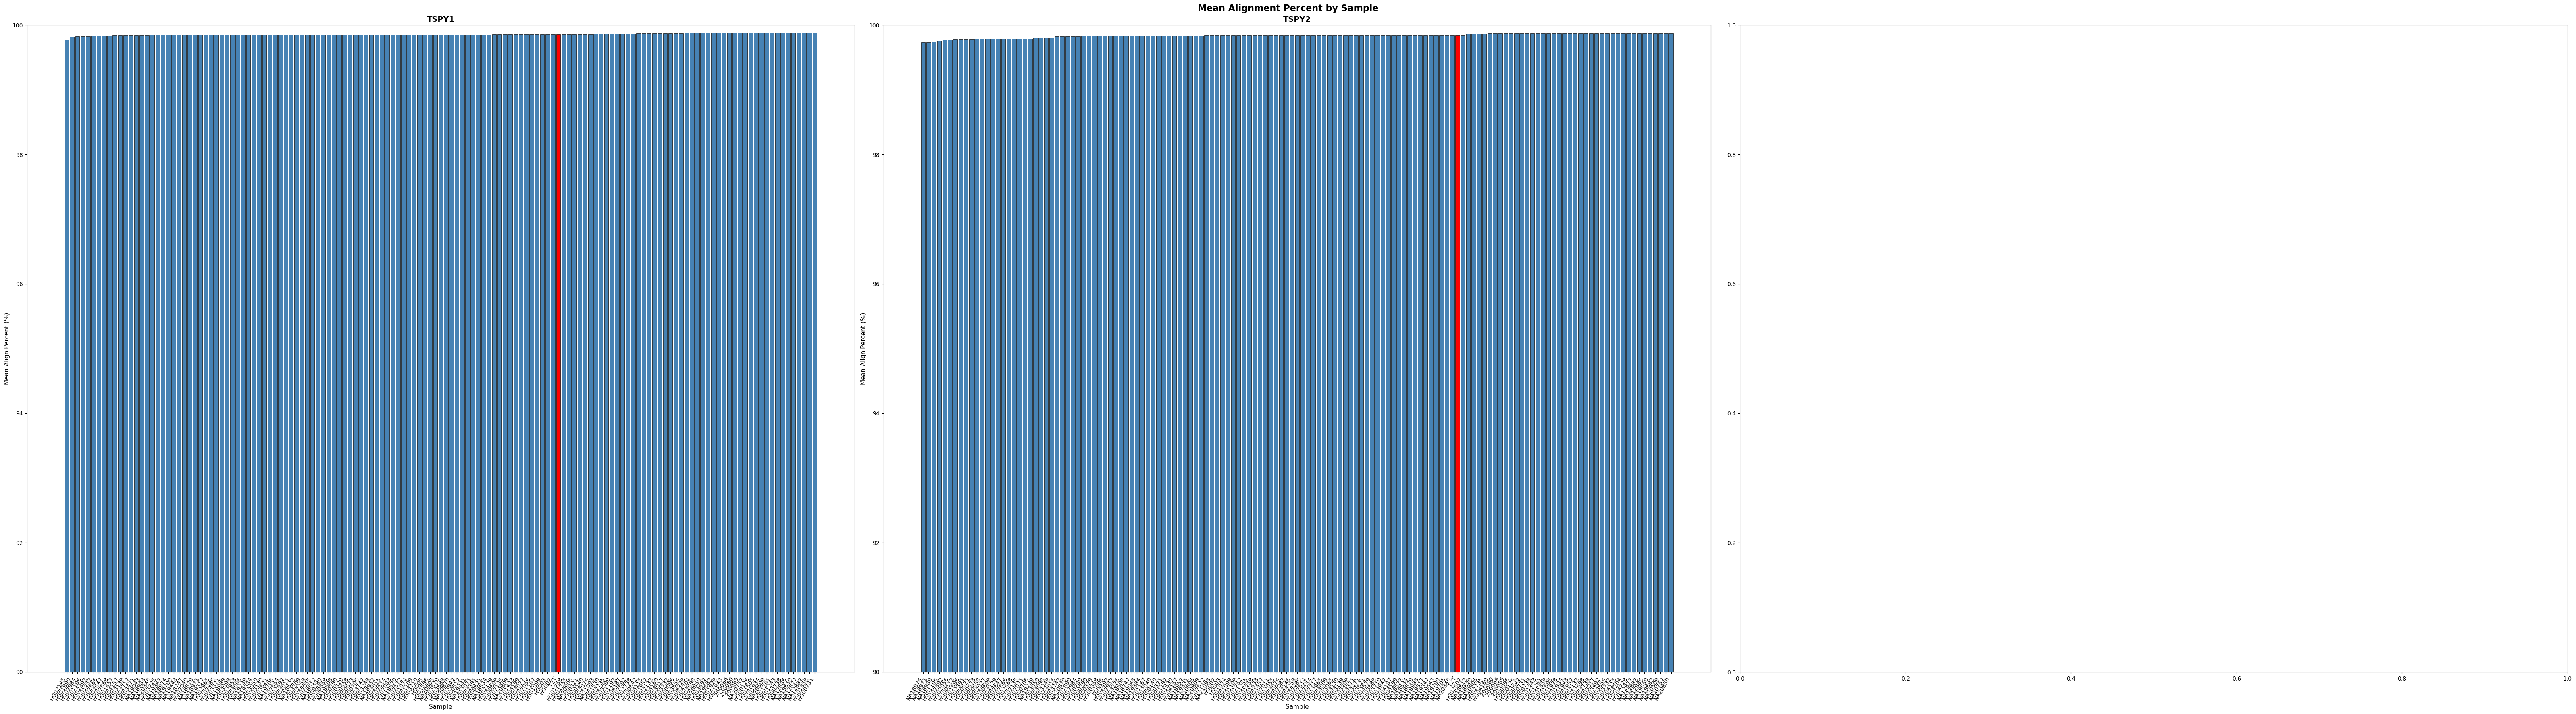

In [99]:
import matplotlib.pyplot as plt
import numpy as np

fams = ["TSPY1", "TSPY2"]
fig, axes = plt.subplots(1, 3, figsize=(64, 24))

for ax, fam in zip(axes, fams):
    sample_means = tspySampAlignQuality_dict[fam]
    
    sorted_items = sorted(sample_means.items(), key=lambda x: x[1])
    samples_list = [k for k, v in sorted_items]
    means = [v * 100 for k, v in sorted_items]  # convert to percent
    
    colors = ['red' if s == 'T2T' else 'steelblue' for s in samples_list]
    ax.bar(range(len(samples_list)), means, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(samples_list)))
    ax.set_xticklabels(samples_list, rotation=60, ha='right', fontsize=10)
    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Mean Align Percent (%)", fontsize=11)
    ax.set_ylim(90, 100)  # now in percent
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f"{val:.0f}"))

plt.suptitle("Mean Alignment Percent by Sample", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

In [100]:
splicing_readAlignmentDF = readAlignmentDF[readAlignmentDF["cigar"].str.contains("N")]
splicing_famSampAlignQuality_dict = {x:{} for x in ["RBMY", "TSPY", "DAZ"]}
convert = {"RBMY":strictRBMYreads, "TSPY":TSPYreads, "DAZ":DAZreads}
for fam in ["RBMY", "TSPY", "DAZ"]:
    famDF = readAlignmentDF[readAlignmentDF["read_name"].isin(convert[fam])]
    splicing_famSampAlignQuality_dict[fam] = {x:{} for x in samples}
    for sample in tqdm(samples):
        sampDF = famDF[famDF["sample"]==sample]
        splicing_famSampAlignQuality_dict[fam][sample] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    sampDF = famDF[famDF["sample"]=="T2T"]
    splicing_famSampAlignQuality_dict[fam]["T2T"] = sampDF.groupby('read_name')['alignPortion'].max().mean()
    
        

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/140 [00:00<?, ?it/s]

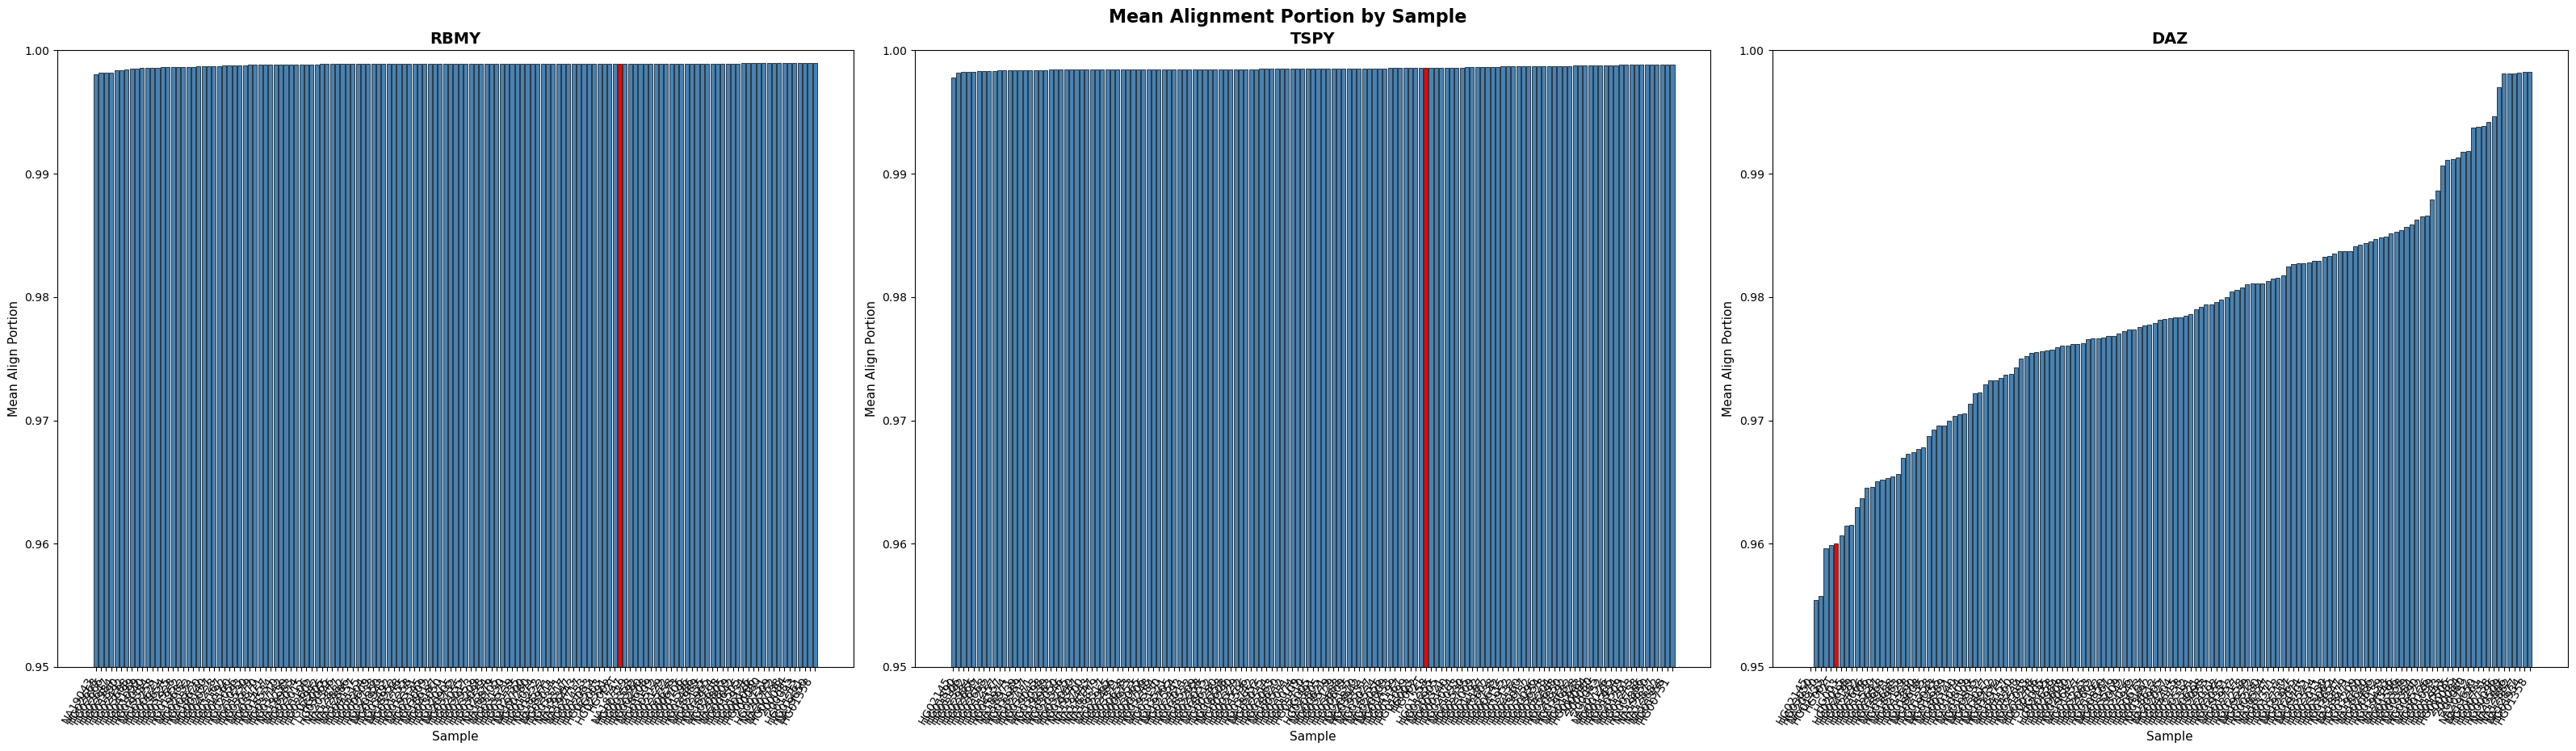

In [101]:
import matplotlib.pyplot as plt
import numpy as np

fams = ["RBMY", "TSPY", "DAZ"]
fig, axes = plt.subplots(1, 3, figsize=(32, 12))

for ax, fam in zip(axes, fams):
    sample_means = splicing_famSampAlignQuality_dict[fam]
    
    sorted_items = sorted(sample_means.items(), key=lambda x: x[1])
    samples_list = [k for k, v in sorted_items]
    means = [v for k, v in sorted_items]

    colors = ['red' if s == 'T2T' else 'steelblue' for s in samples_list]

    ax.bar(range(len(samples_list)), means, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(samples_list)))
    ax.set_xticklabels(samples_list, rotation=60, ha='right', fontsize=10)
    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Mean Align Portion", fontsize=11)
    ax.set_ylim(.95, 1)

plt.suptitle("Mean Alignment Portion by Sample", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.savefig("alignPortion_barplots.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3375735/2451682744.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/2451682744.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],
/tmp/ipykernel_3375735/2451682744.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([t2t_data, best_data],


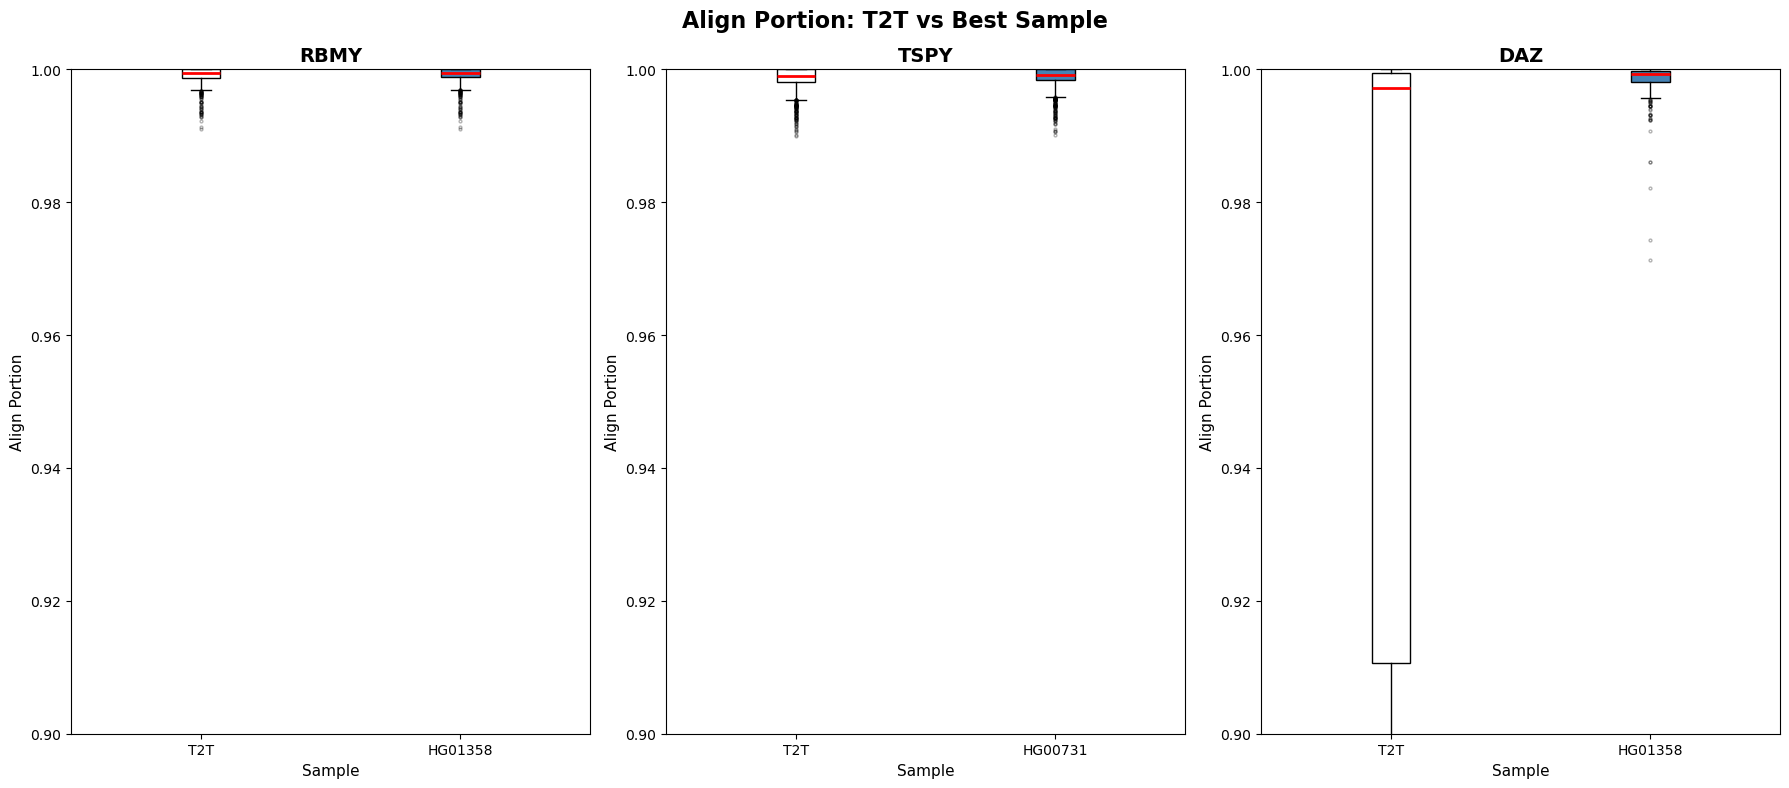

In [102]:
import matplotlib.pyplot as plt

fams = ["RBMY", "TSPY", "DAZ"]
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
splicing_readAlignmentDF = readAlignmentDF[readAlignmentDF["cigar"].str.contains("N")]
for ax, fam in zip(axes, fams):
    famDF = splicing_readAlignmentDF[splicing_readAlignmentDF["read_name"].isin(convert[fam])]
    
    # T2T data
    t2t_data = famDF[famDF["sample"] == "T2T"]["alignPortion"].dropna()
    
    # Find best non-T2T sample by mean alignPortion
    non_t2t = famDF[famDF["sample"] != "T2T"]
    best_sample = non_t2t.groupby("sample")["alignPortion"].mean().idxmax()
    best_data = non_t2t[non_t2t["sample"] == best_sample]["alignPortion"].dropna()
    
    ax.boxplot([t2t_data, best_data],
               labels=["T2T", best_sample],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', color='black'),
               medianprops=dict(color='red', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    
    # Highlight T2T box in red
    boxes = ax.patches
    boxes[0].set_facecolor('white')
    boxes[1].set_facecolor('steelblue')
    
    ax.set_title(fam, fontsize=14, fontweight='bold')
    ax.set_xlabel("Sample", fontsize=11)
    ax.set_ylabel("Align Portion", fontsize=11)
    ax.set_ylim(.9, 1)

plt.suptitle("Align Portion: T2T vs Best Sample", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("alignPortion_boxplots.png", dpi=300, bbox_inches='tight')
plt.show()

In [103]:
splicing_readAlignmentDF[splicing_readAlignmentDF["sample"]=="T2T"]["alignPortion"].describe()

count    37467.000000
mean         0.968591
std          0.020197
min          0.028856
25%          0.957047
50%          0.965823
75%          0.976766
max          1.000000
Name: alignPortion, dtype: float64

In [104]:
# Confusion Matrix
# focus DAZ first

In [105]:
readAlignmentDF[readAlignmentDF["Gene"].str.contains("DAZ")]

,sample,read_name,contig,flag,cigar,map_quality,ref_start,ref_end,read_length,matches,mismatches,insertions,deletions,gaps,soft_clipping,alignPortion,Gene
119357,200080,SRR31360662.18354082,200080_chrY,0,27=2X7=1X23=3X13=1X21=219089N1=1X2=2X4=1X31=2X...,10,23804513,24025020,894,850,38,6,6,219613,0,0.950783,DAZ1
119358,200080,SRR31360662.58568479,200080_chrY,0,27=2X7=1X23=3X13=1X21=219089N1=1X2=2X4=1X31=2X...,10,23804513,24025020,894,850,38,6,6,219613,0,0.950783,DAZ1
119364,200080,SRR31360662.48897885,200080_chrY,16,5=1X21=1X2=2X10=3X19=1X18=164947N23=1X2=1X9=1X...,1,23937428,24129446,1039,992,47,0,5,190974,0,0.954764,DAZ1
119366,200080,SRR31360662.3774136,200080_chrY,0,19=1X42=1X14=2D36=1X83774N67=1X2=1X22=1X9=1X4=...,0,23940631,24025019,607,587,20,0,7,83774,0,0.967051,DAZ1
119367,200080,SRR31360662.49124248,200080_chrY,0,9S26=1X2=1X12=1X6=2X6=1X24=133206N4=1X1=7D118=...,0,23940663,24074252,385,367,9,0,7,133206,9,0.953247,DAZ1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20006749,T2T,SRR31360662.17221232,NC_060948.1,0,404=,0,25718990,25719394,404,404,0,0,0,0,0,1.000000,DAZ2
20006750,T2T,SRR31360662.33009715,NC_060948.1,0,300=,0,25719094,25719394,300,300,0,0,0,0,0,1.000000,DAZ2
20006751,T2T,SRR31360662.6052438,NC_060948.1,0,528=1I1295=,0,25719264,25721087,1824,1823,0,1,0,0,0,0.999452,DAZ2
20006752,T2T,SRR31360662.9608359,NC_060948.1,0,195=1I287=2I908=1D386=,0,25719310,25721087,1779,1776,0,3,1,0,0,0.998314,DAZ2
